# CO₂ Concentration Forecasting with a Transformer: Modeling, Evaluation, and Root-Cause Analysis

## Summary

This notebook focuses on the first two parts of the challenge. The deployment side, including PostgreSQL, FastAPI, and Docker, is implemented separately in the repository and described in the README.

The task is to forecast CO₂ concentration at the six sampling points of the Imperial College pilot plant. The final forecast horizon is 6 rows ahead. Rows are 43–44 seconds apart, so this corresponds to about 4.3 minutes.

**What I did**

- Explored 8 experimental runs and fixed the data split before modeling. 7 runs are used for development, while `140207_1.xlsx` is kept as the held-out test run and evaluated once at the end.
- Compared persistence using the last measured CO₂ value, Ridge models, and a Transformer implemented in `src/model.py`. The Transformer predicts a correction on top of persistence.
- Compared forecast horizons of 1, 3, 6, 12, and 18 steps, along with different context lengths.
- Used nested leave-one-run-out validation on the development runs for model and epoch selection. The test run is not used for these decisions.

**What came out**

- Persistence is very hard to beat on this dataset. Across the forecast horizons tested, the nested-selected forecast stays within about 0.5% of persistence (MAE ratio 0.9991–1.0042).
- The final development-only selection chooses epoch 0. Because the Transformer is formulated as a residual correction to persistence, epoch 0 gives a zero correction and the selected forecast is exactly persistence.
- Part 2 looks at where persistence fails and what the trained Transformer changes in the folds where training was retained. The final root-cause analysis separates patterns supported by the data from explanations that cannot be established from these experiments alone.

## Objective

Forecast CO₂ concentration at the six absorber sampling points from the available process measurements, compare the forecasting approach against simple baselines, and understand where and why the forecasts break down.

Following the challenge specification, `140207_1.xlsx` is the held-out test run. It is not used for training, tuning, horizon selection, context-length selection, or any other model-selection decision.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch

print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"PyTorch version: {torch.__version__}")

NumPy version:  1.26.4
Pandas version: 2.3.3
PyTorch version: 2.2.2


In [2]:
# Paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
TEST_FILE = RAW_DATA_DIR / "140207_1.xlsx"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Test file: {TEST_FILE}")
print(f"Test file exists: {TEST_FILE.exists()}")

Project root: <PROJECT_ROOT>
Raw data directory: <PROJECT_ROOT>/data/raw
Test file: <PROJECT_ROOT>/data/raw/140207_1.xlsx
Test file exists: True


In [3]:
# Inspecting workbook sheet names without loading the data yet
excel_file = pd.ExcelFile(TEST_FILE)

print("Sheets in 140207_1.xlsx:")
for sheet in excel_file.sheet_names:
    print(f"  - {sheet}")

Sheets in 140207_1.xlsx:
  - 140207 - OA
  - Screen dumps 140207-01
  - Audit Trail 140207-01


In [4]:
# Loading the first sheet 
raw_preview = pd.read_excel(
    TEST_FILE,
    sheet_name="140207 - OA",
    header=None,
    nrows=10
)

raw_preview

,0,1,2,3,4,5,6,7,8,9,...,82,83,84,85,86,87,88,89,90,91
0,NaT,AT100,AT300,AT400,FT100,FT101,FT102,FT103,FT104,FT105,...,TT400,TT401,TT402,TT403,TT404,TT410,TT411,TT412,TT413,label
1,NaT,(pH),(pH),(CO2 %),(kg/hr),(kg/hr),(kg/hr),(kg/hr),(kg/hr),(L/min),...,(0C),(0C),(0C),(0C),(0C),(0C),(0C),(0C),(0C),NaN
2,2014-02-07 11:56:10,10.116647,10.848363,0.000827,49.592602,0,0,249.91272,0,0.079674,...,113.404274,113.314041,113.009346,15.852446,37.372349,21.568188,40.269363,41.34761,39.206261,1
3,2014-02-07 11:56:53,10.129154,10.847005,0,50.189606,0,0,250.13443,0,0.077913,...,113.358452,113.287994,112.92263,15.868966,38.16724,21.590422,40.246792,41.381161,39.231876,1
4,2014-02-07 11:57:36,10.135558,10.84683,0,50.098671,0,2.217996,249.145966,0,0.077746,...,113.2229,113.195847,112.830246,15.908598,38.448006,21.605648,40.280098,41.414845,39.289288,1
5,2014-02-07 11:58:19,10.147011,10.845308,0,50.449322,0,72.320206,249.639084,36.785664,0.077626,...,113.169922,113.04097,112.704971,15.852446,38.722832,21.624104,40.322838,41.431889,39.325478,2
6,2014-02-07 11:59:02,10.150861,10.844745,0,50.36964,0,107.381989,250.469147,0.000004,0.078599,...,112.759262,112.494438,112.311119,15.784084,39.175331,21.637949,40.345547,41.432476,39.373291,2
7,2014-02-07 11:59:46,10.153481,10.843995,0.000145,50.459126,0,149.818298,250.020691,0.0,0.077805,...,112.812775,112.39093,112.190315,15.727932,39.196999,21.651066,40.304466,41.436321,39.361141,2
8,2014-02-07 12:00:29,10.152883,10.844931,0.001831,50.152664,0,0,249.30249,0.0,0.077911,...,112.173866,111.843361,111.591568,15.727932,39.409897,21.665287,40.32188,41.404896,39.437374,3
9,2014-02-07 12:01:12,10.155368,10.842296,0.035706,50.273472,0,0,250.116074,0.0,0.078166,...,112.262627,112.008636,111.779068,15.727932,38.855324,21.672754,40.302544,41.377209,39.425247,3


In [5]:
# Loading the process-data sheet using its two-row header
df_test_raw = pd.read_excel(
    TEST_FILE,
    sheet_name="140207 - OA",
    header=[0, 1]
)

print(f"Shape: {df_test_raw.shape}")
df_test_raw.head()

Shape: (118, 92)


,Unnamed: 0_level_0,AT100,AT300,AT400,FT100,FT101,FT102,FT103,FT104,FT105,...,TT400,TT401,TT402,TT403,TT404,TT410,TT411,TT412,TT413,label
,Unnamed: 0_level_1,(pH),(pH),(CO2 %),(kg/hr),(kg/hr),(kg/hr),(kg/hr),(kg/hr),(L/min),...,(0C),(0C),(0C),(0C),(0C),(0C),(0C),(0C),(0C),Unnamed: 91_level_1
0,2014-02-07 11:56:10,10.116647,10.848363,0.000827,49.592602,0,0.000000,249.912720,0.000000,0.079674,...,113.404274,113.314041,113.009346,15.852446,37.372349,21.568188,40.269363,41.347610,39.206261,1
1,2014-02-07 11:56:53,10.129154,10.847005,0.000000,50.189606,0,0.000000,250.134430,0.000000,0.077913,...,113.358452,113.287994,112.922630,15.868966,38.167240,21.590422,40.246792,41.381161,39.231876,1
2,2014-02-07 11:57:36,10.135558,10.846830,0.000000,50.098671,0,2.217996,249.145966,0.000000,0.077746,...,113.222900,113.195847,112.830246,15.908598,38.448006,21.605648,40.280098,41.414845,39.289288,1
3,2014-02-07 11:58:19,10.147011,10.845308,0.000000,50.449322,0,72.320206,249.639084,36.785664,0.077626,...,113.169922,113.040970,112.704971,15.852446,38.722832,21.624104,40.322838,41.431889,39.325478,2
4,2014-02-07 11:59:02,10.150861,10.844745,0.000000,50.369640,0,107.381989,250.469147,0.000004,0.078599,...,112.759262,112.494438,112.311119,15.784084,39.175331,21.637949,40.345547,41.432476,39.373291,2


In [6]:
# Inspecting all columns and their units
for i, (sensor, unit) in enumerate(df_test_raw.columns):
    print(f"{i:2d}: {sensor:<20} {unit}")

 0: Unnamed: 0_level_0   Unnamed: 0_level_1
 1: AT100                (pH)
 2: AT300                (pH)
 3: AT400                (CO2 %)
 4: FT100                (kg/hr)
 5: FT101                (kg/hr)
 6: FT102                (kg/hr)
 7: FT103                (kg/hr)
 8: FT104                (kg/hr)
 9: FT105                (L/min)
10: FT106                (kg/hr)
11: FT107                (kg/hr)
12: FT108                (kg/hr)
13: FT109                (kg/hr)
14: FT116                (L/min)
15: FT201                (kg/hr)
16: FT300                (L/min)
17: FT301                m3/hr
18: FT302                (kg/hr)
19: FT303                m3/hr
20: FT304                (kg/hr)
21: FT305                (kg/hr)
22: FT402                (kg/hr)
23: LT101                (%)
24: LT104                (%)
25: LT108                (%)
26: LT401                (%)
27: PDT105               (barg)
28: PT102                (barg)
29: PT103                (barg)
30: PT104                (ba

In [7]:
# Creating a small view of the raw CO2 measurement and sampling location
co2_preview = pd.DataFrame({
    "timestamp": df_test_raw.iloc[:, 0],
    "AT400_CO2": df_test_raw[("AT400", "(CO2 %)")],
    "label": df_test_raw.iloc[:, -1]
})

co2_preview.head(20)

,timestamp,AT400_CO2,label
0,2014-02-07 11:56:10,0.000827,1
1,2014-02-07 11:56:53,0.000000,1
2,2014-02-07 11:57:36,0.000000,1
3,2014-02-07 11:58:19,0.000000,2
4,2014-02-07 11:59:02,0.000000,2
5,2014-02-07 11:59:46,0.000145,2
6,2014-02-07 12:00:29,0.001831,3
7,2014-02-07 12:01:12,0.035706,3
8,2014-02-07 12:01:55,0.120664,3
9,2014-02-07 12:02:38,0.077821,4


In [8]:
# Separating the single CO2 analyzer signal into six sampling-point series
co2_sparse = co2_preview.copy()

for point in range(1, 7):
    co2_sparse[f"{point}_sampling"] = np.where(
        co2_sparse["label"] == point,
        co2_sparse["AT400_CO2"],
        np.nan
    )

co2_sparse.head(20)

,timestamp,AT400_CO2,label,1_sampling,2_sampling,3_sampling,4_sampling,5_sampling,6_sampling
0,2014-02-07 11:56:10,0.000827,1,0.000827,NaN,NaN,NaN,NaN,NaN
1,2014-02-07 11:56:53,0.000000,1,0.000000,NaN,NaN,NaN,NaN,NaN
2,2014-02-07 11:57:36,0.000000,1,0.000000,NaN,NaN,NaN,NaN,NaN
3,2014-02-07 11:58:19,0.000000,2,NaN,0.000000,NaN,NaN,NaN,NaN
4,2014-02-07 11:59:02,0.000000,2,NaN,0.000000,NaN,NaN,NaN,NaN
5,2014-02-07 11:59:46,0.000145,2,NaN,0.000145,NaN,NaN,NaN,NaN
6,2014-02-07 12:00:29,0.001831,3,NaN,NaN,0.001831,NaN,NaN,NaN
7,2014-02-07 12:01:12,0.035706,3,NaN,NaN,0.035706,NaN,NaN,NaN
8,2014-02-07 12:01:55,0.120664,3,NaN,NaN,0.120664,NaN,NaN,NaN
9,2014-02-07 12:02:38,0.077821,4,NaN,NaN,NaN,0.077821,NaN,NaN


In [9]:
# Interpolate each sampling-point CO2 series independently
sampling_cols = [f"{point}_sampling" for point in range(1, 7)]

co2_interpolated = co2_sparse.copy()

co2_interpolated[sampling_cols] = (
    co2_interpolated[sampling_cols]
    .interpolate(method="linear")
)

co2_interpolated[
    ["timestamp", "label"] + sampling_cols
].head(20)

,timestamp,label,1_sampling,2_sampling,3_sampling,4_sampling,5_sampling,6_sampling
0,2014-02-07 11:56:10,1,0.000827,NaN,NaN,NaN,NaN,NaN
1,2014-02-07 11:56:53,1,0.000000,NaN,NaN,NaN,NaN,NaN
2,2014-02-07 11:57:36,1,0.000000,NaN,NaN,NaN,NaN,NaN
3,2014-02-07 11:58:19,2,0.000000,0.000000,NaN,NaN,NaN,NaN
4,2014-02-07 11:59:02,2,0.000000,0.000000,NaN,NaN,NaN,NaN
5,2014-02-07 11:59:46,2,0.000000,0.000145,NaN,NaN,NaN,NaN
6,2014-02-07 12:00:29,3,0.000000,0.000136,0.001831,NaN,NaN,NaN
7,2014-02-07 12:01:12,3,0.000000,0.000126,0.035706,NaN,NaN,NaN
8,2014-02-07 12:01:55,3,0.000000,0.000116,0.120664,NaN,NaN,NaN
9,2014-02-07 12:02:38,4,0.000000,0.000107,0.112741,0.077821,NaN,NaN


In [10]:
# Counting remaining missing values after interpolation
co2_interpolated[sampling_cols].isna().sum()

1_sampling     0
2_sampling     3
3_sampling     6
4_sampling     9
5_sampling    11
6_sampling    14
dtype: int64

In [11]:
co2_interpolated[
    ["timestamp", "label"] + sampling_cols
].tail(20)

,timestamp,label,1_sampling,2_sampling,3_sampling,4_sampling,5_sampling,6_sampling
98,2014-02-07 13:06:43,6,0.127075,0.0,0.081697,0.045292,0.665512,4.083068
99,2014-02-07 13:07:26,6,0.131715,0.0,0.081266,0.045057,0.663595,3.608598
100,2014-02-07 13:08:10,6,0.136354,0.0,0.080836,0.044821,0.661678,3.322588
101,2014-02-07 13:08:53,1,0.140993,0.0,0.080405,0.044586,0.659761,3.340752
102,2014-02-07 13:09:36,1,0.187851,0.0,0.079974,0.044350,0.657844,3.358915
103,2014-02-07 13:10:19,1,0.164342,0.0,0.079544,0.044114,0.655927,3.377078
104,2014-02-07 13:11:02,2,0.164342,0.0,0.079113,0.043879,0.654010,3.395241
105,2014-02-07 13:11:46,2,0.164342,0.0,0.078682,0.043643,0.652092,3.413404
106,2014-02-07 13:12:29,2,0.164342,0.0,0.078252,0.043408,0.650175,3.431568
107,2014-02-07 13:13:12,3,0.164342,0.0,0.077821,0.043172,0.648258,3.449731


In [12]:
# Finding the first and last directly observed row for each sampling point
for point in range(1, 7):
    observed_rows = co2_sparse.index[
        co2_sparse[f"{point}_sampling"].notna()
    ]

    print(
        f"Point {point}: "
        f"first row = {observed_rows.min()}, "
        f"last row = {observed_rows.max()}, "
        f"observations = {len(observed_rows)}"
    )

Point 1: first row = 0, last row = 103, observations = 21
Point 2: first row = 3, last row = 106, observations = 21
Point 3: first row = 6, last row = 109, observations = 21
Point 4: first row = 9, last row = 111, observations = 15
Point 5: first row = 11, last row = 114, observations = 19
Point 6: first row = 14, last row = 117, observations = 21


In [13]:
# Identifying consecutive sampling blocks
block_start = co2_preview["label"].ne(
    co2_preview["label"].shift()
)

block_id = block_start.cumsum()

sampling_blocks = (
    co2_preview
    .groupby(block_id)
    .agg(
        sampling_point=("label", "first"),
        start_time=("timestamp", "first"),
        end_time=("timestamp", "last"),
        n_rows=("label", "size")
    )
    .reset_index(drop=True)
)

sampling_blocks

,sampling_point,start_time,end_time,n_rows
0,1,2014-02-07 11:56:10,2014-02-07 11:57:36,3
1,2,2014-02-07 11:58:19,2014-02-07 11:59:46,3
2,3,2014-02-07 12:00:29,2014-02-07 12:01:55,3
3,4,2014-02-07 12:02:38,2014-02-07 12:03:22,2
4,5,2014-02-07 12:04:05,2014-02-07 12:05:31,3
5,6,2014-02-07 12:06:14,2014-02-07 12:07:41,3
6,1,2014-02-07 12:08:24,2014-02-07 12:09:50,3
7,2,2014-02-07 12:10:34,2014-02-07 12:12:00,3
8,3,2014-02-07 12:12:43,2014-02-07 12:14:10,3
9,4,2014-02-07 12:14:53,2014-02-07 12:15:36,2


In [14]:
# Examining the time interval between consecutive observations
time_deltas = co2_preview["timestamp"].diff().dt.total_seconds()

print("Time-step statistics (seconds):")
print(time_deltas.describe())

print("\nUnique time steps:")
print(time_deltas.value_counts().sort_index())

Time-step statistics (seconds):
count    117.000000
mean      43.196581
std        0.399122
min       43.000000
25%       43.000000
50%       43.000000
75%       43.000000
max       44.000000
Name: timestamp, dtype: float64

Unique time steps:
timestamp
43.0    94
44.0    23
Name: count, dtype: int64


In [15]:
# Identifying experiment files and preserving the held-out test run
all_files = sorted(
    path for path in RAW_DATA_DIR.glob("*.xlsx")
    if not path.name.startswith("_$")
)

train_files = [
    path for path in all_files
    if path.name != TEST_FILE.name
]

print("Training files:")
for path in train_files:
    print(f"  {path.name}")

print(f"\nHeld-out test file:\n  {TEST_FILE.name}")

print(f"\nNumber of training files: {len(train_files)}")
print(f"Number of test files: 1")

Training files:
  140120_1.xlsx
  140206_1.xlsx
  140207_2.xlsx
  140214_1.xlsx
  140214_2.xlsx
  140227_1.xlsx
  140313_1.xlsx

Held-out test file:
  140207_1.xlsx

Number of training files: 7
Number of test files: 1


In [16]:
# Comparing basic temporal structure across the training runs
run_summary = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    timestamps = pd.to_datetime(df.iloc[:, 0])
    time_deltas = timestamps.diff().dt.total_seconds().dropna()

    run_summary.append({
        "file": path.name,
        "n_rows": len(df),
        "start_time": timestamps.iloc[0],
        "end_time": timestamps.iloc[-1],
        "median_dt_sec": time_deltas.median(),
        "min_dt_sec": time_deltas.min(),
        "max_dt_sec": time_deltas.max()
    })

run_summary = pd.DataFrame(run_summary)
run_summary

,file,n_rows,start_time,end_time,median_dt_sec,min_dt_sec,max_dt_sec
0,140120_1.xlsx,117,2014-01-20 17:23:02,2014-01-20 18:46:34,43.0,43.0,44.0
1,140206_1.xlsx,50,2014-02-06 16:16:48,2014-02-06 16:52:05,43.0,43.0,44.0
2,140207_2.xlsx,50,2014-02-07 15:43:41,2014-02-07 16:18:58,43.0,43.0,44.0
3,140214_1.xlsx,67,2014-02-14 14:43:55,2014-02-14 15:31:26,43.0,43.0,44.0
4,140214_2.xlsx,50,2014-02-14 17:02:10,2014-02-14 17:37:26,43.0,43.0,44.0
5,140227_1.xlsx,218,2014-02-27 14:43:12,2014-02-27 17:19:26,43.0,43.0,44.0
6,140313_1.xlsx,228,2014-03-13 15:05:31,2014-03-13 17:48:58,43.0,43.0,44.0


In [17]:
# Summarizing sampling behavior across the training runs
sampling_summary = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    labels = df.iloc[:, -1].astype(int)

    # Count transitions between consecutive sampling blocks
    block_start = labels.ne(labels.shift())
    block_labels = labels[block_start].tolist()

    sampling_summary.append({
        "file": path.name,
        "n_rows": len(df),
        "n_blocks": len(block_labels),
        "unique_points": sorted(labels.unique().tolist()),
        "block_sequence": " → ".join(map(str, block_labels))
    })

sampling_summary = pd.DataFrame(sampling_summary)
sampling_summary

,file,n_rows,n_blocks,unique_points,block_sequence
0,140120_1.xlsx,117,42,"[1, 2, 3, 4, 5, 6]",1 → 2 → 3 → 4 → 5 → 6 → 1 → 2 → 3 → 4 → 5 → 6 ...
1,140206_1.xlsx,50,18,"[1, 2, 3, 4, 5, 6]",1 → 2 → 3 → 4 → 5 → 6 → 1 → 2 → 3 → 4 → 5 → 6 ...
2,140207_2.xlsx,50,18,"[1, 2, 3, 4, 5, 6]",1 → 2 → 3 → 4 → 5 → 6 → 1 → 2 → 3 → 4 → 5 → 6 ...
3,140214_1.xlsx,67,24,"[1, 2, 3, 4, 5, 6]",1 → 2 → 3 → 4 → 5 → 6 → 1 → 2 → 3 → 4 → 5 → 6 ...
4,140214_2.xlsx,50,18,"[1, 2, 3, 4, 5, 6]",1 → 2 → 3 → 4 → 5 → 6 → 1 → 2 → 3 → 4 → 5 → 6 ...
5,140227_1.xlsx,218,78,"[1, 2, 3, 4, 5, 6]",1 → 2 → 3 → 4 → 5 → 6 → 1 → 2 → 3 → 4 → 5 → 6 ...
6,140313_1.xlsx,228,78,"[1, 2, 3, 4, 5, 6]",1 → 2 → 3 → 4 → 5 → 6 → 1 → 2 → 3 → 4 → 5 → 6 ...


In [18]:
# Measuring the number of observations and elapsed time in each complete 1→6 sampling cycle
cycle_summary = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    timestamps = pd.to_datetime(df.iloc[:, 0])
    labels = df.iloc[:, -1].astype(int)

    # This marks for a new cycle start whenever sampling point 1 begins
    cycle_start = (labels == 1) & (labels.shift() != 1)
    cycle_id = cycle_start.cumsum()

    for _, idx in df.groupby(cycle_id).groups.items():
        idx = list(idx)

        # Keeping only complete cycles containing all six sampling points
        points = sorted(labels.loc[idx].unique().tolist())

        if points == [1, 2, 3, 4, 5, 6]:
            cycle_summary.append({
                "file": path.name,
                "n_rows": len(idx),
                "duration_min": (
                    timestamps.loc[idx[-1]] -
                    timestamps.loc[idx[0]]
                ).total_seconds() / 60
            })

cycle_summary = pd.DataFrame(cycle_summary)

print(cycle_summary.groupby("file").agg(
    n_cycles=("n_rows", "size"),
    median_rows_per_cycle=("n_rows", "median"),
    min_rows_per_cycle=("n_rows", "min"),
    max_rows_per_cycle=("n_rows", "max"),
    median_duration_min=("duration_min", "median")
))

print("\nOverall:")
print(cycle_summary[["n_rows", "duration_min"]].describe())

               n_cycles  median_rows_per_cycle  min_rows_per_cycle  \
file                                                                 
140120_1.xlsx         7                   17.0                  16   
140206_1.xlsx         3                   17.0                  16   
140207_2.xlsx         3                   17.0                  16   
140214_1.xlsx         4                   17.0                  16   
140214_2.xlsx         3                   17.0                  16   
140227_1.xlsx        13                   17.0                  16   
140313_1.xlsx        13                   17.0                  16   

               max_rows_per_cycle  median_duration_min  
file                                                    
140120_1.xlsx                  17            11.516667  
140206_1.xlsx                  17            11.516667  
140207_2.xlsx                  17            11.516667  
140214_1.xlsx                  17            11.516667  
140214_2.xlsx              

In [19]:
# Total amount of development data
total_train_rows = run_summary["n_rows"].sum()
total_train_duration_hr = (
    total_train_rows * time_deltas.median() / 3600
)

print(f"Total training observations: {total_train_rows}")
print(f"Approximate training duration: {total_train_duration_hr:.2f} hours")
print(f"Complete sampling cycles: {len(cycle_summary)}")

Total training observations: 780
Approximate training duration: 9.32 hours
Complete sampling cycles: 46


In [20]:
# Checking raw missingness across all development runs
missing_summary = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    n_missing = df.isna().sum().sum()
    total_cells = df.shape[0] * df.shape[1]

    missing_summary.append({
        "file": path.name,
        "n_rows": len(df),
        "n_columns": df.shape[1],
        "missing_cells": n_missing,
        "missing_percent": 100 * n_missing / total_cells
    })

missing_summary = pd.DataFrame(missing_summary)
missing_summary

,file,n_rows,n_columns,missing_cells,missing_percent
0,140120_1.xlsx,117,92,0,0.0
1,140206_1.xlsx,50,92,0,0.0
2,140207_2.xlsx,50,92,0,0.0
3,140214_1.xlsx,67,92,0,0.0
4,140214_2.xlsx,50,92,0,0.0
5,140227_1.xlsx,218,92,0,0.0
6,140313_1.xlsx,228,92,0,0.0


In [21]:
# Verifying that all development runs use the same column schema
reference_file = train_files[0]

reference_df = pd.read_excel(
    reference_file,
    sheet_name=0,
    header=[0, 1]
)

reference_columns = list(reference_df.columns)

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    same_columns = list(df.columns) == reference_columns

    print(
        f"{path.name}: "
        f"same schema = {same_columns}"
    )

140120_1.xlsx: same schema = True
140206_1.xlsx: same schema = True
140207_2.xlsx: same schema = True
140214_1.xlsx: same schema = True
140214_2.xlsx: same schema = True
140227_1.xlsx: same schema = True
140313_1.xlsx: same schema = True


In [22]:
# Combining development runs for descriptive statistics only
development_frames = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    development_frames.append(df)

development_raw = pd.concat(
    development_frames,
    axis=0,
    ignore_index=True
)

print(f"Combined development shape: {development_raw.shape}")

# Checking how many unique values each raw column contains
unique_counts = development_raw.nunique()

constant_columns = unique_counts[unique_counts <= 1]

print(f"Number of constant columns: {len(constant_columns)}")

constant_columns

Combined development shape: (780, 92)
Number of constant columns: 3


FT101  (kg/hr)    1
FT107  (kg/hr)    1
FT300  (L/min)    1
dtype: int64

In [23]:
# Counting constant columns within each individual development run
within_run_constant_summary = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    unique_counts = df.nunique()
    constant_cols = unique_counts[unique_counts <= 1].index.tolist()

    within_run_constant_summary.append({
        "file": path.name,
        "n_constant_columns": len(constant_cols),
        "constant_columns": [
            col[0] for col in constant_cols
        ]
    })

within_run_constant_summary = pd.DataFrame(
    within_run_constant_summary
)

within_run_constant_summary

,file,n_constant_columns,constant_columns
0,140120_1.xlsx,4,"[FT101, FT106, FT107, FT300]"
1,140206_1.xlsx,5,"[FT101, FT106, FT107, FT300, LT104]"
2,140207_2.xlsx,4,"[FT101, FT106, FT107, FT300]"
3,140214_1.xlsx,4,"[FT101, FT106, FT107, FT300]"
4,140214_2.xlsx,5,"[FT101, FT106, FT107, FT300, LT104]"
5,140227_1.xlsx,3,"[FT101, FT107, FT300]"
6,140313_1.xlsx,3,"[FT101, FT107, FT300]"


In [24]:
# Comparing the overall numerical range of each development run

run_value_summary = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    # Exclude timestamp and sampling label
    process_data = df.iloc[:, 1:-1]

    run_value_summary.append({
        "file": path.name,
        "mean_AT400_CO2": process_data[("AT400", "(CO2 %)")].mean(),
        "min_AT400_CO2": process_data[("AT400", "(CO2 %)")].min(),
        "max_AT400_CO2": process_data[("AT400", "(CO2 %)")].max(),
        "mean_FT106": process_data[("FT106", "(kg/hr)")].mean(),
        "min_FT106": process_data[("FT106", "(kg/hr)")].min(),
        "max_FT106": process_data[("FT106", "(kg/hr)")].max(),
        "mean_LT104": process_data[("LT104", "(%)")].mean(),
        "min_LT104": process_data[("LT104", "(%)")].min(),
        "max_LT104": process_data[("LT104", "(%)")].max()
    })

run_value_summary = pd.DataFrame(run_value_summary)

run_value_summary.round(3)

,file,mean_AT400_CO2,min_AT400_CO2,max_AT400_CO2,mean_FT106,min_FT106,max_FT106,mean_LT104,min_LT104,max_LT104
0,140120_1.xlsx,2.098,0.000,12.037,0.000,0.0,0.000,0.253,0.252,0.285
1,140206_1.xlsx,1.471,0.000,8.986,0.000,0.0,0.000,0.252,0.252,0.252
2,140207_2.xlsx,0.705,0.002,3.952,0.000,0.0,0.000,0.258,0.252,0.287
3,140214_1.xlsx,0.586,0.000,3.811,0.000,0.0,0.000,0.261,0.252,0.287
4,140214_2.xlsx,1.049,0.008,6.399,0.000,0.0,0.000,0.252,0.252,0.252
5,140227_1.xlsx,0.820,0.000,4.992,5.531,0.0,94.074,0.252,0.224,0.252
6,140313_1.xlsx,1.816,0.002,7.805,115.467,0.0,225.889,0.252,0.252,0.285


In [25]:
# Comparing run-level mean values for every process variable

run_means = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    # Processing variables only: excluding timestamp and label
    process_data = df.iloc[:, 1:-1]

    means = process_data.mean()
    means.name = path.name
    run_means.append(means)

run_means = pd.DataFrame(run_means)

# Variation of each sensor's mean across experimental runs
between_run_variation = run_means.std(axis=0).sort_values(
    ascending=False
)

between_run_variation.head(20)

FT402  (kg/hr)    127.939591
FT104  (kg/hr)    122.201678
FT106  (kg/hr)     43.342934
FT102  (kg/hr)     33.221456
FT109  (kg/hr)     29.726331
FT103  (kg/hr)     29.514440
FT108  (kg/hr)     28.450815
FT303  m3/hr       15.754639
LT108  (%)         11.595378
FT201  (kg/hr)     10.264577
TT205  (0C)         9.465878
TT204  (0C)         9.331328
FT304  (kg/hr)      8.562851
TT404  (0C)         8.036885
TT207  (0C)         7.257584
LT101  (%)          6.896387
TT213  (0C)         6.814356
TT206  (0C)         6.015528
TT410  (0C)         5.577979
TT107  (0C)         4.069196
dtype: float64

In [26]:
# Quantifying between-run variation relative to each variable's overall scale

overall_std = development_raw.iloc[:, 1:-1].std()

relative_between_run_variation = (
    run_means.std(axis=0) / overall_std
)

# Removing undefined values from globally constant variables
relative_between_run_variation = (
    relative_between_run_variation
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(ascending=False)
)

relative_between_run_variation.head(20)

FT303   m3/hr      1.246527
TT107   (0C)       1.155713
FT304   (kg/hr)    1.123327
PDT105  (barg)     1.048522
AT100   (pH)       0.986782
FT103   (kg/hr)    0.978070
LT108   (%)        0.964402
TT309   (0C)       0.904255
TT110a  (0C)       0.898665
TT205   (0C)       0.881095
TT113   (0C)       0.874699
FT108   (kg/hr)    0.872513
TT204   (0C)       0.866378
TT213   (0C)       0.864895
TT121   (0C)       0.861991
FT109   (kg/hr)    0.834204
TT117   (0C)       0.821950
FT104   (kg/hr)    0.791650
TT403   (0C)       0.789118
TT109   (0C)       0.775889
dtype: float64

In [27]:
# Examining six-point CO2 target coverage in every development run

target_coverage_summary = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    at400 = df[("AT400", "(CO2 %)")]
    labels = df.iloc[:, -1].astype(int)

    sparse_targets = pd.DataFrame(index=df.index)

    for point in range(1, 7):
        sparse_targets[f"{point}_sampling"] = np.where(
            labels == point,
            at400,
            np.nan
        )

    first_rows = {
        point: sparse_targets.index[
            sparse_targets[f"{point}_sampling"].notna()
        ].min()
        for point in range(1, 7)
    }

    last_rows = {
        point: sparse_targets.index[
            sparse_targets[f"{point}_sampling"].notna()
        ].max()
        for point in range(1, 7)
    }

    common_start = max(first_rows.values())
    common_end = min(last_rows.values())

    target_coverage_summary.append({
        "file": path.name,
        "n_rows": len(df),
        "common_start": common_start,
        "common_end": common_end,
        "supported_rows": common_end - common_start + 1
    })

target_coverage_summary = pd.DataFrame(target_coverage_summary)

target_coverage_summary

,file,n_rows,common_start,common_end,supported_rows
0,140120_1.xlsx,117,13,102,90
1,140206_1.xlsx,50,14,35,22
2,140207_2.xlsx,50,13,35,23
3,140214_1.xlsx,67,14,52,39
4,140214_2.xlsx,50,13,35,23
5,140227_1.xlsx,218,14,204,191
6,140313_1.xlsx,228,13,214,202


In [28]:
# Quantifying directly measured vs interpolated target values
target_source_summary = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    at400 = df[("AT400", "(CO2 %)")]
    labels = df.iloc[:, -1].astype(int)

    sparse_targets = pd.DataFrame(index=df.index)

    for point in range(1, 7):
        sparse_targets[f"{point}_sampling"] = np.where(
            labels == point,
            at400,
            np.nan
        )

    first_rows = [
        sparse_targets.index[sparse_targets[col].notna()].min()
        for col in sparse_targets.columns
    ]

    last_rows = [
        sparse_targets.index[sparse_targets[col].notna()].max()
        for col in sparse_targets.columns
    ]

    common_start = max(first_rows)
    common_end = min(last_rows)

    supported = sparse_targets.loc[common_start:common_end]

    direct_values = supported.notna().sum().sum()
    total_values = supported.shape[0] * supported.shape[1]
    interpolated_values = total_values - direct_values

    target_source_summary.append({
        "file": path.name,
        "supported_rows": len(supported),
        "target_values": total_values,
        "direct_values": direct_values,
        "interpolated_values": interpolated_values,
        "direct_percent": 100 * direct_values / total_values
    })

target_source_summary = pd.DataFrame(target_source_summary)

target_source_summary.round(2)

,file,supported_rows,target_values,direct_values,interpolated_values,direct_percent
0,140120_1.xlsx,90,540,90,450,16.67
1,140206_1.xlsx,22,132,22,110,16.67
2,140207_2.xlsx,23,138,23,115,16.67
3,140214_1.xlsx,39,234,39,195,16.67
4,140214_2.xlsx,23,138,23,115,16.67
5,140227_1.xlsx,191,1146,191,955,16.67
6,140313_1.xlsx,202,1212,202,1010,16.67


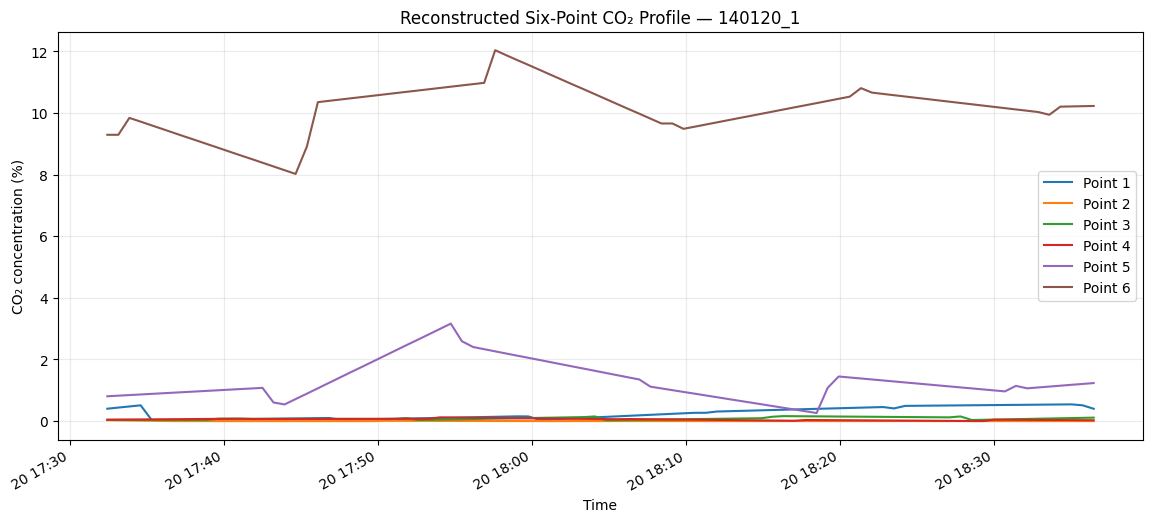

In [29]:
# Reconstructing the six-point CO2 profile for one development run

example_file = RAW_DATA_DIR / "140120_1.xlsx"

df_example = pd.read_excel(
    example_file,
    sheet_name=0,
    header=[0, 1]
)

example_time = pd.to_datetime(df_example.iloc[:, 0])
example_at400 = df_example[("AT400", "(CO2 %)")]
example_label = df_example.iloc[:, -1].astype(int)

example_targets = pd.DataFrame(
    index=df_example.index
)

for point in range(1, 7):
    example_targets[f"Point {point}"] = np.where(
        example_label == point,
        example_at400,
        np.nan
    )

# Interpolating only between real observations
example_targets_interp = example_targets.interpolate(
    method="linear",
    limit_area="inside"
)

# Determining common measurement-supported region
first_rows = [
    example_targets.index[example_targets[col].notna()].min()
    for col in example_targets.columns
]

last_rows = [
    example_targets.index[example_targets[col].notna()].max()
    for col in example_targets.columns
]

common_start = max(first_rows)
common_end = min(last_rows)

# Plot
ax = example_targets_interp.loc[
    common_start:common_end
].set_axis(
    example_time.loc[common_start:common_end]
).plot(
    figsize=(14, 6),
    linewidth=1.5
)

ax.set_title("Reconstructed Six-Point CO₂ Profile — 140120_1")
ax.set_xlabel("Time")
ax.set_ylabel("CO₂ concentration (%)")
ax.grid(alpha=0.25)

In [30]:
# Summarizin reconstructed CO2 concentration by sampling point across all development runs

point_summary_rows = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    at400 = df[("AT400", "(CO2 %)")]
    labels = df.iloc[:, -1].astype(int)

    sparse_targets = pd.DataFrame(index=df.index)

    for point in range(1, 7):
        sparse_targets[f"Point {point}"] = np.where(
            labels == point,
            at400,
            np.nan
        )

    # Interpolating only between real measurements
    interpolated_targets = sparse_targets.interpolate(
        method="linear",
        limit_area="inside"
    )

    # Restricting to region supported for all six points
    first_rows = [
        sparse_targets.index[sparse_targets[col].notna()].min()
        for col in sparse_targets.columns
    ]

    last_rows = [
        sparse_targets.index[sparse_targets[col].notna()].max()
        for col in sparse_targets.columns
    ]

    common_start = max(first_rows)
    common_end = min(last_rows)

    supported = interpolated_targets.loc[
        common_start:common_end
    ]

    for point in range(1, 7):
        values = supported[f"Point {point}"]

        point_summary_rows.append({
            "file": path.name,
            "point": point,
            "mean_CO2": values.mean(),
            "min_CO2": values.min(),
            "max_CO2": values.max()
        })

point_summary = pd.DataFrame(point_summary_rows)

point_summary.round(3)

,file,point,mean_CO2,min_CO2,max_CO2
0,140120_1.xlsx,1,0.256,0.023,0.543
1,140120_1.xlsx,2,0.002,0.000,0.029
2,140120_1.xlsx,3,0.085,0.029,0.162
3,140120_1.xlsx,4,0.054,0.002,0.120
4,140120_1.xlsx,5,1.307,0.263,3.164
5,140120_1.xlsx,6,10.127,8.022,12.037
6,140206_1.xlsx,1,0.025,0.002,0.062
7,140206_1.xlsx,2,0.022,0.012,0.058
8,140206_1.xlsx,3,0.038,0.002,0.075
9,140206_1.xlsx,4,0.001,0.000,0.002


In [31]:
# Quantifying temporal variability of each reconstructed CO2 target across the development runs

point_variability_rows = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    at400 = df[("AT400", "(CO2 %)")]
    labels = df.iloc[:, -1].astype(int)

    sparse_targets = pd.DataFrame(index=df.index)

    for point in range(1, 7):
        sparse_targets[f"Point {point}"] = np.where(
            labels == point,
            at400,
            np.nan
        )

    interpolated_targets = sparse_targets.interpolate(
        method="linear",
        limit_area="inside"
    )

    first_rows = [
        sparse_targets.index[sparse_targets[col].notna()].min()
        for col in sparse_targets.columns
    ]

    last_rows = [
        sparse_targets.index[sparse_targets[col].notna()].max()
        for col in sparse_targets.columns
    ]

    common_start = max(first_rows)
    common_end = min(last_rows)

    supported = interpolated_targets.loc[
        common_start:common_end
    ]

    for point in range(1, 7):
        values = supported[f"Point {point}"]

        point_variability_rows.append({
            "file": path.name,
            "point": point,
            "mean_CO2": values.mean(),
            "std_CO2": values.std(),
            "range_CO2": values.max() - values.min()
        })

point_variability = pd.DataFrame(
    point_variability_rows
)

point_variability.round(3)

,file,point,mean_CO2,std_CO2,range_CO2
0,140120_1.xlsx,1,0.256,0.185,0.520
1,140120_1.xlsx,2,0.002,0.005,0.029
2,140120_1.xlsx,3,0.085,0.038,0.133
3,140120_1.xlsx,4,0.054,0.028,0.118
4,140120_1.xlsx,5,1.307,0.621,2.902
5,140120_1.xlsx,6,10.127,0.799,4.015
6,140206_1.xlsx,1,0.025,0.018,0.060
7,140206_1.xlsx,2,0.022,0.016,0.045
8,140206_1.xlsx,3,0.038,0.023,0.073
9,140206_1.xlsx,4,0.001,0.001,0.002


In [32]:
# Measuring how much the six-point CO2 profile changes over different future horizons

candidate_horizons = [1, 3, 6, 12, 18]

horizon_change_rows = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    at400 = df[("AT400", "(CO2 %)")]
    labels = df.iloc[:, -1].astype(int)

    sparse_targets = pd.DataFrame(index=df.index)

    for point in range(1, 7):
        sparse_targets[f"Point {point}"] = np.where(
            labels == point,
            at400,
            np.nan
        )

    targets = sparse_targets.interpolate(
        method="linear",
        limit_area="inside"
    )

    # Keeping only common measurement-supported region
    valid = targets.dropna()

    for h in candidate_horizons:
        if len(valid) <= h:
            continue

        change = (
            valid.shift(-h) - valid
        ).iloc[:-h].abs()

        horizon_change_rows.append({
            "file": path.name,
            "horizon_steps": h,
            "horizon_minutes": h * 43.2 / 60,
            "mean_abs_profile_change": change.mean().mean()
        })

horizon_change = pd.DataFrame(horizon_change_rows)

horizon_change.groupby(
    ["horizon_steps", "horizon_minutes"]
)["mean_abs_profile_change"].agg(
    ["mean", "median", "min", "max"]
).round(4)

,,mean,median,min,max
horizon_steps,horizon_minutes,,,,
1,0.72,0.0285,0.0256,0.0148,0.0460
3,2.16,0.0710,0.0657,0.0330,0.1130
6,4.32,0.1152,0.1149,0.0579,0.1912
12,8.64,0.1680,0.1587,0.0765,0.2994
18,12.96,0.1946,0.1536,0.0717,0.3558


In [33]:
# Verifying that the fully supported target region is contiguous within every development run

contiguity_summary = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    at400 = df[("AT400", "(CO2 %)")]
    labels = df.iloc[:, -1].astype(int)

    sparse_targets = pd.DataFrame(index=df.index)

    for point in range(1, 7):
        sparse_targets[f"Point {point}"] = np.where(
            labels == point,
            at400,
            np.nan
        )

    targets = sparse_targets.interpolate(
        method="linear",
        limit_area="inside"
    )

    valid_idx = targets.dropna().index.to_numpy()

    index_gaps = np.diff(valid_idx)

    contiguity_summary.append({
        "file": path.name,
        "n_valid_rows": len(valid_idx),
        "first_valid_row": valid_idx[0],
        "last_valid_row": valid_idx[-1],
        "all_consecutive": np.all(index_gaps == 1),
        "largest_index_gap": index_gaps.max()
    })

pd.DataFrame(contiguity_summary)

,file,n_valid_rows,first_valid_row,last_valid_row,all_consecutive,largest_index_gap
0,140120_1.xlsx,90,13,102,True,1
1,140206_1.xlsx,22,14,35,True,1
2,140207_2.xlsx,23,13,35,True,1
3,140214_1.xlsx,39,14,52,True,1
4,140214_2.xlsx,23,13,35,True,1
5,140227_1.xlsx,191,14,204,True,1
6,140313_1.xlsx,202,13,214,True,1


In [34]:
# Counting valid forecast examples available at each candidate horizon

forecast_sample_rows = []

for _, row in target_coverage_summary.iterrows():
    n = row["supported_rows"]

    for h in candidate_horizons:
        n_forecasts = max(0, n - h)

        forecast_sample_rows.append({
            "file": row["file"],
            "horizon_steps": h,
            "horizon_minutes": h * 43.2 / 60,
            "n_forecasts": n_forecasts
        })

forecast_samples = pd.DataFrame(forecast_sample_rows)

forecast_sample_table = forecast_samples.pivot(
    index="file",
    columns="horizon_steps",
    values="n_forecasts"
)

forecast_sample_table.loc["TOTAL"] = (
    forecast_sample_table.sum()
)

forecast_sample_table

horizon_steps,1,3,6,12,18
file,,,,,
140120_1.xlsx,89,87,84,78,72
140206_1.xlsx,21,19,16,10,4
140207_2.xlsx,22,20,17,11,5
140214_1.xlsx,38,36,33,27,21
140214_2.xlsx,22,20,17,11,5
140227_1.xlsx,190,188,185,179,173
140313_1.xlsx,201,199,196,190,184
TOTAL,583,569,548,506,464


In [35]:
# Counting usable forecasting windows for combinations of context length L and future horizon h

candidate_contexts = [6, 12, 18, 24]

window_count_rows = []

for _, row in target_coverage_summary.iterrows():
    n = int(row["supported_rows"])

    for context in candidate_contexts:
        for horizon in candidate_horizons:

            n_windows = max(
                0,
                n - context - horizon + 1
            )

            window_count_rows.append({
                "file": row["file"],
                "context_steps": context,
                "horizon_steps": horizon,
                "n_windows": n_windows
            })

window_counts = pd.DataFrame(window_count_rows)

window_count_table = (
    window_counts
    .groupby(["context_steps", "horizon_steps"])["n_windows"]
    .sum()
    .unstack()
)

window_count_table

horizon_steps,1,3,6,12,18
context_steps,,,,,
6,548,534,513,471,430
12,506,492,471,430,406
18,464,450,430,406,382
24,426,418,406,382,360


In [36]:
# Per-run usable windows with an 18-step context

context = 18

per_run_windows = (
    window_counts[
        window_counts["context_steps"] == context
    ]
    .pivot(
        index="file",
        columns="horizon_steps",
        values="n_windows"
    )
)

per_run_windows.loc["TOTAL"] = per_run_windows.sum()

per_run_windows

horizon_steps,1,3,6,12,18
file,,,,,
140120_1.xlsx,72,70,67,61,55
140206_1.xlsx,4,2,0,0,0
140207_2.xlsx,5,3,0,0,0
140214_1.xlsx,21,19,16,10,4
140214_2.xlsx,5,3,0,0,0
140227_1.xlsx,173,171,168,162,156
140313_1.xlsx,184,182,179,173,167
TOTAL,464,450,430,406,382


In [37]:
# Number of experimental runs contributing at least one window for each context-length / forecast-horizon combination

run_coverage = (
    window_counts
    .assign(has_windows=lambda x: x["n_windows"] > 0)
    .groupby(["context_steps", "horizon_steps"])["has_windows"]
    .sum()
    .unstack()
)

run_coverage

horizon_steps,1,3,6,12,18
context_steps,,,,,
6,7,7,7,7,4
12,7,7,7,4,4
18,7,7,4,4,4
24,4,4,4,4,3


In [38]:
# Inspecting candidate dynamic process variables for temporal memory

candidate_sensors = [
    ("AT400", "(CO2 %)"),
    ("FT106", "(kg/hr)"),
    ("FT303", "(kg/hr)"),
    ("LT108", "(%)"),
    ("PDT105", "(mbar)"),
    ("TT107", "(°C)")
]

for sensor in candidate_sensors:
    print(sensor, sensor in df_test_raw.columns)

('AT400', '(CO2 %)') True
('FT106', '(kg/hr)') True
('FT303', '(kg/hr)') False
('LT108', '(%)') True
('PDT105', '(mbar)') False
('TT107', '(°C)') False


In [39]:
# Finding the exact column names and units for the sensors whose tuples did not match

for sensor_name in ["FT303", "PDT105", "TT107"]:
    matches = [
        col for col in df_test_raw.columns
        if col[0] == sensor_name
    ]

    print(f"{sensor_name}: {matches}")

FT303: [('FT303', 'm3/hr')]
PDT105: [('PDT105', '(barg)')]
TT107: [('TT107', '(0C)')]


In [40]:
# Autocorrelation of representative process variables calculated separately within each experimental run

candidate_sensors = [
    ("AT400", "(CO2 %)"),
    ("FT106", "(kg/hr)"),
    ("FT303", "m3/hr"),
    ("LT108", "(%)"),
    ("PDT105", "(barg)"),
    ("TT107", "(0C)")
]

lags = [1, 3, 6, 12, 18, 24]

autocorr_rows = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    for sensor in candidate_sensors:
        series = df[sensor]

        for lag in lags:
      
            if len(series) > lag + 2:
                autocorr = series.autocorr(lag=lag)
            else:
                autocorr = np.nan

            autocorr_rows.append({
                "file": path.name,
                "sensor": sensor[0],
                "lag_steps": lag,
                "lag_minutes": lag * 43.2 / 60,
                "autocorrelation": autocorr
            })

autocorr_df = pd.DataFrame(autocorr_rows)

autocorr_summary = (
    autocorr_df
    .groupby(["sensor", "lag_steps"])["autocorrelation"]
    .agg(["mean", "median", "count"])
    .round(3)
)

autocorr_summary

<PROJECT_ROOT>/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
<PROJECT_ROOT>/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
<PROJECT_ROOT>/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
<PROJECT_ROOT>/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
<PROJECT_ROOT>/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
<PROJECT_ROOT>/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
<PROJECT_ROOT>/.venv/lib/python3.9/site-packages/numpy/lib

mean  median  count
sensor lag_steps                      
AT400  1          0.682   0.678      7
       3         -0.012  -0.052      7
       6         -0.274  -0.276      7
       12        -0.260  -0.247      7
       18         0.642   0.664      7
       24        -0.254  -0.270      7
FT106  1          0.981   0.981      2
       3          0.939   0.939      2
       6          0.869   0.869      2
       12         0.681   0.681      2
       18         0.903   0.903      1
       24         0.857   0.857      1
FT303  1          0.948   0.978      7
       3          0.888   0.923      7
       6          0.821   0.807      7
       12         0.613   0.701      7
       18         0.471   0.645      7
       24         0.292   0.311      7
LT108  1          0.781   0.799      7
       3         -0.223  -0.295      7
       6         -0.469  -0.605      7
       12        -0.034  -0.093      7
       18         0.359   0.375      7
       24        -0.416  -0.422      7
PDT105 1          0.831   0.962      7
       3          0.742   0.922      7
       6          0.738   0.880      7
       12         0.636   0.817      7
       18         0.628   0.745      7
       24         0.540   0.577      7
TT107  1          0.997   0.999      7
       3          0.973   0.995      7
       6          0.913   0.979      7
       12         0.750   0.912      7
       18         0.578   0.790      7
       24         0.414   0.694      7

In [41]:
# AT400 autocorrelation across a dense range of lags

at400_autocorr_rows = []

for path in train_files:
    df = pd.read_excel(
        path,
        sheet_name=0,
        header=[0, 1]
    )

    series = df[("AT400", "(CO2 %)")]

    for lag in range(1, 31):

        if len(series) > lag + 2:
            autocorr = series.autocorr(lag=lag)
        else:
            autocorr = np.nan

        at400_autocorr_rows.append({
            "file": path.name,
            "lag_steps": lag,
            "lag_minutes": lag * 43.2 / 60,
            "autocorrelation": autocorr
        })

at400_autocorr = pd.DataFrame(at400_autocorr_rows)

at400_autocorr_summary = (
    at400_autocorr
    .groupby(["lag_steps", "lag_minutes"])["autocorrelation"]
    .agg(["median", "mean", "count"])
    .reset_index()
)

at400_autocorr_summary.round(3)

,lag_steps,lag_minutes,median,mean,count
0,1,0.72,0.678,0.682,7
1,2,1.44,0.321,0.338,7
2,3,2.16,-0.052,-0.012,7
3,4,2.88,-0.136,-0.111,7
4,5,3.60,-0.212,-0.204,7
5,6,4.32,-0.276,-0.274,7
6,7,5.04,-0.280,-0.287,7
7,8,5.76,-0.285,-0.301,7
8,9,6.48,-0.295,-0.311,7
9,10,7.20,-0.303,-0.319,7


In [42]:
# Forecasting-window counts

correct_window_rows = []

for _, row in target_coverage_summary.iterrows():

    n_rows = next(
        len(
            pd.read_excel(
                path,
                sheet_name=0,
                header=[0, 1]
            )
        )
        for path in train_files
        if path.name == row["file"]
    )

    target_start = int(row["common_start"])
    target_end = int(row["common_end"])

    for context in candidate_contexts:
        for horizon in candidate_horizons:

            # t = final row of the historical input window
            earliest_t = max(
                context - 1,
                target_start - horizon
            )

            latest_t = min(
                n_rows - 1 - horizon,
                target_end - horizon
            )

            n_windows = max(
                0,
                latest_t - earliest_t + 1
            )

            correct_window_rows.append({
                "file": row["file"],
                "context_steps": context,
                "horizon_steps": horizon,
                "n_windows": n_windows
            })

correct_window_counts = pd.DataFrame(correct_window_rows)

correct_window_table = (
    correct_window_counts
    .groupby(
        ["context_steps", "horizon_steps"]
    )["n_windows"]
    .sum()
    .unstack()
)

correct_window_table

horizon_steps,1,3,6,12,18
context_steps,,,,,
6,590,590,590,565,523
12,590,586,565,523,481
18,558,544,523,481,439
24,516,502,481,439,412


In [43]:
# Number of experimental runs contributing at least one forecasting window for each context/horizon combination

correct_run_coverage = (
    correct_window_counts
    .assign(
        has_windows=lambda x: x["n_windows"] > 0
    )
    .groupby(
        ["context_steps", "horizon_steps"]
    )["has_windows"]
    .sum()
    .unstack()
)

correct_run_coverage

horizon_steps,1,3,6,12,18
context_steps,,,,,
6,7,7,7,7,7
12,7,7,7,7,7
18,7,7,7,7,7
24,7,7,7,7,4


In [44]:
# Per-run forecasting-window counts for an 18-step context

correct_per_run_l18 = (
    correct_window_counts[
        correct_window_counts["context_steps"] == 18
    ]
    .pivot(
        index="file",
        columns="horizon_steps",
        values="n_windows"
    )
)

correct_per_run_l18.loc["TOTAL"] = (
    correct_per_run_l18.sum()
)

correct_per_run_l18

horizon_steps,1,3,6,12,18
file,,,,,
140120_1.xlsx,85,83,80,74,68
140206_1.xlsx,18,16,13,7,1
140207_2.xlsx,18,16,13,7,1
140214_1.xlsx,35,33,30,24,18
140214_2.xlsx,18,16,13,7,1
140227_1.xlsx,187,185,182,176,170
140313_1.xlsx,197,195,192,186,180
TOTAL,558,544,523,481,439


## What the data exploration changes for the forecasting setup

A few details from the raw data affect how I set up the forecasting problem.

First, the eight files are separate experimental runs rather than one continuous time series. I therefore keep runs separate when constructing training and validation data instead of allowing windows to cross run boundaries.

Second, the rows are sampled at a nearly regular interval of 43–44 seconds. This makes row-based forecast horizons meaningful: for example, 6 rows correspond to about 4.3 minutes and 18 rows to about 12.9 minutes.

The CO₂ measurements also have an unusual structure. AT400 cycles through the six absorber sampling locations, so only one location is directly measured at a given row. The complete six-point CO₂ profile therefore contains interpolated values between direct measurements. I keep track of this distinction and later report results both for the full reconstructed profile and for directly measured targets only.

Finally, the process variables and CO₂ targets have very different numerical scales. Scaling is therefore fitted using training data only within each validation fold rather than once on the complete dataset.

These observations determine the main evaluation choices below: run-wise validation, causal forecasting windows, separate measured-only evaluation, and fold-specific preprocessing.

### Forecasting benchmark design

The challenge asks for forecasts over different future time windows, so I compare five forecast horizons:

- $h \in \{1, 3, 6, 12, 18\}$ rows ahead
- context lengths $L \in \{6, 12, 18\}$

I keep \(h=0\) separate as a contemporaneous CO₂-profile estimation baseline rather than treating it as a future forecast.

For a fair comparison across context lengths, I score them on the same target timestamps. The common target set is defined using the longest context, $L_{\max}=18$, so a shorter-context model gets less history without also getting an easier set of target rows.

All horizon, context-length, and model-selection decisions are made using the seven development runs. `140207_1.xlsx` remains held out until the final evaluation.

There is also an important measurement detail in the targets: AT400 directly measures only one of the six absorber locations at a given timestamp. Because of this, I report performance both on the complete interpolated six-point CO₂ profile and separately on values that were directly measured.

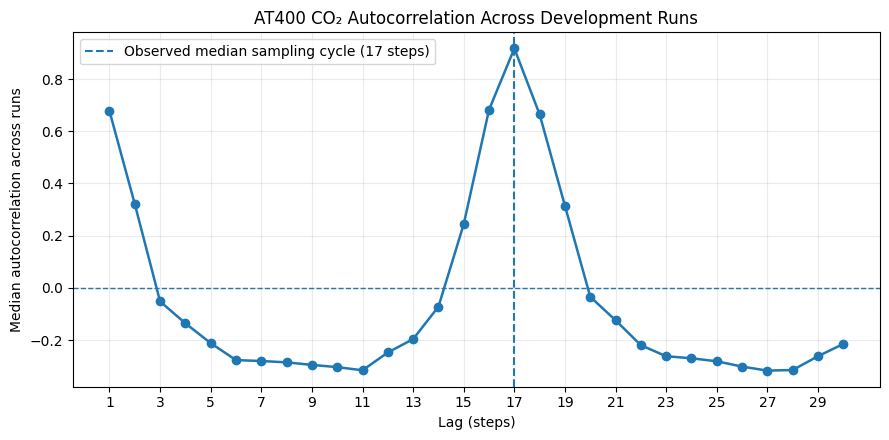

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4.5))

plt.plot(
    at400_autocorr_summary["lag_steps"],
    at400_autocorr_summary["median"],
    marker="o",
    linewidth=1.8
)

plt.axhline(0, linewidth=1, linestyle="--")

plt.axvline(
    17,
    linewidth=1.5,
    linestyle="--",
    label="Observed median sampling cycle (17 steps)"
)

plt.xlabel("Lag (steps)")
plt.ylabel("Median autocorrelation across runs")
plt.title("AT400 CO₂ Autocorrelation Across Development Runs")

plt.xticks(range(1, 31, 2))
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

The AT400 CO₂ signal has a strong periodic autocorrelation pattern. The median autocorrelation peaks at lag 17, or about 12.2 minutes, which is close to the observed ~17-row recurrence of the analyzer sampling sequence.

This initially looks like a useful timescale for choosing the model context. However, AT400 moves sequentially between absorber sampling locations, so part of this periodicity comes from the measurement schedule itself rather than necessarily from the underlying plant dynamics.

For that reason, I do not use the lag-17 autocorrelation alone to choose the forecasting context length. Context length is compared separately using the development runs.

In [46]:
from pathlib import Path

print(Path.cwd())

<PROJECT_ROOT>/notebooks


In [47]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

<PROJECT_ROOT>


In [48]:
from src.data import list_runs

runs = list_runs()

print(f"Number of experiment runs: {len(runs)}")

for name, path in runs.items():
    print(name, "->", path)

Number of experiment runs: 8
140120_1 -> <PROJECT_ROOT>/data/raw/140120_1.xlsx
140206_1 -> <PROJECT_ROOT>/data/raw/140206_1.xlsx
140207_1 -> <PROJECT_ROOT>/data/raw/140207_1.xlsx
140207_2 -> <PROJECT_ROOT>/data/raw/140207_2.xlsx
140214_1 -> <PROJECT_ROOT>/data/raw/140214_1.xlsx
140214_2 -> <PROJECT_ROOT>/data/raw/140214_2.xlsx
140227_1 -> <PROJECT_ROOT>/data/raw/140227_1.xlsx
140313_1 -> <PROJECT_ROOT>/data/raw/140313_1.xlsx


In [49]:
import src.data

print("Data directory:", src.data.RAW_DATA_DIR)
print("Exists:", src.data.RAW_DATA_DIR.exists())

runs = src.data.list_runs()

print(f"\nNumber of experiment runs: {len(runs)}")

for name, path in runs.items():
    print(name, "->", path.name)

Data directory: <PROJECT_ROOT>/data/raw
Exists: True

Number of experiment runs: 8
140120_1 -> 140120_1.xlsx
140206_1 -> 140206_1.xlsx
140207_1 -> 140207_1.xlsx
140207_2 -> 140207_2.xlsx
140214_1 -> 140214_1.xlsx
140214_2 -> 140214_2.xlsx
140227_1 -> 140227_1.xlsx
140313_1 -> 140313_1.xlsx


In [50]:
import src.data

runs = src.data.list_runs()
test_df = src.data.load_run(runs["140207_1"])

print("Shape:", test_df.shape)
print("First 5 columns:", test_df.columns[:5].tolist())
print("Last 5 columns:", test_df.columns[-5:].tolist())
print("Timestamp type:", test_df["timestamp"].dtype)
print("Label type:", test_df["label"].dtype)
print("Unique labels:", sorted(test_df["label"].unique()))
print("Duplicate column names:", test_df.columns.duplicated().sum())

Shape: (118, 92)
First 5 columns: ['timestamp', 'AT100', 'AT300', 'AT400', 'FT100']
Last 5 columns: ['TT410', 'TT411', 'TT412', 'TT413', 'label']
Timestamp type: datetime64[ns]
Label type: int64
Unique labels: [1, 2, 3, 4, 5, 6]
Duplicate column names: 0


In [52]:
import src.data

runs = src.data.list_runs()
test_df = src.data.load_run(runs["140207_1"])

sparse_targets = src.data.make_sparse_targets(test_df)

print("Target shape:", sparse_targets.shape)
print("Target columns:", sparse_targets.columns.tolist())

print("\nNumber of directly measured values at each point:")
print(sparse_targets.notna().sum())

sparse_targets.head(20)

Target shape: (118, 6)
Target columns: ['co2_point_1', 'co2_point_2', 'co2_point_3', 'co2_point_4', 'co2_point_5', 'co2_point_6']

Number of directly measured values at each point:
co2_point_1    21
co2_point_2    21
co2_point_3    21
co2_point_4    15
co2_point_5    19
co2_point_6    21
dtype: int64


,co2_point_1,co2_point_2,co2_point_3,co2_point_4,co2_point_5,co2_point_6
0,0.000827,NaN,NaN,NaN,NaN,NaN
1,0.000000,NaN,NaN,NaN,NaN,NaN
2,0.000000,NaN,NaN,NaN,NaN,NaN
3,NaN,0.000000,NaN,NaN,NaN,NaN
4,NaN,0.000000,NaN,NaN,NaN,NaN
5,NaN,0.000145,NaN,NaN,NaN,NaN
6,NaN,NaN,0.001831,NaN,NaN,NaN
7,NaN,NaN,0.035706,NaN,NaN,NaN
8,NaN,NaN,0.120664,NaN,NaN,NaN
9,NaN,NaN,NaN,0.077821,NaN,NaN


In [53]:
measurements_per_row = sparse_targets.notna().sum(axis=1)

print(measurements_per_row.value_counts().sort_index())
print(
    "Every timestamp has exactly one measured CO₂ point:",
    measurements_per_row.eq(1).all()
)

1    118
Name: count, dtype: int64
Every timestamp has exactly one measured CO₂ point: True


In [54]:
import src.data

runs = src.data.list_runs()
test_df = src.data.load_run(runs["140207_1"])

sparse_targets = src.data.make_sparse_targets(test_df)
interpolated_targets = src.data.interpolate_targets(sparse_targets)

print("Missing values after interpolation:")
print(interpolated_targets.isna().sum())

fully_supported = interpolated_targets.notna().all(axis=1)

print("\nFirst fully supported row:", interpolated_targets.index[fully_supported][0])
print("Last fully supported row:", interpolated_targets.index[fully_supported][-1])
print("Number of fully supported rows:", fully_supported.sum())

Missing values after interpolation:
co2_point_1    14
co2_point_2    14
co2_point_3    14
co2_point_4    15
co2_point_5    14
co2_point_6    14
dtype: int64

First fully supported row: 14
Last fully supported row: 103
Number of fully supported rows: 90


In [55]:
import src.data

runs = src.data.list_runs()

for run_name, path in runs.items():
    df = src.data.load_run(path)

    sparse_targets = src.data.make_sparse_targets(df)
    interpolated_targets = src.data.interpolate_targets(sparse_targets)

    start, end = src.data.get_supported_range(interpolated_targets)

    print(
        f"{run_name}: "
        f"rows={len(df)}, "
        f"supported={start}-{end}, "
        f"n_supported={end - start + 1}"
    )

140120_1: rows=117, supported=13-102, n_supported=90
140206_1: rows=50, supported=14-35, n_supported=22
140207_1: rows=118, supported=14-103, n_supported=90
140207_2: rows=50, supported=13-35, n_supported=23
140214_1: rows=67, supported=14-52, n_supported=39
140214_2: rows=50, supported=13-35, n_supported=23
140227_1: rows=218, supported=14-204, n_supported=191
140313_1: rows=228, supported=13-214, n_supported=202


In [56]:
example_memory = sparse_targets.ffill()

pd.concat(
    [
        test_df[["timestamp", "label", "AT400"]],
        sparse_targets.add_prefix("measured_"),
        example_memory.add_prefix("last_"),
    ],
    axis=1,
).head(20)

,timestamp,label,AT400,measured_co2_point_1,measured_co2_point_2,measured_co2_point_3,measured_co2_point_4,measured_co2_point_5,measured_co2_point_6,last_co2_point_1,last_co2_point_2,last_co2_point_3,last_co2_point_4,last_co2_point_5,last_co2_point_6
0,2014-02-07 11:56:10,1.0,0.000827,0.012360,NaN,NaN,NaN,NaN,NaN,0.012360,NaN,NaN,NaN,NaN,NaN
1,2014-02-07 11:56:53,1.0,0.000000,0.001831,NaN,NaN,NaN,NaN,NaN,0.001831,NaN,NaN,NaN,NaN,NaN
2,2014-02-07 11:57:36,1.0,0.000000,0.022889,NaN,NaN,NaN,NaN,NaN,0.022889,NaN,NaN,NaN,NaN,NaN
3,2014-02-07 11:58:19,2.0,0.000000,NaN,0.012360,NaN,NaN,NaN,NaN,0.022889,0.012360,NaN,NaN,NaN,NaN
4,2014-02-07 11:59:02,2.0,0.000000,NaN,0.001831,NaN,NaN,NaN,NaN,0.022889,0.001831,NaN,NaN,NaN,NaN
5,2014-02-07 11:59:46,2.0,0.000145,NaN,0.035706,NaN,NaN,NaN,NaN,0.022889,0.035706,NaN,NaN,NaN,NaN
6,2014-02-07 12:00:29,3.0,0.001831,NaN,NaN,0.088350,NaN,NaN,NaN,0.022889,0.035706,0.088350,NaN,NaN,NaN
7,2014-02-07 12:01:12,3.0,0.035706,NaN,NaN,0.108696,NaN,NaN,NaN,0.022889,0.035706,0.108696,NaN,NaN,NaN
8,2014-02-07 12:01:55,3.0,0.120664,NaN,NaN,0.386233,NaN,NaN,NaN,0.022889,0.035706,0.386233,NaN,NaN,NaN
9,2014-02-07 12:02:38,4.0,0.077821,NaN,NaN,NaN,0.336192,NaN,NaN,0.022889,0.035706,0.386233,0.336192,NaN,NaN


In [57]:
check_memory = pd.DataFrame({
    "label": test_df["label"],
    "AT400": test_df["AT400"],
    "measured_p1": sparse_targets["co2_point_1"],
    "measured_p2": sparse_targets["co2_point_2"],
    "last_p1": example_memory["co2_point_1"],
    "last_p2": example_memory["co2_point_2"],
})

print(check_memory.head(8).to_string())

   label     AT400  measured_p1  measured_p2   last_p1   last_p2
0    1.0  0.000827     0.012360          NaN  0.012360       NaN
1    1.0  0.000000     0.001831          NaN  0.001831       NaN
2    1.0  0.000000     0.022889          NaN  0.022889       NaN
3    2.0  0.000000          NaN     0.012360  0.022889  0.012360
4    2.0  0.000000          NaN     0.001831  0.022889  0.001831
5    2.0  0.000145          NaN     0.035706  0.022889  0.035706
6    3.0  0.001831          NaN          NaN  0.022889  0.035706
7    3.0  0.035706          NaN          NaN  0.022889  0.035706


In [58]:
test_df = src.data.load_run(runs["140207_1"])
test_sparse_targets = src.data.make_sparse_targets(test_df)

test_memory = test_sparse_targets.ffill()

check_memory = pd.DataFrame({
    "label": test_df["label"],
    "AT400": test_df["AT400"],
    "measured_p1": test_sparse_targets["co2_point_1"],
    "measured_p2": test_sparse_targets["co2_point_2"],
    "last_p1": test_memory["co2_point_1"],
    "last_p2": test_memory["co2_point_2"],
})

print(check_memory.head(8).to_string())

   label     AT400  measured_p1  measured_p2   last_p1   last_p2
0      1  0.000827     0.000827          NaN  0.000827       NaN
1      1  0.000000     0.000000          NaN  0.000000       NaN
2      1  0.000000     0.000000          NaN  0.000000       NaN
3      2  0.000000          NaN     0.000000  0.000000  0.000000
4      2  0.000000          NaN     0.000000  0.000000  0.000000
5      2  0.000145          NaN     0.000145  0.000000  0.000145
6      3  0.001831          NaN          NaN  0.000000  0.000145
7      3  0.035706          NaN          NaN  0.000000  0.000145


In [59]:
point = 1

is_measured = test_df["label"].eq(point)

age = []
last_measurement_row = None

for row_idx, measured_now in enumerate(is_measured):
    if measured_now:
        last_measurement_row = row_idx
        age.append(0)
    elif last_measurement_row is None:
        age.append(np.nan)
    else:
        age.append(row_idx - last_measurement_row)

age_check = pd.DataFrame({
    "label": test_df["label"],
    "AT400": test_df["AT400"],
    "point_1_measured": is_measured,
    "point_1_age": age,
})

print(age_check.head(20).to_string(index=True))

    label     AT400  point_1_measured  point_1_age
0       1  0.000827              True            0
1       1  0.000000              True            0
2       1  0.000000              True            0
3       2  0.000000             False            1
4       2  0.000000             False            2
5       2  0.000145             False            3
6       3  0.001831             False            4
7       3  0.035706             False            5
8       3  0.120664             False            6
9       4  0.077821             False            7
10      4  0.070853             False            8
11      5  0.608086             False            9
12      5  0.591897             False           10
13      5  0.602426             False           11
14      6  2.854569             False           12
15      6  2.728709             False           13
16      6  2.446819             False           14
17      1  0.000000              True            0
18      1  0.000000            

In [60]:
import src.data


test_df = src.data.load_run(runs["140207_1"])
test_ages = src.data.make_analyzer_age(test_df)

print(test_ages.head(20).to_string())

    age_point_1  age_point_2  age_point_3  age_point_4  age_point_5  age_point_6
0           0.0          NaN          NaN          NaN          NaN          NaN
1           0.0          NaN          NaN          NaN          NaN          NaN
2           0.0          NaN          NaN          NaN          NaN          NaN
3           1.0          0.0          NaN          NaN          NaN          NaN
4           2.0          0.0          NaN          NaN          NaN          NaN
5           3.0          0.0          NaN          NaN          NaN          NaN
6           4.0          1.0          0.0          NaN          NaN          NaN
7           5.0          2.0          0.0          NaN          NaN          NaN
8           6.0          3.0          0.0          NaN          NaN          NaN
9           7.0          4.0          1.0          0.0          NaN          NaN
10          8.0          5.0          2.0          0.0          NaN          NaN
11          9.0          6.0

In [61]:
test_sparse_targets = src.data.make_sparse_targets(test_df)
test_memory = src.data.make_analyzer_memory(test_sparse_targets)

test_memory.columns = [
    f"last_co2_point_{point}"
    for point in range(1, src.data.N_SAMPLING_POINTS + 1)
]

print(test_memory.head(20).to_string())

    last_co2_point_1  last_co2_point_2  last_co2_point_3  last_co2_point_4  last_co2_point_5  last_co2_point_6
0           0.000827               NaN               NaN               NaN               NaN               NaN
1           0.000000               NaN               NaN               NaN               NaN               NaN
2           0.000000               NaN               NaN               NaN               NaN               NaN
3           0.000000          0.000000               NaN               NaN               NaN               NaN
4           0.000000          0.000000               NaN               NaN               NaN               NaN
5           0.000000          0.000145               NaN               NaN               NaN               NaN
6           0.000000          0.000145          0.001831               NaN               NaN               NaN
7           0.000000          0.000145          0.035706               NaN               NaN               NaN
8

In [62]:
import src.data

test_df = src.data.load_run(runs["140207_1"])
test_label_features = src.data.make_label_features(test_df)

print("Shape:", test_label_features.shape)
print("Columns:", test_label_features.columns.tolist())
print()
print(test_label_features.head(20).to_string())

Shape: (118, 6)
Columns: ['sampling_point_1', 'sampling_point_2', 'sampling_point_3', 'sampling_point_4', 'sampling_point_5', 'sampling_point_6']

    sampling_point_1  sampling_point_2  sampling_point_3  sampling_point_4  sampling_point_5  sampling_point_6
0                1.0               0.0               0.0               0.0               0.0               0.0
1                1.0               0.0               0.0               0.0               0.0               0.0
2                1.0               0.0               0.0               0.0               0.0               0.0
3                0.0               1.0               0.0               0.0               0.0               0.0
4                0.0               1.0               0.0               0.0               0.0               0.0
5                0.0               1.0               0.0               0.0               0.0               0.0
6                0.0               0.0               1.0               0.0  

In [63]:
process_columns = [
    column
    for column in test_df.columns
    if column not in {
        "timestamp",
        "label",
        "AT400",
        "FT101",
        "FT107",
        "FT300",
    }
]

print("Number of process features:", len(process_columns))
print()
print(process_columns)

Number of process features: 86

['AT100', 'AT300', 'FT100', 'FT102', 'FT103', 'FT104', 'FT105', 'FT106', 'FT108', 'FT109', 'FT116', 'FT201', 'FT301', 'FT302', 'FT303', 'FT304', 'FT305', 'FT402', 'LT101', 'LT104', 'LT108', 'LT401', 'PDT105', 'PT102', 'PT103', 'PT104', 'PT110', 'PT111', 'PT115a', 'PT115b', 'PT401', 'PT402', 'PT403', 'TT100', 'TT102', 'TT103', 'TT104', 'TT105', 'TT107', 'TT108', 'TT109', 'TT110a', 'TT110b', 'TT112', 'TT113', 'TT117', 'TT118', 'TT119', 'TT120', 'TT121', 'TT200', 'TT201', 'TT202', 'TT203', 'TT204', 'TT205', 'TT206', 'TT207', 'TT208', 'TT209', 'TT210', 'TT211', 'TT213', 'TT214', 'TT215', 'TT216', 'TT217', 'TT300', 'TT301', 'TT302', 'TT303', 'TT304', 'TT305', 'TT306', 'TT307', 'TT308', 'TT309', 'TT400', 'TT401', 'TT402', 'TT403', 'TT404', 'TT410', 'TT411', 'TT412', 'TT413']


In [64]:
import src.data

test_df = src.data.load_run(runs["140207_1"])
test_process_features = src.data.make_process_features(test_df)

print("Shape:", test_process_features.shape)
print("Number of features:", test_process_features.shape[1])
print()
print("Excluded columns present?")
for column in ["timestamp", "label", "AT400", "FT101", "FT107", "FT300"]:
    print(f"{column}: {column in test_process_features.columns}")

print()
print("Missing values:", test_process_features.isna().sum().sum())

Shape: (118, 86)
Number of features: 86

Excluded columns present?
timestamp: False
label: False
AT400: False
FT101: False
FT107: False
FT300: False

Missing values: 0


In [66]:
for run_name, run_path in runs.items():
    df = src.data.load_run(run_path)

    sparse = src.data.make_sparse_targets(df)
    memory = src.data.make_analyzer_memory(sparse)
    ages = src.data.make_analyzer_age(df)

    memory_complete = memory.notna().all(axis=1)
    ages_complete = ages.notna().all(axis=1)
    analyzer_complete = memory_complete & ages_complete

    first_complete_row = analyzer_complete[analyzer_complete].index[0]

    print(
        f"{run_name}: "
        f"first row with complete analyzer history = {first_complete_row}"
    )

140120_1: first row with complete analyzer history = 13
140206_1: first row with complete analyzer history = 14
140207_1: first row with complete analyzer history = 14
140207_2: first row with complete analyzer history = 13
140214_1: first row with complete analyzer history = 14
140214_2: first row with complete analyzer history = 13
140227_1: first row with complete analyzer history = 14
140313_1: first row with complete analyzer history = 13


In [67]:
import src.data

test_df = src.data.load_run(runs["140207_1"])
test_features = src.data.make_model_features(test_df)

print("Shape:", test_features.shape)
print("Number of features:", test_features.shape[1])
print("Duplicate columns:", test_features.columns.duplicated().sum())
print("Total missing values:", test_features.isna().sum().sum())

missing_by_row = test_features.isna().sum(axis=1)
print("Last row with missing features:", missing_by_row[missing_by_row > 0].index.max())
print("Missing values from row 14 onward:", test_features.loc[14:].isna().sum().sum())

Shape: (118, 110)
Number of features: 110
Duplicate columns: 0
Total missing values: 86
Last row with missing features: 13
Missing values from row 14 onward: 0


In [68]:
L = 18
h = 6

test_targets = src.data.interpolate_targets(
    src.data.make_sparse_targets(test_df)
)

feature_complete = test_features.notna().all(axis=1)
target_complete = test_targets.notna().all(axis=1)

first_valid_feature_row = feature_complete[feature_complete].index[0]

input_start = first_valid_feature_row
input_end = input_start + L - 1
target_row = input_end + h

print("Context length L:", L)
print("Forecast horizon h:", h)
print()
print("Input rows:", input_start, "to", input_end)
print("Target row:", target_row)
print()
print("All input features valid:",
      test_features.loc[input_start:input_end].notna().all().all())
print("Target profile valid:",
      test_targets.loc[target_row].notna().all())
print()
print("X shape:", test_features.loc[input_start:input_end].shape)
print("y shape:", test_targets.loc[target_row].shape)

Context length L: 18
Forecast horizon h: 6

Input rows: 14 to 31
Target row: 37

All input features valid: True
Target profile valid: True

X shape: (18, 110)
y shape: (6,)


In [69]:
L = 18
h = 6

last_valid_target_row = target_complete[target_complete].index[-1]

input_end = last_valid_target_row - h
input_start = input_end - L + 1

print("Last supported target row:", last_valid_target_row)
print()
print("Input rows:", input_start, "to", input_end)
print("Target row:", last_valid_target_row)
print()
print(
    "All input features valid:",
    test_features.loc[input_start:input_end].notna().all().all()
)
print(
    "Target profile valid:",
    test_targets.loc[last_valid_target_row].notna().all()
)
print()
print("X shape:", test_features.loc[input_start:input_end].shape)
print("y shape:", test_targets.loc[last_valid_target_row].shape)

Last supported target row: 103

Input rows: 80 to 97
Target row: 103

All input features valid: True
Target profile valid: True

X shape: (18, 110)
y shape: (6,)


In [70]:
L = 18
h = 6

valid_samples = []

for target_row in test_targets.index:
    input_end = target_row - h
    input_start = input_end - L + 1

    if input_start < 0:
        continue

    X_window = test_features.loc[input_start:input_end]
    y_target = test_targets.loc[target_row]

    if len(X_window) != L:
        continue

    if not X_window.notna().all().all():
        continue

    if not y_target.notna().all():
        continue

    valid_samples.append(
        (input_start, input_end, target_row)
    )

print("Number of valid samples:", len(valid_samples))
print("First sample:", valid_samples[0])
print("Last sample:", valid_samples[-1])

Number of valid samples: 67
First sample: (14, 31, 37)
Last sample: (80, 97, 103)


In [71]:
import src.data


test_df = src.data.load_run(runs["140207_1"])

X_windows, y_targets, target_rows = src.data.make_forecast_windows(
    test_df,
    context_steps=18,
    horizon_steps=6,
)

print("Number of windows:", len(X_windows))
print("Number of targets:", len(y_targets))
print()

print("First X shape:", X_windows[0].shape)
print("First y shape:", y_targets[0].shape)
print()

print("First target row:", target_rows[0])
print("Last target row:", target_rows[-1])

Number of windows: 81
Number of targets: 81

First X shape: (18, 110)
First y shape: (6,)

First target row: 23
Last target row: 103


In [72]:
context_steps = 18
horizons = [1, 3, 6, 12, 18]

for run_name, run_path in runs.items():
    if run_name == src.data.TEST_RUN:
        continue

    df = src.data.load_run(run_path)

    counts = {}

    for h in horizons:
        X, y, target_rows = src.data.make_forecast_windows(
            df,
            context_steps=context_steps,
            horizon_steps=h,
        )

        counts[h] = len(X)

    print(f"{run_name}: {counts}")

140120_1: {1: 85, 3: 83, 6: 80, 12: 74, 18: 68}
140206_1: {1: 18, 3: 16, 6: 13, 12: 7, 18: 1}
140207_2: {1: 18, 3: 16, 6: 13, 12: 7, 18: 1}
140214_1: {1: 35, 3: 33, 6: 30, 12: 24, 18: 18}
140214_2: {1: 18, 3: 16, 6: 13, 12: 7, 18: 1}
140227_1: {1: 187, 3: 185, 6: 182, 12: 176, 18: 170}
140313_1: {1: 197, 3: 195, 6: 192, 12: 186, 18: 180}


In [73]:
horizons = [1, 3, 6, 12, 18]
context_steps = 18

total_counts = {h: 0 for h in horizons}

for run_name, run_path in runs.items():
    if run_name == src.data.TEST_RUN:
        continue

    df = src.data.load_run(run_path)

    for h in horizons:
        X, y, target_rows = src.data.make_forecast_windows(
            df,
            context_steps=context_steps,
            horizon_steps=h,
        )

        total_counts[h] += len(X)

print("Total development samples:")
for h, count in total_counts.items():
    print(f"h={h:2d}: {count} samples")

Total development samples:
h= 1: 558 samples
h= 3: 544 samples
h= 6: 523 samples
h=12: 481 samples
h=18: 439 samples


In [74]:
test_df = src.data.load_run(runs[src.data.TEST_RUN])

print("Locked test run:", src.data.TEST_RUN)

for h in [1, 3, 6, 12, 18]:
    X, y, target_rows = src.data.make_forecast_windows(
        test_df,
        context_steps=18,
        horizon_steps=h,
    )

    print(
        f"h={h:2d}: "
        f"{len(X):3d} samples, "
        f"target rows {target_rows[0]}-{target_rows[-1]}"
    )

Locked test run: 140207_1
h= 1:  86 samples, target rows 18-103
h= 3:  84 samples, target rows 20-103
h= 6:  81 samples, target rows 23-103
h=12:  75 samples, target rows 29-103
h=18:  69 samples, target rows 35-103


In [75]:
import src.data

runs = src.data.list_runs()

development_runs, test_run = src.data.split_run_names(runs)

print("Development runs:")
for run_name in development_runs:
    print(" ", run_name)

print()
print("Number of development runs:", len(development_runs))
print("Locked test run:", test_run)
print("Test run excluded from development:", test_run not in development_runs)

Development runs:
  140120_1
  140206_1
  140207_2
  140214_1
  140214_2
  140227_1
  140313_1

Number of development runs: 7
Locked test run: 140207_1
Test run excluded from development: True


In [76]:
context_steps = 18
horizons = [1, 3, 6, 12, 18]

for h in horizons:
    print(f"\nh = {h}")

    for run_name in development_runs:
        df = src.data.load_run(runs[run_name])

        X, y, target_rows = src.data.make_forecast_windows(
            df,
            context_steps=context_steps,
            horizon_steps=h,
        )

        status = "usable" if len(X) > 0 else "NO WINDOWS"

        print(
            f"  {run_name}: "
            f"{len(X):3d} samples  -> {status}"
        )


h = 1
  140120_1:  85 samples  -> usable
  140206_1:  18 samples  -> usable
  140207_2:  18 samples  -> usable
  140214_1:  35 samples  -> usable
  140214_2:  18 samples  -> usable
  140227_1: 187 samples  -> usable
  140313_1: 197 samples  -> usable

h = 3
  140120_1:  83 samples  -> usable
  140206_1:  16 samples  -> usable
  140207_2:  16 samples  -> usable
  140214_1:  33 samples  -> usable
  140214_2:  16 samples  -> usable
  140227_1: 185 samples  -> usable
  140313_1: 195 samples  -> usable

h = 6
  140120_1:  80 samples  -> usable
  140206_1:  13 samples  -> usable
  140207_2:  13 samples  -> usable
  140214_1:  30 samples  -> usable
  140214_2:  13 samples  -> usable
  140227_1: 182 samples  -> usable
  140313_1: 192 samples  -> usable

h = 12
  140120_1:  74 samples  -> usable
  140206_1:   7 samples  -> usable
  140207_2:   7 samples  -> usable
  140214_1:  24 samples  -> usable
  140214_2:   7 samples  -> usable
  140227_1: 176 samples  -> usable
  140313_1: 186 samples  -

In [77]:
context_lengths = [6, 12, 18]
horizons = [1, 3, 6, 12, 18]

for L in context_lengths:
    print(f"\nCONTEXT L = {L}")

    for h in horizons:
        total = 0

        for run_name in development_runs:
            df = src.data.load_run(runs[run_name])

            X, y, target_rows = src.data.make_forecast_windows(
                df,
                context_steps=L,
                horizon_steps=h,
            )

            total += len(X)

        print(f"  h={h:2d}: {total:3d} total samples")


CONTEXT L = 6
  h= 1: 590 total samples
  h= 3: 590 total samples
  h= 6: 590 total samples
  h=12: 565 total samples
  h=18: 523 total samples

CONTEXT L = 12
  h= 1: 590 total samples
  h= 3: 586 total samples
  h= 6: 565 total samples
  h=12: 523 total samples
  h=18: 481 total samples

CONTEXT L = 18
  h= 1: 558 total samples
  h= 3: 544 total samples
  h= 6: 523 total samples
  h=12: 481 total samples
  h=18: 439 total samples


In [78]:
run_name = "140120_1"
h = 6

df = src.data.load_run(runs[run_name])

X6, y6, rows6 = src.data.make_forecast_windows(
    df,
    context_steps=6,
    horizon_steps=h,
)

X12, y12, rows12 = src.data.make_forecast_windows(
    df,
    context_steps=12,
    horizon_steps=h,
)

X18, y18, rows18 = src.data.make_forecast_windows(
    df,
    context_steps=18,
    horizon_steps=h,
)

common_target_rows = rows18

print("L=6 available targets:", len(rows6))
print("L=12 available targets:", len(rows12))
print("L=18 available targets:", len(rows18))
print()
print("Common targets used for comparison:", len(common_target_rows))
print("First common target:", common_target_rows[0])
print("Last common target:", common_target_rows[-1])
print()
print("All L=18 targets exist for L=12:",
      set(common_target_rows).issubset(set(rows12)))
print("All L=18 targets exist for L=6:",
      set(common_target_rows).issubset(set(rows6)))

L=6 available targets: 90
L=12 available targets: 86
L=18 available targets: 80

Common targets used for comparison: 80
First common target: 23
Last common target: 102

All L=18 targets exist for L=12: True
All L=18 targets exist for L=6: True


In [79]:
context_lengths = [6, 12, 18]
horizons = [1, 3, 6, 12, 18]

all_checks_passed = True

for run_name in development_runs:
    df = src.data.load_run(runs[run_name])

    for h in horizons:
        target_rows = {}

        for L in context_lengths:
            X, y, rows = src.data.make_forecast_windows(
                df,
                context_steps=L,
                horizon_steps=h,
            )

            target_rows[L] = rows

        common_rows = set(target_rows[18])

        l12_contains = common_rows.issubset(set(target_rows[12]))
        l6_contains = common_rows.issubset(set(target_rows[6]))

        passed = l12_contains and l6_contains
        all_checks_passed = all_checks_passed and passed

        print(
            f"{run_name}, h={h:2d}: "
            f"L18 targets={len(common_rows):3d}, "
            f"L12 contains={l12_contains}, "
            f"L6 contains={l6_contains}"
        )

print()
print("All checks passed:", all_checks_passed)

140120_1, h= 1: L18 targets= 85, L12 contains=True, L6 contains=True
140120_1, h= 3: L18 targets= 83, L12 contains=True, L6 contains=True
140120_1, h= 6: L18 targets= 80, L12 contains=True, L6 contains=True
140120_1, h=12: L18 targets= 74, L12 contains=True, L6 contains=True
140120_1, h=18: L18 targets= 68, L12 contains=True, L6 contains=True
140206_1, h= 1: L18 targets= 18, L12 contains=True, L6 contains=True
140206_1, h= 3: L18 targets= 16, L12 contains=True, L6 contains=True
140206_1, h= 6: L18 targets= 13, L12 contains=True, L6 contains=True
140206_1, h=12: L18 targets=  7, L12 contains=True, L6 contains=True
140206_1, h=18: L18 targets=  1, L12 contains=True, L6 contains=True
140207_2, h= 1: L18 targets= 18, L12 contains=True, L6 contains=True
140207_2, h= 3: L18 targets= 16, L12 contains=True, L6 contains=True
140207_2, h= 6: L18 targets= 13, L12 contains=True, L6 contains=True
140207_2, h=12: L18 targets=  7, L12 contains=True, L6 contains=True
140207_2, h=18: L18 targets=  1, L

In [80]:
import src.data

df = src.data.load_run(runs["140120_1"])
h = 6


X6_all, y6_all, rows6_all = src.data.make_forecast_windows(
    df,
    context_steps=6,
    horizon_steps=h,
)

X12_all, y12_all, rows12_all = src.data.make_forecast_windows(
    df,
    context_steps=12,
    horizon_steps=h,
)

X18_all, y18_all, rows18_all = src.data.make_forecast_windows(
    df,
    context_steps=18,
    horizon_steps=h,
)

print("NORMAL BEHAVIOR")
print("L=6 :", len(X6_all))
print("L=12:", len(X12_all))
print("L=18:", len(X18_all))

common_target_rows = rows18_all

X6_common, y6_common, rows6_common = src.data.make_forecast_windows(
    df,
    context_steps=6,
    horizon_steps=h,
    allowed_target_rows=common_target_rows,
)

X12_common, y12_common, rows12_common = src.data.make_forecast_windows(
    df,
    context_steps=12,
    horizon_steps=h,
    allowed_target_rows=common_target_rows,
)

X18_common, y18_common, rows18_common = src.data.make_forecast_windows(
    df,
    context_steps=18,
    horizon_steps=h,
    allowed_target_rows=common_target_rows,
)

print()
print("COMMON-TARGET BEHAVIOR")
print("L=6 :", len(X6_common))
print("L=12:", len(X12_common))
print("L=18:", len(X18_common))

print()
print("Same target rows:")
print("L6 == L18 :", rows6_common == rows18_common)
print("L12 == L18:", rows12_common == rows18_common)

print()
print("Input shapes:")
print("L=6 :", X6_common[0].shape)
print("L=12:", X12_common[0].shape)
print("L=18:", X18_common[0].shape)

print()
print("Target shapes:")
print("L=6 :", y6_common[0].shape)
print("L=12:", y12_common[0].shape)
print("L=18:", y18_common[0].shape)

NORMAL BEHAVIOR
L=6 : 90
L=12: 86
L=18: 80

COMMON-TARGET BEHAVIOR
L=6 : 80
L=12: 80
L=18: 80

Same target rows:
L6 == L18 : True
L12 == L18: True

Input shapes:
L=6 : (6, 110)
L=12: (12, 110)
L=18: (18, 110)

Target shapes:
L=6 : (6,)
L=12: (6,)
L=18: (6,)


In [81]:
context_lengths = [6, 12, 18]
horizons = [1, 3, 6, 12, 18]

for h in horizons:
    totals = {L: 0 for L in context_lengths}

    for run_name in development_runs:
        df = src.data.load_run(runs[run_name])

        # Common target timestamps.
        _, _, common_target_rows = src.data.make_forecast_windows(
            df,
            context_steps=18,
            horizon_steps=h,
        )

        for L in context_lengths:
            X, y, target_rows = src.data.make_forecast_windows(
                df,
                context_steps=L,
                horizon_steps=h,
                allowed_target_rows=common_target_rows,
            )

            totals[L] += len(X)

    print(
        f"h={h:2d}: "
        f"L6={totals[6]:3d}, "
        f"L12={totals[12]:3d}, "
        f"L18={totals[18]:3d}"
    )

h= 1: L6=558, L12=558, L18=558
h= 3: L6=544, L12=544, L18=544
h= 6: L6=523, L12=523, L18=523
h=12: L6=481, L12=481, L18=481
h=18: L6=439, L12=439, L18=439


In [82]:
h = 6
L = 18

all_X = []
all_y = []
all_run_names = []
all_target_rows = []

for run_name in development_runs:
    df = src.data.load_run(runs[run_name])

    X, y, target_rows = src.data.make_forecast_windows(
        df,
        context_steps=L,
        horizon_steps=h,
    )

    all_X.extend(X)
    all_y.extend(y)
    all_run_names.extend([run_name] * len(X))
    all_target_rows.extend(target_rows)

print("Total samples:", len(all_X))
print("Total targets:", len(all_y))
print("Run labels:", len(all_run_names))
print("Target-row labels:", len(all_target_rows))

print()
print("Samples by run:")
for run_name in development_runs:
    print(
        f"{run_name}: "
        f"{all_run_names.count(run_name)}"
    )

Total samples: 523
Total targets: 523
Run labels: 523
Target-row labels: 523

Samples by run:
140120_1: 80
140206_1: 13
140207_2: 13
140214_1: 30
140214_2: 13
140227_1: 182
140313_1: 192


In [83]:
representative_columns = [
    "AT100",
    "AT300",
    "FT100",
    "LT101",
    "PT102",
    "TT100",
]

run_summary_rows = []

for run_name in development_runs:
    df = src.data.load_run(runs[run_name])

    row = {
        "run": run_name,
        "n_rows": len(df),
    }

    for column in representative_columns:
        row[f"{column}_mean"] = df[column].mean()
        row[f"{column}_std"] = df[column].std()

    run_summary_rows.append(row)

run_summary = pd.DataFrame(run_summary_rows)

print(run_summary.to_string(index=False))

     run  n_rows  AT100_mean  AT100_std  AT300_mean  AT300_std  FT100_mean  FT100_std  LT101_mean  LT101_std  PT102_mean  PT102_std  TT100_mean  TT100_std
140120_1     117    9.771282   0.215205   10.722302   0.139525   50.045218   0.501817   37.633314   6.956453    0.580250   0.125200  112.151095   2.749735
140206_1      50   10.007402   0.196115   10.786749   0.102701   49.959129   0.454249   23.729565   7.010215    0.728577   0.083930  114.608602   1.615812
140207_2      50   10.293663   0.058528   10.764185   0.030959   49.939210   0.186000   24.688818   7.611428    0.651219   0.060348  113.464406   1.306074
140214_1      67   10.345192   0.124439   10.835803   0.057432   50.030772   0.371695   23.200456   6.920807    0.996846   0.047127  120.041203   0.814298
140214_2      50   10.097705   0.100213   10.704696   0.042296   49.960992   0.241867   29.360512   8.566392    0.573239   0.064039  111.381452   1.393840
140227_1     218    9.988070   0.067172   10.851335   0.025597   50.02

In [84]:
horizons = [1, 3, 6, 12, 18]
reference_context = 18

eligible_validation_runs = {}

for h in horizons:
    eligible_validation_runs[h] = []

    for run_name in development_runs:
        df = src.data.load_run(runs[run_name])

        X, y, target_rows = src.data.make_forecast_windows(
            df,
            context_steps=reference_context,
            horizon_steps=h,
        )

        if len(X) > 0:
            eligible_validation_runs[h].append(run_name)

    print(
        f"h={h:2d}: "
        f"{len(eligible_validation_runs[h])} eligible validation runs -> "
        f"{eligible_validation_runs[h]}"
    )

h= 1: 7 eligible validation runs -> ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']
h= 3: 7 eligible validation runs -> ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']
h= 6: 7 eligible validation runs -> ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']
h=12: 7 eligible validation runs -> ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']
h=18: 7 eligible validation runs -> ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']


In [85]:
h = 6
validation_run = "140120_1"

eligible_runs = eligible_validation_runs[h]

training_runs = [
    run_name
    for run_name in eligible_runs
    if run_name != validation_run
]

print("Horizon:", h)
print("Validation run:", validation_run)

print()
print("Training runs:")
for run_name in training_runs:
    print(" ", run_name)

print()
print("Validation samples:")

validation_df = src.data.load_run(runs[validation_run])

X_val, y_val, val_rows = src.data.make_forecast_windows(
    validation_df,
    context_steps=18,
    horizon_steps=h,
)

print(len(X_val))

print()
print("Training samples:")

n_train = 0

for run_name in training_runs:
    df = src.data.load_run(runs[run_name])

    X, y, target_rows = src.data.make_forecast_windows(
        df,
        context_steps=18,
        horizon_steps=h,
    )

    n_train += len(X)

print(n_train)

print()
print(
    "Validation run absent from training:",
    validation_run not in training_runs,
)

Horizon: 6
Validation run: 140120_1

Training runs:
  140206_1
  140207_2
  140214_1
  140214_2
  140227_1
  140313_1

Validation samples:
80

Training samples:
443

Validation run absent from training: True


In [86]:
h = 6
reference_context = 18

eligible_runs = eligible_validation_runs[h]

for validation_run in eligible_runs:
    training_runs = [
        run_name
        for run_name in eligible_runs
        if run_name != validation_run
    ]

    # Validation sample count
    validation_df = src.data.load_run(runs[validation_run])

    X_val, y_val, val_rows = src.data.make_forecast_windows(
        validation_df,
        context_steps=reference_context,
        horizon_steps=h,
    )

    # Training sample count
    n_train = 0

    for run_name in training_runs:
        df = src.data.load_run(runs[run_name])

        X_train_run, y_train_run, train_rows = src.data.make_forecast_windows(
            df,
            context_steps=reference_context,
            horizon_steps=h,
        )

        n_train += len(X_train_run)

    print(
        f"Validation {validation_run}: "
        f"train={n_train:3d}, "
        f"val={len(X_val):3d}"
    )

Validation 140120_1: train=443, val= 80
Validation 140206_1: train=510, val= 13
Validation 140207_2: train=510, val= 13
Validation 140214_1: train=493, val= 30
Validation 140214_2: train=510, val= 13
Validation 140227_1: train=341, val=182
Validation 140313_1: train=331, val=192


In [87]:
horizons = [1, 3, 6, 12, 18]
reference_context = 18

for h in horizons:
    print(f"\nHORIZON h={h}")

    eligible_runs = eligible_validation_runs[h]

    total_samples = 0
    samples_by_run = {}

    for run_name in eligible_runs:
        df = src.data.load_run(runs[run_name])

        X, y, target_rows = src.data.make_forecast_windows(
            df,
            context_steps=reference_context,
            horizon_steps=h,
        )

        samples_by_run[run_name] = len(X)
        total_samples += len(X)

    for validation_run in eligible_runs:
        n_val = samples_by_run[validation_run]
        n_train = total_samples - n_val

        print(
            f"  Validation {validation_run}: "
            f"train={n_train:3d}, "
            f"val={n_val:3d}"
        )


HORIZON h=1
  Validation 140120_1: train=473, val= 85
  Validation 140206_1: train=540, val= 18
  Validation 140207_2: train=540, val= 18
  Validation 140214_1: train=523, val= 35
  Validation 140214_2: train=540, val= 18
  Validation 140227_1: train=371, val=187
  Validation 140313_1: train=361, val=197

HORIZON h=3
  Validation 140120_1: train=461, val= 83
  Validation 140206_1: train=528, val= 16
  Validation 140207_2: train=528, val= 16
  Validation 140214_1: train=511, val= 33
  Validation 140214_2: train=528, val= 16
  Validation 140227_1: train=359, val=185
  Validation 140313_1: train=349, val=195

HORIZON h=6
  Validation 140120_1: train=443, val= 80
  Validation 140206_1: train=510, val= 13
  Validation 140207_2: train=510, val= 13
  Validation 140214_1: train=493, val= 30
  Validation 140214_2: train=510, val= 13
  Validation 140227_1: train=341, val=182
  Validation 140313_1: train=331, val=192

HORIZON h=12
  Validation 140120_1: train=407, val= 74
  Validation 140206_1: 

In [88]:
import src.data

h = 6

for L in [6, 12, 18]:
    X, y, sample_runs, target_rows = src.data.build_forecast_dataset(
        runs=runs,
        run_names=development_runs,
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )

    print(f"L={L}")
    print("  samples:", len(X))
    print("  targets:", len(y))
    print("  run labels:", len(sample_runs))
    print("  target rows:", len(target_rows))
    print("  X shape:", X[0].shape)
    print("  y shape:", y[0].shape)
    print()

L=6
  samples: 523
  targets: 523
  run labels: 523
  target rows: 523
  X shape: (6, 110)
  y shape: (6,)

L=12
  samples: 523
  targets: 523
  run labels: 523
  target rows: 523
  X shape: (12, 110)
  y shape: (6,)

L=18
  samples: 523
  targets: 523
  run labels: 523
  target rows: 523
  X shape: (18, 110)
  y shape: (6,)



In [89]:
h = 6

datasets = {}

for L in [6, 12, 18]:
    X, y, sample_runs, target_rows = src.data.build_forecast_dataset(
        runs=runs,
        run_names=development_runs,
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )

    sample_ids = list(zip(sample_runs, target_rows))

    datasets[L] = {
        "X": X,
        "y": y,
        "sample_ids": sample_ids,
    }

print(
    "L6 sample IDs == L18:",
    datasets[6]["sample_ids"] == datasets[18]["sample_ids"],
)

print(
    "L12 sample IDs == L18:",
    datasets[12]["sample_ids"] == datasets[18]["sample_ids"],
)

print(
    "L6 targets == L18:",
    all(
        (y6 == y18).all()
        for y6, y18 in zip(
            datasets[6]["y"],
            datasets[18]["y"],
        )
    ),
)

print(
    "L12 targets == L18:",
    all(
        (y12 == y18).all()
        for y12, y18 in zip(
            datasets[12]["y"],
            datasets[18]["y"],
        )
    ),
)

L6 sample IDs == L18: True
L12 sample IDs == L18: True
L6 targets == L18: True
L12 targets == L18: True


In [90]:
import numpy as np

X, y, sample_runs, target_rows = src.data.build_forecast_dataset(
    runs=runs,
    run_names=development_runs,
    context_steps=18,
    horizon_steps=6,
    reference_context=18,
)

X = np.stack(X)
y = np.stack(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

print()
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

print()
print("NaNs in X:", np.isnan(X).sum())
print("NaNs in y:", np.isnan(y).sum())

print()
print("Infinite values in X:", np.isinf(X).sum())
print("Infinite values in y:", np.isinf(y).sum())

X shape: (523, 18, 110)
y shape: (523, 6)

X dtype: float32
y dtype: float32

NaNs in X: 3236
NaNs in y: 0

Infinite values in X: 0
Infinite values in y: 0


In [91]:
feature_names = list(
    src.data.make_model_features(
        src.data.load_run(runs["140120_1"])
    ).columns
)

print("Number of features:", len(feature_names))

print()
print("Feature ranges across all h=6, L=18 development windows:")

for feature_index, feature_name in enumerate(feature_names):
    values = X[:, :, feature_index]

    feature_min = values.min()
    feature_max = values.max()
    feature_mean = values.mean()
    feature_std = values.std()

    print(
        f"{feature_name:20s} "
        f"min={feature_min:10.3f} "
        f"max={feature_max:10.3f} "
        f"mean={feature_mean:10.3f} "
        f"std={feature_std:10.3f}"
    )

Number of features: 110

Feature ranges across all h=6, L=18 development windows:
AT100                min=     9.592 max=    10.732 mean=     9.869 std=     0.227
AT300                min=    10.432 max=    10.988 mean=    10.788 std=     0.088
FT100                min=    48.248 max=    51.723 mean=    50.007 std=     0.469
FT102                min=     0.000 max=  1051.554 mean=    63.421 std=   160.592
FT103                min=     0.000 max=   300.087 mean=   246.776 std=    25.431
FT104                min=     0.000 max=   286.318 mean=    71.742 std=   114.994
FT105                min=     0.070 max=     6.000 mean=     0.534 std=     1.268
FT106                min=     0.000 max=   219.085 mean=    38.825 std=    78.261
FT108                min=   131.275 max=   421.900 mean=   244.074 std=    28.091
FT109                min=   139.390 max=   425.368 mean=   245.766 std=    28.901
FT116                min=     0.000 max=     0.097 mean=     0.042 std=     0.031
FT201           

In [92]:
h = 6
L = 18

validation_run = "140120_1"

training_runs = [
    run_name
    for run_name in eligible_validation_runs[h]
    if run_name != validation_run
]


X_train, y_train, train_run_names, train_target_rows = (
    src.data.build_forecast_dataset(
        runs=runs,
        run_names=training_runs,
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )
)


X_val, y_val, val_run_names, val_target_rows = (
    src.data.build_forecast_dataset(
        runs=runs,
        run_names=[validation_run],
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )
)

X_train = np.stack(X_train)
y_train = np.stack(y_train)

X_val = np.stack(X_val)
y_val = np.stack(y_val)


feature_mean = X_train.mean(axis=(0, 1))
feature_std = X_train.std(axis=(0, 1))


safe_feature_std = np.where(
    feature_std < 1e-8,
    1.0,
    feature_std,
)

X_train_scaled = (
    X_train - feature_mean[None, None, :]
) / safe_feature_std[None, None, :]

X_val_scaled = (
    X_val - feature_mean[None, None, :]
) / safe_feature_std[None, None, :]

print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)

print()
print(
    "Training mean after scaling:",
    X_train_scaled.mean(),
)

print(
    "Training std after scaling:",
    X_train_scaled.std(),
)

print()
print(
    "Validation mean after training-based scaling:",
    X_val_scaled.mean(),
)

print(
    "Validation std after training-based scaling:",
    X_val_scaled.std(),
)

print()
print(
    "Number of zero/near-zero training feature stds:",
    (feature_std < 1e-8).sum(),
)

Training shape: (443, 18, 110)
Validation shape: (80, 18, 110)

Training mean after scaling: nan
Training std after scaling: nan

Validation mean after training-based scaling: nan
Validation std after training-based scaling: nan

Number of zero/near-zero training feature stds: 1


In [93]:
validation_feature_mean = X_val_scaled.mean(axis=(0, 1))
validation_feature_std = X_val_scaled.std(axis=(0, 1))
validation_feature_max_abs = np.abs(X_val_scaled).max(axis=(0, 1))

diagnostics = pd.DataFrame({
    "feature": feature_names,
    "train_std_raw": feature_std,
    "val_scaled_mean": validation_feature_mean,
    "val_scaled_std": validation_feature_std,
    "val_max_abs_z": validation_feature_max_abs,
})

diagnostics = diagnostics.sort_values(
    "val_max_abs_z",
    ascending=False,
)

print(
    diagnostics.head(15).to_string(
        index=False
    )
)

     feature  train_std_raw  val_scaled_mean  val_scaled_std  val_max_abs_z
       TT410       0.437923        43.153538       44.593285     187.054260
       TT309       0.887989         7.801486        4.938730      21.920601
       FT302       1.687470         0.507305        2.429789      15.479799
seen_point_2       0.067039         0.005191        0.960859      14.849300
       TT404       5.713319         3.906425        5.754200      12.372647
       TT109       1.803809         0.872256        1.512234      11.056509
       TT403       1.182137         3.293170        3.519675      10.236752
       FT301       1.463891         0.359979        1.709959       9.586153
       TT108       2.556264        -0.672723        2.733510       8.769707
seen_point_3       0.121747         0.003824        0.984647       8.090147
      TT110b       2.911272        -0.953545        2.661604       7.353183
       TT211       2.342168         0.410230        1.994737       6.797086
       TT210

In [94]:
sensor = "TT410"

print(f"{sensor} statistics by development run")
print()

for run_name in development_runs:
    df = src.data.load_run(runs[run_name])

    values = df[sensor]

    print(
        f"{run_name}: "
        f"min={values.min():8.3f}, "
        f"max={values.max():8.3f}, "
        f"mean={values.mean():8.3f}, "
        f"std={values.std():8.3f}"
    )

TT410 statistics by development run

140120_1: min=  22.659, max= 104.943, mean=  37.602, std=  17.517
140206_1: min=  22.055, max=  22.386, mean=  22.181, std=   0.072
140207_2: min=  23.360, max=  23.468, mean=  23.410, std=   0.028
140214_1: min=  22.190, max=  22.372, mean=  22.252, std=   0.048
140214_2: min=  23.082, max=  23.377, mean=  23.236, std=   0.071
140227_1: min=  22.508, max=  23.726, mean=  23.036, std=   0.402
140313_1: min=  22.769, max=  23.919, mean=  23.303, std=   0.374


In [95]:
df_140120 = src.data.load_run(runs["140120_1"])

tt410 = df_140120["TT410"]

print("Rows:", len(tt410))
print("Rows TT410 > 30:", int((tt410 > 30).sum()))
print("Rows TT410 > 50:", int((tt410 > 50).sum()))
print("Rows TT410 > 80:", int((tt410 > 80).sum()))

print()
print("TT410 by row:")
print(
    pd.DataFrame({
        "row": df_140120.index,
        "timestamp": df_140120["timestamp"],
        "TT410": tt410,
    }).to_string(index=False)
)

Rows: 117
Rows TT410 > 30: 81
Rows TT410 > 50: 16
Rows TT410 > 80: 6

TT410 by row:
 row           timestamp      TT410
   0 2014-01-20 17:23:02  22.658978
   1 2014-01-20 17:23:46  22.678768
   2 2014-01-20 17:24:29  22.689386
   3 2014-01-20 17:25:12  22.699842
   4 2014-01-20 17:25:55  22.714924
   5 2014-01-20 17:26:38  22.723614
   6 2014-01-20 17:27:22  22.718359
   7 2014-01-20 17:28:05  22.721807
   8 2014-01-20 17:28:48  22.715605
   9 2014-01-20 17:29:31  22.720787
  10 2014-01-20 17:30:14  22.720678
  11 2014-01-20 17:30:58  22.737127
  12 2014-01-20 17:31:41  22.743040
  13 2014-01-20 17:32:24  22.752834
  14 2014-01-20 17:33:07  22.749016
  15 2014-01-20 17:33:50  22.752716
  16 2014-01-20 17:34:34  22.752100
  17 2014-01-20 17:35:17  22.772713
  18 2014-01-20 17:36:00  22.798670
  19 2014-01-20 17:36:43  25.302490
  20 2014-01-20 17:37:26  64.188309
  21 2014-01-20 17:38:10 101.227867
  22 2014-01-20 17:38:53 104.943398
  23 2014-01-20 17:39:36 103.479912
  24 2014-01-20 

In [96]:
df_140120 = src.data.load_run(runs["140120_1"])

columns_to_check = [
    "TT410",
    "TT309",
    "FT303",
    "FT302",
    "TT404",
    "TT108",
    "TT110b",
    "TT403",
    "TT112",
    "TT107",
]

event_rows = [18, 19, 20, 21, 22, 23, 24, 25, 30, 40, 60, 80, 100, 116]

print(
    df_140120.loc[
        event_rows,
        ["timestamp"] + columns_to_check,
    ].to_string(index=True)
)

              timestamp       TT410      TT309      FT303      FT302       TT404      TT108     TT110b      TT403      TT112      TT107
18  2014-01-20 17:36:00   22.798670  22.583765  23.325577  19.550354  108.451141  37.195320  27.971071  22.649426  27.462532  26.472332
19  2014-01-20 17:36:43   25.302490  22.637465  23.362093  16.526695  108.293671  39.669746  28.080378  22.649426  27.506912  26.525953
20  2014-01-20 17:37:26   64.188309  22.697187  23.378620  14.887495  108.168304  41.920708  28.454639  23.751497  27.544989  26.544104
21  2014-01-20 17:38:10  101.227867  22.722668  23.395374  23.632710  108.112152  44.454422  30.135321  26.775045  27.609463  26.558689
22  2014-01-20 17:38:53  104.943398  22.635006  23.481741   0.000000  108.482307  46.088573  32.930084  28.229633  27.738859  26.573631
23  2014-01-20 17:39:36  103.479912  22.508560  23.716866   0.000000  109.297958  48.243195  36.047798  27.853083  28.171503  26.607597
24  2014-01-20 17:40:19   97.870491  24.038553  

In [97]:
h = 6
L = 18

for validation_run in eligible_validation_runs[h]:

    training_runs = [
        run_name
        for run_name in eligible_validation_runs[h]
        if run_name != validation_run
    ]

    X_train, _, _, _ = src.data.build_forecast_dataset(
        runs=runs,
        run_names=training_runs,
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )

    X_val, _, _, _ = src.data.build_forecast_dataset(
        runs=runs,
        run_names=[validation_run],
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )

    X_train = np.stack(X_train)
    X_val = np.stack(X_val)

    feature_mean = X_train.mean(axis=(0, 1))
    feature_std = X_train.std(axis=(0, 1))

    safe_feature_std = np.where(
        feature_std < 1e-8,
        1.0,
        feature_std,
    )

    X_val_scaled = (
        X_val - feature_mean[None, None, :]
    ) / safe_feature_std[None, None, :]

    max_abs_by_feature = np.abs(
        X_val_scaled
    ).max(axis=(0, 1))

    worst_feature_index = np.argmax(
        max_abs_by_feature
    )

    print(
        f"{validation_run}: "
        f"overall_std={X_val_scaled.std():8.3f}, "
        f"max_abs_z={max_abs_by_feature[worst_feature_index]:8.3f}, "
        f"worst_feature={feature_names[worst_feature_index]}"
    )

140120_1: overall_std=     nan, max_abs_z=     nan, worst_feature=last_co2_point_2
140206_1: overall_std=     nan, max_abs_z=     nan, worst_feature=last_co2_point_2
140207_2: overall_std=     nan, max_abs_z=     nan, worst_feature=last_co2_point_2
140214_1: overall_std=     nan, max_abs_z=     nan, worst_feature=last_co2_point_2
140214_2: overall_std=     nan, max_abs_z=     nan, worst_feature=last_co2_point_2
140227_1: overall_std=     nan, max_abs_z=     nan, worst_feature=last_co2_point_2
140313_1: overall_std=     nan, max_abs_z=     nan, worst_feature=last_co2_point_2


In [98]:
sensor = "FT106"

print(f"{sensor} statistics by development run")
print()

for run_name in development_runs:
    df = src.data.load_run(runs[run_name])

    values = df[sensor]

    print(
        f"{run_name}: "
        f"min={values.min():8.3f}, "
        f"max={values.max():8.3f}, "
        f"mean={values.mean():8.3f}, "
        f"std={values.std():8.3f}"
    )

FT106 statistics by development run

140120_1: min=   0.000, max=   0.000, mean=   0.000, std=   0.000
140206_1: min=   0.000, max=   0.000, mean=   0.000, std=   0.000
140207_2: min=   0.000, max=   0.000, mean=   0.000, std=   0.000
140214_1: min=   0.000, max=   0.000, mean=   0.000, std=   0.000
140214_2: min=   0.000, max=   0.000, mean=   0.000, std=   0.000
140227_1: min=   0.000, max=  94.074, mean=   5.531, std=  20.449
140313_1: min=   0.000, max= 225.889, mean= 115.467, std= 100.005


In [99]:
h = 6
L = 18
validation_run = "140313_1"

training_runs = [
    run_name
    for run_name in eligible_validation_runs[h]
    if run_name != validation_run
]

X_train, _, _, _ = src.data.build_forecast_dataset(
    runs=runs,
    run_names=training_runs,
    context_steps=L,
    horizon_steps=h,
    reference_context=18,
)

X_val, _, _, _ = src.data.build_forecast_dataset(
    runs=runs,
    run_names=[validation_run],
    context_steps=L,
    horizon_steps=h,
    reference_context=18,
)

X_train = np.stack(X_train)
X_val = np.stack(X_val)

# Standard scaling

train_mean = X_train.mean(axis=(0, 1))
train_std = X_train.std(axis=(0, 1))

safe_std = np.where(
    train_std < 1e-8,
    1.0,
    train_std,
)

X_val_standard = (
    X_val - train_mean[None, None, :]
) / safe_std[None, None, :]


# Robust scaling

train_median = np.median(
    X_train,
    axis=(0, 1),
)

train_q25 = np.percentile(
    X_train,
    25,
    axis=(0, 1),
)

train_q75 = np.percentile(
    X_train,
    75,
    axis=(0, 1),
)

train_iqr = train_q75 - train_q25

safe_iqr = np.where(
    train_iqr < 1e-8,
    1.0,
    train_iqr,
)

X_val_robust = (
    X_val - train_median[None, None, :]
) / safe_iqr[None, None, :]

print("STANDARD SCALING")
print("overall std:", X_val_standard.std())
print("maximum absolute value:", np.abs(X_val_standard).max())

print()
print("ROBUST SCALING")
print("overall std:", X_val_robust.std())
print("maximum absolute value:", np.abs(X_val_robust).max())

print()
print(
    "Features with zero/near-zero training IQR:",
    int((train_iqr < 1e-8).sum()),
)

STANDARD SCALING
overall std: nan
maximum absolute value: nan

ROBUST SCALING
overall std: nan
maximum absolute value: nan

Features with zero/near-zero training IQR: 14


In [100]:
std_diagnostics = pd.DataFrame({
    "feature": feature_names,
    "train_std": train_std,
})

std_diagnostics = std_diagnostics.sort_values(
    "train_std",
    ascending=True,
)

print(
    std_diagnostics.head(20).to_string(
        index=False
    )
)

         feature  train_std
           FT106   0.000000
    seen_point_1   0.000000
           LT104   0.005839
          PDT105   0.019313
           FT116   0.033332
           AT300   0.077305
    seen_point_2   0.077497
           FT105   0.098982
last_co2_point_1   0.136812
    seen_point_3   0.140482
           PT102   0.194211
    seen_point_4   0.204665
           AT100   0.206355
          PT115b   0.206910
           PT103   0.207743
          PT115a   0.209379
           PT401   0.212883
           PT402   0.212972
           TT117   0.219938
           PT403   0.225463


In [101]:
ft106_index = feature_names.index("FT106")

non_ft106_mask = np.ones(
    len(feature_names),
    dtype=bool,
)

non_ft106_mask[ft106_index] = False

X_val_without_ft106 = X_val_standard[
    :,
    :,
    non_ft106_mask,
]

print("Including FT106")
print("overall std:", X_val_standard.std())
print(
    "maximum absolute value:",
    np.abs(X_val_standard).max(),
)

print()
print("Diagnostic excluding FT106")
print("overall std:", X_val_without_ft106.std())
print(
    "maximum absolute value:",
    np.abs(X_val_without_ft106).max(),
)

max_abs_by_feature = np.abs(
    X_val_standard[:, :, non_ft106_mask]
).max(axis=(0, 1))

remaining_feature_names = np.array(
    feature_names
)[non_ft106_mask]

worst_index = np.argmax(max_abs_by_feature)

print()
print(
    "Worst remaining feature:",
    remaining_feature_names[worst_index],
)

print(
    "Worst remaining max |z|:",
    max_abs_by_feature[worst_index],
)

Including FT106
overall std: nan
maximum absolute value: nan

Diagnostic excluding FT106
overall std: nan
maximum absolute value: nan

Worst remaining feature: last_co2_point_2
Worst remaining max |z|: nan


In [102]:
sensor = "FT105"

print(f"{sensor} statistics by development run")
print()

for run_name in development_runs:
    df = src.data.load_run(runs[run_name])

    values = df[sensor]

    print(
        f"{run_name}: "
        f"min={values.min():8.3f}, "
        f"max={values.max():8.3f}, "
        f"mean={values.mean():8.3f}, "
        f"std={values.std():8.3f}"
    )

FT105 statistics by development run

140120_1: min=   0.075, max=   0.080, mean=   0.078, std=   0.001
140206_1: min=   0.075, max=   0.080, mean=   0.077, std=   0.001
140207_2: min=   0.078, max=   0.082, mean=   0.079, std=   0.001
140214_1: min=   0.074, max=   4.237, mean=   1.465, std=   1.956
140214_2: min=   0.072, max=   0.077, mean=   0.074, std=   0.001
140227_1: min=   0.076, max=   0.081, mean=   0.079, std=   0.001
140313_1: min=   0.070, max=   6.000, mean=   1.118, std=   1.755


In [103]:
X_val_bounded = np.tanh(
    X_val_standard
)

print("STANDARDIZED VALIDATION")
print(
    "mean:",
    X_val_standard.mean(),
)
print(
    "std:",
    X_val_standard.std(),
)
print(
    "min:",
    X_val_standard.min(),
)
print(
    "max:",
    X_val_standard.max(),
)

print()
print("STANDARDIZED + TANH")
print(
    "mean:",
    X_val_bounded.mean(),
)
print(
    "std:",
    X_val_bounded.std(),
)
print(
    "min:",
    X_val_bounded.min(),
)
print(
    "max:",
    X_val_bounded.max(),
)

print()
print("FT106 example")

ft106_index = feature_names.index(
    "FT106"
)

ft106_standard = X_val_standard[
    :,
    :,
    ft106_index,
]

ft106_bounded = X_val_bounded[
    :,
    :,
    ft106_index,
]

print(
    "standardized FT106 range:",
    ft106_standard.min(),
    "to",
    ft106_standard.max(),
)

print(
    "bounded FT106 range:",
    ft106_bounded.min(),
    "to",
    ft106_bounded.max(),
)

STANDARDIZED VALIDATION
mean: nan
std: nan
min: nan
max: nan

STANDARDIZED + TANH
mean: nan
std: nan
min: nan
max: nan

FT106 example
standardized FT106 range: 0.0 to 219.08461
bounded FT106 range: 0.0 to 1.0


In [104]:
ft106_index = feature_names.index("FT106")

ft106_raw = X_val[
    :,
    :,
    ft106_index,
].reshape(-1)

ft106_standard = X_val_standard[
    :,
    :,
    ft106_index,
].reshape(-1)

ft106_bounded = X_val_bounded[
    :,
    :,
    ft106_index,
].reshape(-1)

ft106_comparison = pd.DataFrame({
    "raw_FT106": ft106_raw,
    "standardized": ft106_standard,
    "tanh_standardized": ft106_bounded,
})

ft106_comparison = (
    ft106_comparison
    .drop_duplicates()
    .sort_values("raw_FT106")
)

sample_indices = np.linspace(
    0,
    len(ft106_comparison) - 1,
    min(15, len(ft106_comparison)),
    dtype=int,
)

print(
    ft106_comparison.iloc[
        sample_indices
    ].to_string(index=False)
)

 raw_FT106  standardized  tanh_standardized
  0.000000      0.000000                0.0
 88.093140     88.093140                1.0
184.591461    184.591461                1.0
191.345520    191.345520                1.0
192.118881    192.118881                1.0
194.324203    194.324203                1.0
197.029404    197.029404                1.0
200.596558    200.596558                1.0
201.601013    201.601013                1.0
204.471939    204.471939                1.0
208.628540    208.628540                1.0
209.975876    209.975876                1.0
212.361298    212.361298                1.0
217.512894    217.512894                1.0
219.084610    219.084610                1.0


In [105]:
h = 6
L = 18

thresholds = [5, 10, 20, 50, 100]

for validation_run in eligible_validation_runs[h]:

    training_runs = [
        run_name
        for run_name in eligible_validation_runs[h]
        if run_name != validation_run
    ]

    X_train, _, _, _ = src.data.build_forecast_dataset(
        runs=runs,
        run_names=training_runs,
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )

    X_val, _, _, _ = src.data.build_forecast_dataset(
        runs=runs,
        run_names=[validation_run],
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )

    X_train = np.stack(X_train)
    X_val = np.stack(X_val)

    train_mean = X_train.mean(axis=(0, 1))
    train_std = X_train.std(axis=(0, 1))

    safe_std = np.where(
        train_std < 1e-8,
        1.0,
        train_std,
    )

    X_val_scaled = (
        X_val - train_mean[None, None, :]
    ) / safe_std[None, None, :]

    max_abs_by_feature = np.abs(
        X_val_scaled
    ).max(axis=(0, 1))

    print(f"\nValidation run: {validation_run}")

    for threshold in thresholds:
        count = np.sum(
            max_abs_by_feature > threshold
        )

        print(
            f"features with max |z| > {threshold:3}: "
            f"{count:3} / {len(feature_names)}"
        )


Validation run: 140120_1
features with max |z| >   5:  20 / 110
features with max |z| >  10:   7 / 110
features with max |z| >  20:   2 / 110
features with max |z| >  50:   1 / 110
features with max |z| > 100:   1 / 110

Validation run: 140206_1
features with max |z| >   5:   8 / 110
features with max |z| >  10:   1 / 110
features with max |z| >  20:   0 / 110
features with max |z| >  50:   0 / 110
features with max |z| > 100:   0 / 110

Validation run: 140207_2
features with max |z| >   5:   3 / 110
features with max |z| >  10:   1 / 110
features with max |z| >  20:   0 / 110
features with max |z| >  50:   0 / 110
features with max |z| > 100:   0 / 110

Validation run: 140214_1
features with max |z| >   5:   4 / 110
features with max |z| >  10:   2 / 110
features with max |z| >  20:   0 / 110
features with max |z| >  50:   0 / 110
features with max |z| > 100:   0 / 110

Validation run: 140214_2
features with max |z| >   5:   6 / 110
features with max |z| >  10:   2 / 110
features wit

In [106]:
h = 6
L = 18

for validation_run in [
    "140120_1",
    "140313_1",
]:

    training_runs = [
        run_name
        for run_name in eligible_validation_runs[h]
        if run_name != validation_run
    ]

    X_train, _, _, _ = src.data.build_forecast_dataset(
        runs=runs,
        run_names=training_runs,
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )

    X_val, _, _, _ = src.data.build_forecast_dataset(
        runs=runs,
        run_names=[validation_run],
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )

    X_train = np.stack(X_train)
    X_val = np.stack(X_val)

    train_mean = X_train.mean(axis=(0, 1))
    train_std = X_train.std(axis=(0, 1))

    safe_std = np.where(
        train_std < 1e-8,
        1.0,
        train_std,
    )

    X_val_scaled = (
        X_val - train_mean[None, None, :]
    ) / safe_std[None, None, :]

    max_abs_by_feature = np.abs(
        X_val_scaled
    ).max(axis=(0, 1))

    diagnostics = pd.DataFrame({
        "feature": feature_names,
        "train_std": train_std,
        "max_abs_z": max_abs_by_feature,
    })

    diagnostics = (
        diagnostics[
            diagnostics["max_abs_z"] > 5
        ]
        .sort_values(
            "max_abs_z",
            ascending=False,
        )
    )

    print()
    print("=" * 60)
    print(f"Validation run: {validation_run}")
    print("=" * 60)

    print(
        diagnostics.to_string(
            index=False
        )
    )


Validation run: 140120_1
     feature  train_std  max_abs_z
       TT410   0.437923 187.054260
       TT309   0.887989  21.920601
       FT302   1.687470  15.479799
seen_point_2   0.067039  14.849300
       TT404   5.713319  12.372647
       TT109   1.803809  11.056509
       TT403   1.182137  10.236752
       FT301   1.463891   9.586153
       TT108   2.556264   8.769707
seen_point_3   0.121747   8.090147
      TT110b   2.911272   7.353183
       TT211   2.342168   6.797086
       TT210   2.344934   6.792901
       FT102 146.656952   6.761090
       LT104   0.005219   6.103102
       TT112   3.360352   6.081901
       FT201  10.281582   6.027073
seen_point_4   0.177933   5.436138
       FT303   5.374597   5.351251
       TT107   1.957847   5.173521

Validation run: 140313_1
     feature  train_std  max_abs_z
       FT106   0.000000 219.084610
       FT105   0.098982  59.792686
seen_point_2   0.077497  12.825784
       TT206   2.746088  10.626505
       TT207   3.039730  10.414474
   

In [107]:
h = 6
L = 18
validation_run = "140120_1"

training_runs = [
    run_name
    for run_name in eligible_validation_runs[h]
    if run_name != validation_run
]

X_train, _, train_sample_runs, train_target_rows = (
    src.data.build_forecast_dataset(
        runs=runs,
        run_names=training_runs,
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )
)

X_train = np.stack(X_train)

window_timestamp_count = (
    X_train.shape[0] * X_train.shape[1]
)

unique_input_positions = set()

for run_name, target_row in zip(
    train_sample_runs,
    train_target_rows,
):
    input_end = target_row - h
    input_start = input_end - L + 1

    for row in range(
        input_start,
        input_end + 1,
    ):
        unique_input_positions.add(
            (run_name, row)
        )

print(
    "Training windows:",
    X_train.shape[0],
)

print(
    "Total feature-row occurrences across windows:",
    window_timestamp_count,
)

print(
    "Unique underlying feature rows:",
    len(unique_input_positions),
)

print(
    "Average reuse per underlying row:",
    window_timestamp_count
    / len(unique_input_positions),
)

Training windows: 443
Total feature-row occurrences across windows: 7974
Unique underlying feature rows: 545
Average reuse per underlying row: 14.63119266055046


In [108]:
# Window-weighted statistics

window_mean = X_train.mean(
    axis=(0, 1)
)

window_std = X_train.std(
    axis=(0, 1)
)


# Unique-row statistics


unique_feature_rows = []

for run_name, row in sorted(
    unique_input_positions
):
    df = src.data.load_run(
        runs[run_name]
    )

    features = src.data.make_model_features(
        df
    )

    unique_feature_rows.append(
        features.loc[row].to_numpy(
            dtype="float32"
        )
    )

unique_feature_rows = np.stack(
    unique_feature_rows
)

unique_mean = unique_feature_rows.mean(
    axis=0
)

unique_std = unique_feature_rows.std(
    axis=0
)


# Comparing the estimates


mean_difference = np.abs(
    window_mean - unique_mean
)

std_difference = np.abs(
    window_std - unique_std
)

comparison = pd.DataFrame({
    "feature": feature_names,
    "window_mean": window_mean,
    "unique_mean": unique_mean,
    "mean_abs_difference": mean_difference,
    "window_std": window_std,
    "unique_std": unique_std,
    "std_abs_difference": std_difference,
})

print(
    "Unique feature-row matrix shape:",
    unique_feature_rows.shape,
)

print()

print(
    "Largest mean differences:"
)

print(
    comparison
    .sort_values(
        "mean_abs_difference",
        ascending=False,
    )
    .head(10)
    .to_string(index=False)
)

print()

print(
    "Largest standard-deviation differences:"
)

print(
    comparison
    .sort_values(
        "std_abs_difference",
        ascending=False,
    )
    .head(10)
    .to_string(index=False)
)

Unique feature-row matrix shape: (545, 110)

Largest mean differences:
feature  window_mean  unique_mean  mean_abs_difference  window_std  unique_std  std_abs_difference
  FT104    43.172253    68.187737            25.015484   99.552704  117.725105           18.172401
  FT402   567.029846   580.907349            13.877502  236.604675  237.452606            0.847931
  FT106    45.836842    40.644619             5.192223   83.123665   80.047272            3.076393
  FT109   244.198120   248.947647             4.749527   30.509752   34.810009            4.300257
  FT108   242.581177   247.024887             4.443710   29.523495   33.799088            4.275593
  FT103   245.434219   249.611694             4.177475   27.417419   31.004234            3.586815
  FT102    52.683918    55.896294             3.212376  146.656952  149.127213            2.470261
  TT205    58.871601    56.983486             1.888115    9.837945   10.348585            0.510640
  TT204    57.199120    55.349766     

In [109]:
import importlib
import src.data

importlib.reload(src.data)

<module 'src.data' from '<PROJECT_ROOT>/src/data.py'>

In [112]:
h = 6
L = 18
validation_run = "140120_1"

training_runs = [
    run_name
    for run_name in eligible_validation_runs[h]
    if run_name != validation_run
]

_, y_train, _, _ = (
    src.data.build_forecast_dataset(
        runs=runs,
        run_names=training_runs,
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )
)

y_train = np.stack(
    y_train
)

target_names = [
    f"co2_point_{point}"
    for point in range(1, 7)
]

target_diagnostics = pd.DataFrame({
    "target": target_names,
    "mean": y_train.mean(axis=0),
    "std": y_train.std(axis=0),
    "min": y_train.min(axis=0),
    "max": y_train.max(axis=0),
})

print(
    "Target matrix shape:",
    y_train.shape,
)

print()

print(
    target_diagnostics.to_string(
        index=False
    )
)

Target matrix shape: (443, 6)

     target     mean      std      min      max
co2_point_1 0.136511 0.145764 0.000000 0.512335
co2_point_2 0.005277 0.009001 0.000000 0.060463
co2_point_3 0.114154 0.084549 0.000000 0.421149
co2_point_4 0.168332 0.141753 0.000300 0.511959
co2_point_5 1.547916 1.067567 0.311073 4.469018
co2_point_6 4.806314 1.500468 2.158032 8.126155


In [113]:
h = 6
L = 18

for validation_run in eligible_validation_runs[h]:

    training_runs = [
        run_name
        for run_name in eligible_validation_runs[h]
        if run_name != validation_run
    ]

    _, y_train, _, _ = (
        src.data.build_forecast_dataset(
            runs=runs,
            run_names=training_runs,
            context_steps=L,
            horizon_steps=h,
            reference_context=18,
        )
    )

    _, y_val, _, _ = (
        src.data.build_forecast_dataset(
            runs=runs,
            run_names=[validation_run],
            context_steps=L,
            horizon_steps=h,
            reference_context=18,
        )
    )

    y_train = np.stack(y_train)
    y_val = np.stack(y_val)

    target_mean = y_train.mean(
        axis=0
    )

    target_std = y_train.std(
        axis=0
    )

    safe_target_std = np.where(
        target_std < 1e-8,
        1.0,
        target_std,
    )

    y_val_scaled = (
        y_val - target_mean
    ) / safe_target_std

    max_abs_z = np.abs(
        y_val_scaled
    ).max(axis=0)

    print()
    print(
        f"Validation run: {validation_run}"
    )

    for target_name, value in zip(
        target_names,
        max_abs_z,
    ):
        print(
            f"{target_name}: "
            f"max |z| = {value:.3f}"
        )


Validation run: 140120_1
co2_point_1: max |z| = 2.791
co2_point_2: max |z| = 0.586
co2_point_3: max |z| = 1.011
co2_point_4: max |z| = 1.175
co2_point_5: max |z| = 1.514
co2_point_6: max |z| = 4.819

Validation run: 140206_1
co2_point_1: max |z| = 0.925
co2_point_2: max |z| = 0.930
co2_point_3: max |z| = 0.952
co2_point_4: max |z| = 1.128
co2_point_5: max |z| = 0.980
co2_point_6: max |z| = 1.054

Validation run: 140207_2
co2_point_1: max |z| = 0.773
co2_point_2: max |z| = 0.355
co2_point_3: max |z| = 0.688
co2_point_4: max |z| = 0.862
co2_point_5: max |z| = 1.073
co2_point_6: max |z| = 1.042

Validation run: 140214_1
co2_point_1: max |z| = 1.029
co2_point_2: max |z| = 0.578
co2_point_3: max |z| = 1.491
co2_point_4: max |z| = 0.880
co2_point_5: max |z| = 1.257
co2_point_6: max |z| = 1.541

Validation run: 140214_2
co2_point_1: max |z| = 0.925
co2_point_2: max |z| = 1.468
co2_point_3: max |z| = 0.809
co2_point_4: max |z| = 0.820
co2_point_5: max |z| = 0.995
co2_point_6: max |z| = 0.566


In [114]:
import importlib
import src.data

importlib.reload(src.data)

<module 'src.data' from '<PROJECT_ROOT>/src/data.py'>

In [115]:
target_mean, target_std = (
    src.data.fit_target_scaler(
        y_train
    )
)

y_train_scaled = (
    src.data.transform_targets(
        y_train,
        target_mean,
        target_std,
    )
)

y_train_reconstructed = (
    src.data.inverse_transform_targets(
        y_train_scaled,
        target_mean,
        target_std,
    )
)

print(
    "Scaled target means:"
)

print(
    y_train_scaled.mean(axis=0)
)

print()

print(
    "Scaled target stds:"
)

print(
    y_train_scaled.std(axis=0)
)

print()

print(
    "All scaled values finite:",
    np.isfinite(
        y_train_scaled
    ).all(),
)

print(
    "Inverse transform matches original:",
    np.allclose(
        y_train_reconstructed,
        y_train,
        rtol=1e-5,
        atol=1e-6,
    ),
)

print(
    "Maximum reconstruction error:",
    np.abs(
        y_train_reconstructed
        - y_train
    ).max(),
)

Scaled target means:
[-6.0216900e-07  2.5084373e-07 -1.2208147e-06  9.2171109e-07
  5.6102198e-07  1.8367594e-08]

Scaled target stds:
[0.99999905 0.9999978  0.9999998  1.0000007  0.99999976 1.0000002 ]

All scaled values finite: True
Inverse transform matches original: True
Maximum reconstruction error: 2.3841858e-07


In [116]:
h = 6
L = 18

X_all, y_all, run_labels, target_rows = (
    src.data.build_forecast_dataset(
        runs=runs,
        run_names=development_runs,
        context_steps=L,
        horizon_steps=h,
        reference_context=18,
    )
)

X_all = np.stack(X_all)
y_all = np.stack(y_all)

feature_names_array = np.array(
    feature_names
)

memory_feature_names = [
    f"last_co2_point_{point}"
    for point in range(1, 7)
]

memory_indices = [
    np.where(
        feature_names_array == feature_name
    )[0][0]
    for feature_name in memory_feature_names
]

persistence_predictions = (
    X_all[
        :,
        -1,
        memory_indices,
    ]
)

print(
    "Input shape:",
    X_all.shape,
)

print(
    "Target shape:",
    y_all.shape,
)

print(
    "Persistence prediction shape:",
    persistence_predictions.shape,
)

print(
    "Memory feature indices:",
    memory_indices,
)

print()

print(
    "First persistence prediction:"
)

print(
    persistence_predictions[0]
)

print()

print(
    "Corresponding future target:"
)

print(
    y_all[0]
)

print()

print(
    "All persistence predictions finite:",
    np.isfinite(
        persistence_predictions
    ).all(),
)

Input shape: (523, 18, 110)
Target shape: (523, 6)
Persistence prediction shape: (523, 6)
Memory feature indices: [86, 87, 88, 89, 90, 91]

First persistence prediction:
[0.03570611 0.06729229 0.04623483 0.03570611 0.78686476 9.839528  ]

Corresponding future target:
[0.04896814 0.         0.07782101 0.07364826 1.0010157  8.869948  ]

All persistence predictions finite: True


In [117]:
errors = (
    persistence_predictions
    - y_all
)

mae_per_point = np.mean(
    np.abs(errors),
    axis=0,
)

rmse_per_point = np.sqrt(
    np.mean(
        errors ** 2,
        axis=0,
    )
)

overall_mae = np.mean(
    np.abs(errors)
)

overall_rmse = np.sqrt(
    np.mean(
        errors ** 2
    )
)

baseline_metrics = pd.DataFrame({
    "target": target_names,
    "MAE": mae_per_point,
    "RMSE": rmse_per_point,
})

print(
    baseline_metrics.to_string(
        index=False
    )
)

print()

print(
    f"Overall MAE:  {overall_mae:.6f}"
)

print(
    f"Overall RMSE: {overall_rmse:.6f}"
)

     target      MAE     RMSE
co2_point_1 0.073538 0.118939
co2_point_2 0.006435 0.014708
co2_point_3 0.061156 0.085485
co2_point_4 0.037386 0.058176
co2_point_5 0.328452 0.537214
co2_point_6 0.599626 0.832672

Overall MAE:  0.184432
Overall RMSE: 0.409674


In [118]:
target_mean_all, target_std_all = (
    src.data.fit_target_scaler(
        y_all
    )
)

y_all_scaled = (
    src.data.transform_targets(
        y_all,
        target_mean_all,
        target_std_all,
    )
)

persistence_scaled = (
    src.data.transform_targets(
        persistence_predictions,
        target_mean_all,
        target_std_all,
    )
)

normalized_errors = (
    persistence_scaled
    - y_all_scaled
)

normalized_rmse_per_point = np.sqrt(
    np.mean(
        normalized_errors ** 2,
        axis=0,
    )
)

overall_normalized_rmse = np.sqrt(
    np.mean(
        normalized_errors ** 2
    )
)

normalized_baseline_metrics = pd.DataFrame({
    "target": target_names,
    "normalized_RMSE": normalized_rmse_per_point,
})

print(
    normalized_baseline_metrics.to_string(
        index=False
    )
)

print()

print(
    f"Overall normalized RMSE: "
    f"{overall_normalized_rmse:.6f}"
)

     target  normalized_RMSE
co2_point_1         0.752972
co2_point_2         1.741892
co2_point_3         1.074706
co2_point_4         0.423748
co2_point_5         0.528869
co2_point_6         0.345777

Overall normalized RMSE: 0.942954


In [119]:
h = 6
L = 18

oof_targets_scaled = []
oof_predictions_scaled = []
oof_targets_raw = []
oof_predictions_raw = []
oof_run_names = []

for validation_run in eligible_validation_runs[h]:

    training_runs = [
        run_name
        for run_name in eligible_validation_runs[h]
        if run_name != validation_run
    ]

    X_train, y_train_fold, _, _ = (
        src.data.build_forecast_dataset(
            runs=runs,
            run_names=training_runs,
            context_steps=L,
            horizon_steps=h,
            reference_context=18,
        )
    )

    X_val, y_val_fold, _, _ = (
        src.data.build_forecast_dataset(
            runs=runs,
            run_names=[validation_run],
            context_steps=L,
            horizon_steps=h,
            reference_context=18,
        )
    )

    X_val = np.stack(X_val)
    y_train_fold = np.stack(y_train_fold)
    y_val_fold = np.stack(y_val_fold)

    target_mean, target_std = (
        src.data.fit_target_scaler(
            y_train_fold
        )
    )

    persistence_val = X_val[
        :,
        -1,
        memory_indices,
    ]

    y_val_scaled = (
        src.data.transform_targets(
            y_val_fold,
            target_mean,
            target_std,
        )
    )

    persistence_val_scaled = (
        src.data.transform_targets(
            persistence_val,
            target_mean,
            target_std,
        )
    )

    oof_targets_scaled.append(
        y_val_scaled
    )

    oof_predictions_scaled.append(
        persistence_val_scaled
    )

    oof_targets_raw.append(
        y_val_fold
    )

    oof_predictions_raw.append(
        persistence_val
    )

    oof_run_names.extend(
        [validation_run] * len(y_val_fold)
    )


oof_targets_scaled = np.concatenate(
    oof_targets_scaled,
    axis=0,
)

oof_predictions_scaled = np.concatenate(
    oof_predictions_scaled,
    axis=0,
)

oof_targets_raw = np.concatenate(
    oof_targets_raw,
    axis=0,
)

oof_predictions_raw = np.concatenate(
    oof_predictions_raw,
    axis=0,
)


normalized_oof_rmse = np.sqrt(
    np.mean(
        (
            oof_predictions_scaled
            - oof_targets_scaled
        ) ** 2
    )
)

raw_oof_rmse = np.sqrt(
    np.mean(
        (
            oof_predictions_raw
            - oof_targets_raw
        ) ** 2
    )
)

print(
    "OOF samples:",
    len(oof_targets_raw),
)

print(
    "OOF normalized RMSE:",
    normalized_oof_rmse,
)

print(
    "OOF raw RMSE:",
    raw_oof_rmse,
)

print(
    "Run counts:"
)

print(
    pd.Series(
        oof_run_names
    ).value_counts().sort_index()
)

OOF samples: 523
OOF normalized RMSE: 2.0269012
OOF raw RMSE: 0.40967387
Run counts:
140120_1     80
140206_1     13
140207_2     13
140214_1     30
140214_2     13
140227_1    182
140313_1    192
Name: count, dtype: int64


## Forecasting Design, Validation, and Preprocessing

### Causal forecasting setup

For a context ending at row \(t\), the model predicts the six-point CO₂ profile at row \(t+h\). Inputs are restricted to information available at or before row \(t\); no process measurements or CO₂ observations from the forecast interval are used.

Windows are constructed separately within each experimental run, so a sequence never crosses from one run into another.

### Input representation

Each row is represented by 110 causal input features:

- **86 process variables** retained after removing constant channels;
- **6 last-observed CO₂ values**, one for each absorber sampling point;
- **6 measurement-age variables**, recording how many rows have passed since each point was directly measured;
- **6 seen-point indicators**, recording whether each sampling point has been observed yet in the current run;
- **6 one-hot sampling-location indicators** derived from `label`.

The last-observed CO₂ features are updated only when the corresponding sampling point is directly measured. They are therefore available at forecast time and do not use the future interpolated target profile.

The age and seen-point features are important near the beginning of a run. In particular, the seen-point indicators distinguish a sampling location that has not yet been observed from one whose stored value happens to be close to the feature fill value.

### Run-wise validation

The eight files represent separate experimental runs, so I use runs rather than overlapping windows as the unit of data separation.

`140207_1.xlsx` is kept locked for the final test. The remaining seven runs are used for development. Model selection is performed with leave-one-run-out validation inside the development set, which tests whether a model trained on other experiments transfers to an unseen run.

All seven development runs are retained in the final forecasting pipeline.

### Scaling without leakage

Feature scaling is fitted separately inside each training fold and then applied to that fold's validation run. Target scaling for learned models follows the same training-only rule.

Binary seen-point indicators and sampling-location indicators are not standardized.

This is intentionally stricter than fitting one scaler to all development data: the validation run does not contribute to the preprocessing statistics used to evaluate it.

### Distribution shift

I do not clip validation or test features simply because they fall outside the range seen during training. Large standardized values are kept as a diagnostic of between-run distribution shift rather than being silently forced back into the training range.

### Persistence reference

The main forecasting baseline carries forward the most recently measured CO₂ value available for each sampling point at the forecast origin.

This is a strong reference for these data because CO₂ changes relatively slowly compared with the short forecast horizons, while the analyzer observes the six locations sequentially. The learned models therefore need to improve on a forecast that already uses the latest causal CO₂ information available at each point.

In [120]:
import importlib, src.data
importlib.reload(src.data)

df_ex = src.data.load_run(runs["140207_1"])
feat = src.data.make_model_features(df_ex)
seen_cols = [f"seen_point_{p}" for p in range(1, 7)]

print("Feature shape:", feat.shape)                      # expect (118, 110)
print("NaNs in seen flags:", feat[seen_cols].isna().sum().sum())   # expect 0
print("Total NaNs:", feat.isna().sum().sum())            # expect > 0 (memory/age only)
print("Columns with NaN:", feat.columns[feat.isna().any()].tolist())
print(feat[seen_cols].head(20))

Feature shape: (118, 110)
NaNs in seen flags: 0
Total NaNs: 86
Columns with NaN: ['last_co2_point_2', 'last_co2_point_3', 'last_co2_point_4', 'last_co2_point_5', 'last_co2_point_6', 'age_point_2', 'age_point_3', 'age_point_4', 'age_point_5', 'age_point_6']
    seen_point_1  seen_point_2  seen_point_3  seen_point_4  seen_point_5  \
0            1.0           0.0           0.0           0.0           0.0   
1            1.0           0.0           0.0           0.0           0.0   
2            1.0           0.0           0.0           0.0           0.0   
3            1.0           1.0           0.0           0.0           0.0   
4            1.0           1.0           0.0           0.0           0.0   
5            1.0           1.0           0.0           0.0           0.0   
6            1.0           1.0           1.0           0.0           0.0   
7            1.0           1.0           1.0           0.0           0.0   
8            1.0           1.0           1.0           0.0 

In [121]:
for L, h in [(18, 1), (18, 6)]:
    print(f"\nL={L}, h={h}")
    total = 0
    for name, path in runs.items():
        df = src.data.load_run(path)
        X, y, rows = src.data.make_forecast_windows(df, L, h)
        n = len(X)
        total += n
        print(f"  {name}: {n}")
    print("  total (incl. test run):", total)


L=18, h=1
  140120_1: 85
  140206_1: 18
  140207_1: 86
  140207_2: 18
  140214_1: 35
  140214_2: 18
  140227_1: 187
  140313_1: 197
  total (incl. test run): 644

L=18, h=6
  140120_1: 80
  140206_1: 13
  140207_1: 81
  140207_2: 13
  140214_1: 30
  140214_2: 13
  140227_1: 182
  140313_1: 192
  total (incl. test run): 604


### Representing analyzer history before the first observation

At the beginning of a run, AT400 has not yet visited all six sampling locations. This creates an edge case for the last-measured CO₂ and measurement-age features: there is no previous observation for a location until the analyzer visits it for the first time.

My initial windowing rule required all analyzer-history features to be available throughout the input sequence. That turned out to be unnecessarily strict. With an 18-step context and a 6-step forecast horizon, three development runs had no usable windows under this rule.

I therefore added a binary `seen_point` feature for each sampling location. It is 0 until that location is measured for the first time and 1 afterwards. Before the first observation, the corresponding CO₂ memory and measurement age remain undefined.

These undefined analyzer-history values are allowed during window construction; missing values in the ordinary process-sensor inputs still invalidate a window. For each validation fold, the analyzer-history scaling statistics are estimated from the available training observations only. After standardization, an undefined history value is filled with zero, while `seen_point = 0` tells the model that the value is only a placeholder and not an actual CO₂ observation near the training mean.

This does not introduce future information. It only represents what is known at the forecast origin.

The final input representation therefore has **110 features**:

**86 process sensors + 6 CO₂ memories + 6 measurement ages + 6 seen indicators + 6 sampling-location indicators = 110 features.**

This change also recovers useful training data from the shorter runs. At **L = 18 and h = 6**, the seven development runs contain 80, 13, 13, 30, 13, 182, and 192 valid windows, respectively, so all seven runs can participate in the forecasting evaluation.

At **L = 18 and h = 1**, the development set contains 558 valid windows in total. The locked test run remains excluded from all model-selection calculations.

In [122]:
import src.data

L = 18
h = 6

cache = src.data.build_run_cache(runs)

val_run = "140313_1"

train_targets = {}

for run_name in cache:

    if run_name in (
        "140207_1",
        val_run,
    ):
        continue

    df = src.data.load_run(
        runs[run_name]
    )

    _, _, target_rows = (
        src.data.make_forecast_windows(
            df,
            context_steps=L,
            horizon_steps=h,
        )
    )

    train_targets[
        run_name
    ] = target_rows

scaler = src.data.fit_feature_scaler(
    cache=cache,
    train_target_rows=train_targets,
    context_steps=L,
    horizon_steps=h,
)

val_df = src.data.load_run(
    runs[val_run]
)

X_val, _, _ = (
    src.data.make_forecast_windows(
        val_df,
        context_steps=L,
        horizon_steps=h,
    )
)

X_val_scaled = (
    src.data.transform_features(
        np.stack(X_val),
        scaler,
    )
)

print(
    "Scaled validation shape:",
    X_val_scaled.shape,
)

print(
    "NaNs left:",
    np.isnan(
        X_val_scaled
    ).sum(),
)

print(
    "Minimum scaler std:",
    scaler["std"].min(),
)

worst = np.abs(
    X_val_scaled
).max(
    axis=(0, 1)
)

print("\nLargest validation |z| values:")

for index in np.argsort(
    -worst
)[:6]:

    print(
        scaler["columns"][index],
        round(
            float(worst[index]),
            1,
        ),
    )

Scaled validation shape: (192, 18, 110)
NaNs left: 0
Minimum scaler std: 0.006637374300101559

Largest validation |z| values:
FT106 219.1
FT105 20.6
last_co2_point_4 17.6
TT207 10.6
TT206 10.5
last_co2_point_3 9.7


In [123]:
import src.data


CONTEXT_STEPS = 18
HORIZONS = [1, 3, 6, 12, 18]

development_runs, test_run = src.data.split_run_names(runs)

print("Development runs:")
print(development_runs)

print("\nLocked test run:")
print(test_run)

print("\n" + "=" * 70)
print("LEAVE-ONE-RUN-OUT FOLD AVAILABILITY")
print("=" * 70)

for horizon_steps in HORIZONS:

    print(
        f"\nHORIZON h={horizon_steps}"
    )

    windows_per_run = {}

    for run_name in development_runs:

        df = src.data.load_run(
            runs[run_name]
        )

        _, _, target_rows = (
            src.data.make_forecast_windows(
                df,
                context_steps=CONTEXT_STEPS,
                horizon_steps=horizon_steps,
            )
        )

        windows_per_run[
            run_name
        ] = len(target_rows)

    eligible_runs = [
        run_name
        for run_name, n_windows
        in windows_per_run.items()
        if n_windows > 0
    ]

    total_windows = sum(
        windows_per_run.values()
    )

    print(
        f"Total development windows: "
        f"{total_windows}"
    )

    print(
        f"Eligible validation runs: "
        f"{len(eligible_runs)}/"
        f"{len(development_runs)}"
    )

    for validation_run in eligible_runs:

        validation_windows = (
            windows_per_run[
                validation_run
            ]
        )

        training_windows = sum(
            windows_per_run[run_name]
            for run_name in development_runs
            if run_name != validation_run
        )

        print(
            f"  Validation {validation_run}: "
            f"train={training_windows:3d}, "
            f"val={validation_windows:3d}"
        )

Development runs:
['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']

Locked test run:
140207_1

LEAVE-ONE-RUN-OUT FOLD AVAILABILITY

HORIZON h=1
Total development windows: 558
Eligible validation runs: 7/7
  Validation 140120_1: train=473, val= 85
  Validation 140206_1: train=540, val= 18
  Validation 140207_2: train=540, val= 18
  Validation 140214_1: train=523, val= 35
  Validation 140214_2: train=540, val= 18
  Validation 140227_1: train=371, val=187
  Validation 140313_1: train=361, val=197

HORIZON h=3
Total development windows: 544
Eligible validation runs: 7/7
  Validation 140120_1: train=461, val= 83
  Validation 140206_1: train=528, val= 16
  Validation 140207_2: train=528, val= 16
  Validation 140214_1: train=511, val= 33
  Validation 140214_2: train=528, val= 16
  Validation 140227_1: train=359, val=185
  Validation 140313_1: train=349, val=195

HORIZON h=6
Total development windows: 523
Eligible validation runs: 7/7
  Validation 140120_1: 

### Run-wise validation design

Model selection uses leave-one-run-out validation across the seven development runs, while `140207_1` remains locked for final testing.

After explicitly representing unobserved analyzer history, all seven development runs contribute valid forecasting windows at every evaluated horizon. For an 18-step context, the total number of development windows decreases from 558 at h = 1 to 439 at h = 18, as expected because longer forecast horizons reduce the number of feasible target timestamps.

The experimental runs differ substantially in length. At h = 18, three short runs contribute only one validation target each, whereas the two longest runs contribute 170 and 180 targets. I therefore do not treat metrics from the smallest validation folds as stable standalone estimates.

The primary model-selection metric is computed from the pooled out-of-fold predictions across the development runs. I also report per-run metrics to show variation across operating runs and identify run-specific failures or distribution shift. The locked test run is not used for model or preprocessing selection.

In [124]:
import src.data
import src.evaluation

importlib.reload(src.data)
importlib.reload(src.evaluation)

development_runs, test_run = (
    src.data.split_run_names(
        runs
    )
)

CONTEXT_STEPS = 18
HORIZONS = [1, 3, 6, 12, 18]

baseline_rows = []

for horizon_steps in HORIZONS:

    (
        y_true,
        predictions,
        measured_mask,
        sample_run_names,
        target_rows,
    ) = src.evaluation.loro_baselines(
        runs=runs,
        development_runs=development_runs,
        context_steps=CONTEXT_STEPS,
        horizon_steps=horizon_steps,
        reference_context=18,
    )

    for (
        baseline_name,
        y_pred,
    ) in predictions.items():

        interpolated_metrics = (
            src.evaluation.regression_metrics(
                y_true=y_true,
                y_pred=y_pred,
            )
        )

        measured_metrics = (
            src.evaluation.regression_metrics(
                y_true=y_true,
                y_pred=y_pred,
                mask=measured_mask,
            )
        )

        row = {
            "horizon": horizon_steps,
            "model": baseline_name,
            "n_windows": len(y_true),
            "n_interpolated_values": (
                interpolated_metrics["n"]
            ),
            "n_measured_values": (
                measured_metrics["n"]
            ),
            "MAE_interpolated": (
                interpolated_metrics["mae"]
            ),
            "RMSE_interpolated": (
                interpolated_metrics["rmse"]
            ),
            "MAE_measured": (
                measured_metrics["mae"]
            ),
            "RMSE_measured": (
                measured_metrics["rmse"]
            ),
        }

        for point in range(1, 7):

            row[
                f"MAE_p{point}"
            ] = interpolated_metrics[
                f"mae_p{point}"
            ]

            row[
                f"RMSE_p{point}"
            ] = interpolated_metrics[
                f"rmse_p{point}"
            ]

        baseline_rows.append(
            row
        )

baseline_table = pd.DataFrame(
    baseline_rows
)

display_columns = [
    "horizon",
    "model",
    "n_windows",
    "MAE_interpolated",
    "RMSE_interpolated",
    "MAE_measured",
    "RMSE_measured",
]

display(
    baseline_table[
        display_columns
    ].round(4)
)

,horizon,model,n_windows,MAE_interpolated,RMSE_interpolated,MAE_measured,RMSE_measured
0,1,persistence,558,0.1266,0.3065,0.1686,0.3805
1,1,per_point_mean,558,0.6829,1.3343,0.7199,1.3776
2,3,persistence,544,0.1565,0.3622,0.2553,0.5340
3,3,per_point_mean,544,0.6885,1.3408,0.7399,1.3993
4,6,persistence,523,0.1844,0.4097,0.2674,0.5532
5,6,per_point_mean,523,0.6989,1.3537,0.7755,1.4345
6,12,persistence,481,0.2190,0.4664,0.2799,0.5728
7,12,per_point_mean,481,0.7250,1.3923,0.8288,1.5080
8,18,persistence,439,0.2371,0.4952,0.2599,0.5757
9,18,per_point_mean,439,0.7572,1.4368,0.7935,1.4820


In [125]:
import src.data
import src.evaluation

importlib.reload(src.data)
importlib.reload(src.evaluation)

development_runs, test_run = (
    src.data.split_run_names(
        runs
    )
)

normalized_rows = []

for horizon_steps in [
    1,
    3,
    6,
    12,
    18,
]:

    results = (
        src.evaluation
        .loro_normalized_baseline_metrics(
            runs=runs,
            development_runs=development_runs,
            context_steps=18,
            horizon_steps=horizon_steps,
            reference_context=18,
        )
    )

    for (
        model_name,
        metrics,
    ) in results.items():

        normalized_rows.append(
            {
                "horizon":
                    horizon_steps,
                "model":
                    model_name,
                **metrics,
            }
        )

normalized_baseline_table = (
    pd.DataFrame(
        normalized_rows
    )
)

display(
    normalized_baseline_table.round(3)
)

,horizon,model,nmae_p1,nmae_p2,nmae_p3,nmae_p4,nmae_p5,nmae_p6
0,1,persistence,0.310,0.661,1.168,0.837,0.356,0.179
1,1,per_point_mean,0.863,0.939,1.806,4.428,2.023,1.202
2,3,persistence,0.384,1.084,1.400,1.028,0.423,0.226
3,3,per_point_mean,0.864,1.061,1.835,4.526,2.039,1.213
4,6,persistence,0.468,1.458,1.441,1.280,0.505,0.267
5,6,per_point_mean,0.867,1.122,1.905,4.714,2.061,1.231
6,12,persistence,0.626,2.213,1.478,1.640,0.622,0.306
7,12,per_point_mean,0.872,1.382,1.986,5.251,2.117,1.276
8,18,persistence,0.776,3.742,1.606,1.801,0.697,0.312
9,18,per_point_mean,0.877,2.223,2.055,5.888,2.218,1.328


### Scale-aware baseline evaluation

The six CO₂ sampling points have very different concentration ranges, so their raw errors are not directly comparable. I therefore calculate normalized MAE separately for each point using the target standard deviation estimated from the corresponding training folds only.

The persistence results show that forecast difficulty varies substantially by sampling point. At h = 6, for example, normalized MAE ranges from 0.267 at point 6 to 1.458 at point 2. The normalized error at point 2 also increases quickly with forecast horizon. Because point 2 has relatively low target variability, even small absolute errors can produce a large normalized error.

I use these normalized errors as per-point diagnostics rather than averaging them into another model-selection score. Learned models are compared with persistence on the same validation samples, with a persistence-relative MAE ratio below 1 indicating improvement and a value above 1 indicating worse performance.

In [126]:
import src.data
import src.evaluation
import src.baselines


for m in (src.data, src.evaluation, src.baselines):
    importlib.reload(m)

D = src.data
E = src.evaluation
B = src.baselines

H = 6
L = 18

dev, test = D.split_run_names(runs)

print("Development runs:")
print(dev)
print("\nLocked test run:")
print(test)


(
    y_ref,
    P,
    mask,
    ref_run_names,
    ref_target_rows,
) = E.loro_baselines(
    runs,
    dev,
    L,
    H,
)

pers = P["persistence"]
mean_pred = P["per_point_mean"]

print("\nReference samples:", y_ref.shape)
print("Persistence shape:", pers.shape)
print("Measured mask:", mask.shape)


def score(name, alpha, y, pred):
    # Making sure every model is evaluated on exactly the
    # same pooled target ordering.
    assert np.allclose(
        y,
        y_ref,
    ), "sample order mismatch with baseline reference"

    a = E.regression_metrics(
        y,
        pred,
    )

    m = E.regression_metrics(
        y,
        pred,
        mask,
    )

    skill = E.skill_vs_reference(
        y,
        pred,
        pers,
    )

    return {
        "model": name,
        "alpha": alpha,
        "MAE_full": a["mae"],
        "RMSE_full": a["rmse"],
        "MAE_meas": m["mae"],
        "RMSE_meas": m["rmse"],
        "pred_min": float(np.min(pred)),
        "pred_max": float(np.max(pred)),
        "skill_p1..p6": " ".join(
            f"{s:.2f}"
            for s in skill
        ),
    }

rows = [
    score(
        "persistence",
        None,
        y_ref,
        pers,
    ),
    score(
        "per_point_mean",
        None,
        y_ref,
        mean_pred,
    ),
]

# Extending the alpha range to see whether direct Ridge is approaching the per-point-mean baseline.

print("\nRunning direct Ridge...")

for alpha in [
    1e5,
    1e6,
    1e7,
]:
    print(f"  alpha={alpha:g}")

    (
        y,
        pred,
        ridge_run_names,
        ridge_target_rows,
    ) = B.loro_ridge_predictions(
        runs,
        dev,
        L,
        H,
        alpha,
    )

    rows.append(
        score(
            "ridge_direct_flat",
            alpha,
            y,
            pred,
        )
    )

print("\nRunning residual Ridge...")

for last_row_only in [
    False,
    True,
]:

    tag = (
        "ridge_resid_last"
        if last_row_only
        else "ridge_resid_flat"
    )

    print(
        f"\n  Representation: {tag}"
    )

    for alpha in [
        10,
        100,
        1e3,
        1e4,
        1e5,
        1e6,
    ]:

        print(
            f"    alpha={alpha:g}"
        )

        (
            y,
            pred,
            residual_run_names,
            residual_target_rows,
        ) = B.loro_ridge_residual_predictions(
            runs=runs,
            development_runs=dev,
            context_steps=L,
            horizon_steps=H,
            alpha=alpha,
            reference_context=18,
            last_row_only=last_row_only,
        )

        rows.append(
            score(
                tag,
                alpha,
                y,
                pred,
            )
        )

results = pd.DataFrame(rows)

pd.set_option(
    "display.width",
    250,
)

pd.set_option(
    "display.max_colwidth",
    100,
)

display(
    results.round(4)
)

Development runs:
['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']

Locked test run:
140207_1

Reference samples: (523, 6)
Persistence shape: (523, 6)
Measured mask: (523, 6)

Running direct Ridge...
  alpha=100000
  alpha=1e+06
  alpha=1e+07

Running residual Ridge...

  Representation: ridge_resid_flat
    alpha=10
    alpha=100
    alpha=1000
    alpha=10000
    alpha=100000
    alpha=1e+06

  Representation: ridge_resid_last
    alpha=10
    alpha=100
    alpha=1000
    alpha=10000
    alpha=100000
    alpha=1e+06


,model,alpha,MAE_full,RMSE_full,MAE_meas,RMSE_meas,pred_min,pred_max,skill_p1..p6
0,persistence,NaN,0.1844,0.4097,0.2674,0.5532,0.0000,12.0367,1.00 1.00 1.00 1.00 1.00 1.00
1,per_point_mean,NaN,0.6989,1.3537,0.7755,1.4345,0.0019,6.6574,1.36 0.66 1.24 3.39 2.61 3.59
2,ridge_direct_flat,100000.0,0.8864,2.0911,0.9213,1.9239,-12.6608,8.2103,1.95 2.66 1.12 2.91 2.35 5.95
3,ridge_direct_flat,1000000.0,0.7287,1.3833,0.7985,1.4396,-0.0183,7.0142,1.22 0.83 1.19 3.31 2.57 3.70
4,ridge_direct_flat,10000000.0,0.7001,1.3509,0.7764,1.4303,-0.0002,6.6994,1.34 0.67 1.24 3.38 2.61 3.59
5,ridge_resid_flat,10.0,9.6947,34.8246,9.3611,29.0113,-358.3723,224.4217,196.94 37.08 122.68 60.40 108.54 67.99
6,ridge_resid_flat,100.0,5.5155,22.0814,5.2910,19.8322,-247.3541,97.5906,86.16 16.36 44.25 30.18 87.45 29.32
7,ridge_resid_flat,1000.0,3.6692,14.0620,3.8819,13.7265,-109.6604,133.5961,22.82 18.04 7.67 16.59 40.77 31.73
8,ridge_resid_flat,10000.0,1.5487,6.0324,1.5510,5.4121,-22.0928,74.4278,3.32 4.89 1.49 4.42 9.51 16.64
9,ridge_resid_flat,100000.0,0.3742,1.1313,0.4195,1.0055,-0.1603,20.2305,1.00 1.45 0.95 1.06 1.45 3.19


### Learned linear baseline: Ridge regression

Before moving to the Transformer, I tested whether a linear model could improve on persistence at the 6-step horizon.

Direct Ridge on the flattened 18-step input was unstable under weak regularization and became similar to the per-point-mean baseline as regularization increased. I therefore also tested residual Ridge, where the model predicts the change from persistence rather than the CO₂ level directly.

The residual formulation is much more stable, but it still does not improve the primary full-profile metric. The best residual Ridge result has a full-profile MAE of 0.1877, compared with 0.1844 for persistence. Its measured-only MAE is slightly lower (0.2577 versus 0.2674), but the difference is small and the regularization strength was explored on the same development folds, so I do not treat it as evidence of a reliable improvement.

The last-row residual model also performs as well as or better than the flattened-window version at moderate regularization, suggesting that the additional lags do not provide a clear linear forecasting advantage here.

Overall, the linear experiments reinforce persistence as the benchmark to beat. I therefore formulate the Transformer as a residual model around persistence rather than asking it to reconstruct the full CO₂ level from scratch.

## Baseline results before Transformer modeling

The baseline experiments establish a fairly demanding reference for the Transformer.

Persistence performs substantially better than the per-point mean across the forecast horizons tested. At the 6-step horizon, persistence gives a full-profile MAE of 0.1844 and RMSE of 0.4097. Its measured-only MAE and RMSE are 0.2674 and 0.5532.

The Ridge experiments do not provide a reliable improvement over persistence. Direct Ridge is sensitive to between-run feature shifts, while residual Ridge becomes much more stable but remains approximately at the persistence baseline.

Based on these results, I use persistence as the reference forecast and train the Transformer to predict a six-dimensional correction to it:

**forecast = persistence + Transformer correction**

This formulation gives the learned model a strong causal starting point. If the available sequence contains useful nonlinear information beyond the most recent CO₂ measurements, the Transformer only needs to learn that additional correction rather than reconstructing the complete CO₂ profile from scratch.

## Transformer implementation

The forecasting model uses a Transformer encoder implemented directly in PyTorch in `src/model.py`. I do not use `nn.Transformer`, `nn.TransformerEncoder`, or `nn.MultiheadAttention`.

Each 110-dimensional input row is first projected to a 64-dimensional embedding and combined with sinusoidal positional encoding. Multi-head self-attention is implemented explicitly by:

1. projecting the sequence into query, key, and value tensors;
2. splitting each projection into 4 attention heads;
3. computing scaled dot-product attention;
4. applying softmax over the key dimension;
5. combining the weighted value vectors; and
6. concatenating the heads and applying an output projection.

Each encoder block uses pre-normalization, residual connections, and a feed-forward network with GELU activation. The final model contains two encoder blocks with:

- model dimension: 64
- attention heads: 4
- feed-forward dimension: 128
- dropout: 0.1
- output dimension: 6 CO₂ corrections

The prediction head uses the representation at the final context timestep and maps it to one correction for each of the six sampling points. Because every input timestep occurs at or before the forecast origin, the encoder can attend across the complete input context without a causal attention mask. Future rows are never included in the input window.

The prediction head is initialized to zero so that the initial Transformer correction is zero. Combined with the residual forecasting formulation, this makes the initial forecast exactly equal to persistence.

In [127]:
import torch
import src.model


torch.manual_seed(42)

model = src.model.CO2Transformer(
    n_features=110,
    n_targets=6,
    d_model=64,
    n_heads=4,
    d_ff=128,
    n_layers=2,
    dropout=0.1,
    max_length=18,
)


x_test = torch.randn(
    4,
    18,
    110,
)

model.eval()

with torch.no_grad():
    correction, attention_maps = model(
        x_test,
        return_attention=True,
    )

print("Input shape:              ", tuple(x_test.shape))
print("Correction shape:         ", tuple(correction.shape))
print("Number of encoder blocks: ", len(attention_maps))

for i, attention in enumerate(
    attention_maps,
    start=1,
):
    print(
        f"Block {i} attention shape: ",
        tuple(attention.shape),
    )

print(
    "Total trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    ),
)

print(
    "NaNs in correction:       ",
    torch.isnan(correction).any().item(),
)


print(
    "Untrained correction zero:",
    torch.allclose(
        correction,
        torch.zeros_like(correction),
    ),
)


model.train()
model.zero_grad()

x_grad = torch.randn(
    4,
    18,
    110,
)

correction_grad = model(
    x_grad
)


target_residual = torch.ones_like(
    correction_grad
)

loss = (
    correction_grad
    - target_residual
).pow(2).mean()

loss.backward()

head_gradient_nonzero = (
    model.prediction_head.weight.grad
    .abs()
    .sum()
    .item()
    > 0
)

print(
    "Head gradient is nonzero: ",
    head_gradient_nonzero,
)

print(
    "Check loss:               ",
    float(loss.item()),
)

Input shape:               (4, 18, 110)
Correction shape:          (4, 6)
Number of encoder blocks:  2
Block 1 attention shape:  (4, 4, 18, 18)
Block 2 attention shape:  (4, 4, 18, 18)
Total trainable parameters: 74566
NaNs in correction:        False
Untrained correction zero: True
Head gradient is nonzero:  True
Check loss:                1.0


In [128]:

import src.data as D
import src.training as T

runs = {
    "140120_1": D.RAW_DATA_DIR / "140120_1.xlsx",
    "140206_1": D.RAW_DATA_DIR / "140206_1.xlsx",
    "140207_1": D.RAW_DATA_DIR / "140207_1.xlsx",
    "140207_2": D.RAW_DATA_DIR / "140207_2.xlsx",
    "140214_1": D.RAW_DATA_DIR / "140214_1.xlsx",
    "140214_2": D.RAW_DATA_DIR / "140214_2.xlsx",
    "140227_1": D.RAW_DATA_DIR / "140227_1.xlsx",
    "140313_1": D.RAW_DATA_DIR / "140313_1.xlsx",
}

development_runs = [
    "140120_1",
    "140206_1",
    "140207_2",
    "140214_1",
    "140214_2",
    "140227_1",
    "140313_1",
]

test_run = "140207_1"


L = 18
H = 6

validation_run = "140313_1"

training_runs = [
    run_name
    for run_name in development_runs
    if run_name != validation_run
]

cache = D.build_run_cache(
    runs
)

fold = T.prepare_fold(
    runs=runs,
    cache=cache,
    train_runs=training_runs,
    val_runs=[validation_run],
    context_steps=L,
    horizon_steps=H,
    reference_context=18,
)


print("Development runs:", development_runs)
print("Locked test:", test_run)
print("Validation run:", validation_run)
print("Training runs:", training_runs)

print(
    "X_train:",
    fold["X_train"].shape,
)

print(
    "X_val:",
    fold["X_val"].shape,
)

print(
    "NaNs in X_train / X_val:",
    int(np.isnan(fold["X_train"]).sum()),
    "/",
    int(np.isnan(fold["X_val"]).sum()),
)


print(
    "Scaled train residual mean:",
    fold["resid_train"]
    .mean(axis=0)
    .round(3),
)

print(
    "Scaled train residual std:",
    fold["resid_train"]
    .std(axis=0)
    .round(3),
)

print(
    "Scaled train residual RMS:",
    np.sqrt(
        (
            fold["resid_train"] ** 2
        ).mean(axis=0)
    ).round(3),
)

print(
    "Stored residual mean:",
    fold["resid_mean"].round(4),
)

print(
    "Residual RMS in % CO2:",
    fold["resid_std"].round(4),
)


persistence_mae = np.abs(
    fold["base_val"]
    - fold["y_val"]
).mean()

print(
    "Persistence MAE on validation run:",
    round(
        float(persistence_mae),
        4,
    ),
)


zero_scaled_correction = np.zeros(
    (
        len(fold["y_val"]),
        6,
    ),
    dtype="float32",
)

initial_forecast = T.correction_to_forecast(
    correction_scaled=zero_scaled_correction,
    base=fold["base_val"],
    resid_mean=fold["resid_mean"],
    resid_std=fold["resid_std"],
)

initial_mae = np.abs(
    initial_forecast
    - fold["y_val"]
).mean()

print(
    "Zero-network-output MAE:",
    round(
        float(initial_mae),
        4,
    ),
)

print(
    "Initial forecast equals exact persistence:",
    np.allclose(
        initial_forecast,
        fold["base_val"],
    ),
)

print(
    "MAEs exactly match:",
    np.isclose(
        initial_mae,
        persistence_mae,
    ),
)

Development runs: ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']
Locked test: 140207_1
Validation run: 140313_1
Training runs: ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1']
X_train: (331, 18, 110)
X_val: (192, 18, 110)
NaNs in X_train / X_val: 0 / 0
Scaled train residual mean: [ 0.427 -0.154 -0.005 -0.126 -0.064 -0.037]
Scaled train residual std: [0.904 0.988 1.    0.992 0.998 0.999]
Scaled train residual RMS: [1. 1. 1. 1. 1. 1.]
Stored residual mean: [0. 0. 0. 0. 0. 0.]
Residual RMS in % CO2: [0.1038 0.0089 0.0445 0.0202 0.5208 0.7296]
Persistence MAE on validation run: 0.2367
Zero-network-output MAE: 0.2367
Initial forecast equals exact persistence: True
MAEs exactly match: True


## Residual Transformer training setup

The Transformer predicts a correction to the causal persistence forecast rather than predicting the six CO₂ concentrations directly.

For each forecast origin:

**target residual = future CO₂ profile − persistence forecast**

and the final prediction is:

**forecast = persistence + residual scale × Transformer output**

The persistence forecast uses the most recently measured CO₂ value available for each sampling point. If a point has not yet been observed in the run, its fallback value is estimated from the training fold only.

### Residual scaling

The six CO₂ locations operate on different scales, so I scale each residual target by its root-mean-square (RMS) calculated from the training runs.

I deliberately do not subtract the mean residual. An earlier mean-centered formulation caused a zero network output to add the training-fold average residual to persistence. On the `140313_1` validation fold, this shifted MAE from 0.2367 for persistence to 0.2404 before the network had learned anything.

With scale-only RMS normalization and a zero-initialized prediction head, zero model output corresponds exactly to persistence. The corrected fold check gives:

- 331 training windows
- 192 validation windows
- 110 input features
- no missing values after feature transformation
- residual RMS of 1 after scaling for all six targets
- persistence MAE = 0.2367
- zero-output Transformer MAE = 0.2367

The zero-output forecast is numerically identical to persistence.

### Leakage control

Feature scaling, persistence fallback values, and residual scaling are all estimated from the training runs within each fold. The held-out validation run contributes to none of these fitted quantities, and `140207_1` remains excluded from model development.

This setup makes persistence the Transformer's explicit starting point. Any improvement during training must therefore come from a learned correction rather than from an initialization offset.

### Training-pipeline verification

Before starting the nested experiments, I run one optimizer step on an actual development training fold to verify the training pipeline.

The check confirms that the input and residual-target batches are finite, the zero-initialized prediction head initially returns zero corrections, the loss and gradients remain finite, and an optimizer step changes both the prediction head and the resulting forecast correction.

This is only an implementation check. It is not used for model selection or performance evaluation.

In [129]:
import src.model as M
import src.trainer as TR

importlib.reload(M)
importlib.reload(TR)

TR.set_seed(42)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device,
)


loader_test = TR.make_loader(
    X=fold["X_train"],
    y=fold["resid_train"],
    batch_size=32,
    shuffle=True,
    seed=42,
)

X_batch, y_batch = next(
    iter(loader_test)
)

print(
    "Batch X shape:",
    tuple(X_batch.shape),
)

print(
    "Batch y shape:",
    tuple(y_batch.shape),
)

print(
    "Batch X dtype:",
    X_batch.dtype,
)

print(
    "Batch y dtype:",
    y_batch.dtype,
)

print(
    "Batch X finite:",
    bool(
        torch.isfinite(
            X_batch
        ).all()
    ),
)

print(
    "Batch y finite:",
    bool(
        torch.isfinite(
            y_batch
        ).all()
    ),
)


model_test = M.CO2Transformer(
    n_features=110,
    n_targets=6,
    d_model=64,
    n_heads=4,
    d_ff=128,
    n_layers=2,
    dropout=0.1,
    max_length=18,
).to(
    device
)


model_test.eval()

with torch.no_grad():

    initial_prediction = model_test(
        X_batch.to(device)
    )

    initial_loss = TR.residual_mse(
        initial_prediction,
        y_batch.to(device),
    )

print(
    "Prediction shape:",
    tuple(initial_prediction.shape),
)

print(
    "Initial prediction all zero:",
    bool(
        torch.allclose(
            initial_prediction,
            torch.zeros_like(
                initial_prediction
            ),
        )
    ),
)

print(
    "Initial batch loss finite:",
    bool(
        torch.isfinite(
            initial_loss
        )
    ),
)

print(
    "Initial batch loss:",
    round(
        float(
            initial_loss.item()
        ),
        6,
    ),
)

model_test.train()

optimizer_test = torch.optim.AdamW(
    model_test.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)

optimizer_test.zero_grad(
    set_to_none=True
)

prediction_before = model_test(
    X_batch.to(device)
)

loss_before = TR.residual_mse(
    prediction_before,
    y_batch.to(device),
)

loss_before.backward()

gradient_norm = torch.nn.utils.clip_grad_norm_(
    model_test.parameters(),
    max_norm=1.0,
)

optimizer_test.step()

model_test.eval()

with torch.no_grad():

    prediction_after = model_test(
        X_batch.to(device)
    )

head_is_nonzero = (
    model_test
    .prediction_head
    .weight
    .detach()
    .abs()
    .sum()
    .item()
    > 0
)

prediction_changed = (
    not torch.allclose(
        prediction_after,
        torch.zeros_like(
            prediction_after
        ),
    )
)

print(
    "Gradient norm finite:",
    bool(
        torch.isfinite(
            gradient_norm
        )
    ),
)

print(
    "Gradient norm before clipping:",
    round(
        float(
            gradient_norm.item()
        ),
        6,
    ),
)

print(
    "Head changed after optimizer step:",
    head_is_nonzero,
)

print(
    "Prediction changed after optimizer step:",
    prediction_changed,
)


helper_prediction = TR.predict_scaled_correction(
    model=model_test,
    X=fold["X_val"][:10],
    device=device,
    batch_size=5,
)

print(
    "Prediction helper shape:",
    helper_prediction.shape,
)

print(
    "Prediction helper finite:",
    bool(
        np.isfinite(
            helper_prediction
        ).all()
    ),
)

Device: cpu
Batch X shape: (32, 18, 110)
Batch y shape: (32, 6)
Batch X dtype: torch.float32
Batch y dtype: torch.float32
Batch X finite: True
Batch y finite: True
Prediction shape: (32, 6)
Initial prediction all zero: True
Initial batch loss finite: True
Initial batch loss: 0.758674
Gradient norm finite: True
Gradient norm before clipping: 1.720088
Head changed after optimizer step: True
Prediction changed after optimizer step: True
Prediction helper shape: (10, 6)
Prediction helper finite: True


### Development note on epoch selection

I initially selected the training epoch by pooling absolute scaled residual MSE across the inner validation folds. On a development check using `140313_1` as the outer run, this criterion selected epoch 3, but the resulting forecast was slightly worse than persistence: MAE was 0.2419 compared with 0.2367 for persistence.

Inspecting the inner-fold losses showed that this criterion was not well aligned with the forecasting objective. Residual scaling is estimated separately from each fold's training data, so absolute scaled losses are not directly comparable across held-out runs. Pooling validation windows also gives longer runs more influence over epoch selection.

I therefore changed the selection criterion to persistence-relative loss. For each inner validation run, the validation loss at each epoch is divided by that run's zero-correction loss. Because the Transformer predicts a residual correction to persistence, epoch 0 is included explicitly as the persistence-equivalent candidate and has a relative loss of 1 by construction.

The persistence-relative losses are averaged with equal weight across inner validation runs. A trained epoch is retained only when its mean relative loss is below 1. This aligns epoch selection with the objective of transferring improvement over persistence to a new experimental run rather than minimizing differently scaled losses pooled across windows.

This rule was finalized using the `140313_1` development check and then frozen before evaluating the remaining development runs. I therefore treat the seven-run results below as development evidence rather than a completely untouched cross-validation estimate. The final locked `140207_1` test run remains the untouched evaluation.

In [130]:
import time

import src.nested as N

device = torch.device("cpu")

model_kwargs = {
    "d_model": 64,
    "n_heads": 4,
    "d_ff": 128,
    "n_layers": 2,
    "dropout": 0.1,
}

start_time = time.time()

out_final = N.run_outer_fold(
    runs=runs,
    cache=cache,
    development_runs=development_runs,
    outer_val_run="140313_1",
    locked_test_run=test_run,
    context_steps=18,
    horizon_steps=6,
    reference_context=18,
    model_kwargs=model_kwargs,
    max_epochs=100,
    learning_rate=3e-4,
    weight_decay=1e-4,
    batch_size=32,
    gradient_clip=1.0,
    seed=42,
    device=device,
    verbose=True,
)

elapsed = time.time() - start_time

print(
    "\nRuntime:",
    round(elapsed, 1),
    "seconds",
)

OUTER FOLD
Outer validation run: 140313_1
Outer training runs: ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1']
Locked test run: 140207_1

Inner fold 1/6
  Inner validation: 140120_1
  Inner training: ['140206_1', '140207_2', '140214_1', '140214_2', '140227_1']
  Validation windows: 80
  Zero-correction loss: 6.488316
  Best trained epoch: 98
  Best trained ratio: 0.966535

Inner fold 2/6
  Inner validation: 140206_1
  Inner training: ['140120_1', '140207_2', '140214_1', '140214_2', '140227_1']
  Validation windows: 13
  Zero-correction loss: 5.85483
  Best trained epoch: 99
  Best trained ratio: 0.585052

Inner fold 3/6
  Inner validation: 140207_2
  Inner training: ['140120_1', '140206_1', '140214_1', '140214_2', '140227_1']
  Validation windows: 13
  Zero-correction loss: 0.29035
  Best trained epoch: 54
  Best trained ratio: 0.907594

Inner fold 4/6
  Inner validation: 140214_1
  Inner training: ['140120_1', '140206_1', '140207_2', '140214_2', '140227_1']
  

In [131]:
selection = out_final["selection"]

best_trained_epoch = int(
    np.argmin(selection["mean_ratio"][1:])
) + 1

best_trained_score = float(
    selection["mean_ratio"][best_trained_epoch]
)

model_mae = float(
    np.abs(
        out_final["forecast"] - out_final["y_true"]
    ).mean()
)

persistence_mae = float(
    np.abs(
        out_final["persistence"] - out_final["y_true"]
    ).mean()
)

print("Selected epoch:", out_final["best_epoch"])
print(
    "Best trained candidate:",
    f"epoch {best_trained_epoch}, "
    f"mean relative loss {best_trained_score:.6f}",
)
print(
    "Epoch 0 relative loss:",
    round(float(selection["mean_ratio"][0]), 6),
)
print(
    "Forecast exactly persistence:",
    bool(
        np.allclose(
            out_final["forecast"],
            out_final["persistence"],
        )
    ),
)
print(
    "Selected-model MAE:",
    round(model_mae, 4),
)
print(
    "Persistence MAE:",
    round(persistence_mae, 4),
)

Selected epoch: 0
Best trained candidate: epoch 1, mean relative loss 1.003572
Epoch 0 relative loss: 1.0
Forecast exactly persistence: True
Selected-model MAE: 0.2367
Persistence MAE: 0.2367


### Finalized inner-CV epoch-selection rule

The first nested experiment showed that epoch selection needs to be defined relative to the persistence forecast rather than from absolute validation loss alone.

For each inner leave-one-run-out fold, I divide the validation loss at each trained epoch by that fold's zero-correction loss. Because the Transformer predicts a residual correction to persistence, epoch 0 corresponds exactly to persistence and has a relative loss of 1.0.

I use the arithmetic mean of these persistence-relative losses across inner validation runs as the selection score. Each experimental run therefore contributes equally, regardless of how many forecast windows it contains. Epoch 0 is included as a valid candidate, so a trained epoch is retained only when its mean relative loss is below 1.

I verified the finalized rule using `140313_1` as the outer validation run. The best trained candidate was epoch 1 with a mean relative loss of 1.003572, while epoch 0 had a score of exactly 1.0. The procedure therefore selected epoch 0.

The numerical checks confirm that the selected correction is exactly zero, the resulting forecast is identical to persistence, and both have an outer-run MAE of 0.2367.

Individual inner runs can still benefit from training at different epochs. The purpose of this rule is not to require every run to improve, but to retain a learned correction only when it improves average transfer across unseen development runs.

I freeze this selection rule here before evaluating the remaining outer development folds.

In [134]:
import os
import pickle


os.makedirs("results", exist_ok=True)

CONTEXT = 18
HORIZON = 6

device = torch.device("cpu")

model_kwargs = {
    "d_model": 64,
    "n_heads": 4,
    "d_ff": 128,
    "n_layers": 2,
    "dropout": 0.1,
}

result_path = (
    f"results/L{CONTEXT}_h{HORIZON}_outer_folds.pkl"
)

fold_results = {}

t0 = time.time()

for outer_run in development_runs:

    print(
        "\n"
        + "=" * 70
    )

    print(
        "Running outer fold:",
        outer_run,
    )

    t1 = time.time()

    r = N.run_outer_fold(
        runs=runs,
        cache=cache,
        development_runs=development_runs,
        outer_val_run=outer_run,
        locked_test_run=test_run,
        context_steps=CONTEXT,
        horizon_steps=HORIZON,
        reference_context=18,
        model_kwargs=model_kwargs,
        max_epochs=100,
        learning_rate=3e-4,
        weight_decay=1e-4,
        batch_size=32,
        gradient_clip=1.0,
        seed=42,
        device=device,
        verbose=False,
    )

    sel = r["selection"]

    # Storing compact predictions and selection metadata for later analysis.
    fold_results[outer_run] = {
        "y_true": r["y_true"],
        "persistence": r["persistence"],
        "forecast": r["forecast"],
        "best_epoch": r["best_epoch"],
        "mean_ratio": sel["mean_ratio"],
        "median_ratio": sel["median_ratio"],
        "fold_ratios": sel["fold_ratios"],
        "zero_losses": sel["zero_losses"],
        "fold_sizes": sel["fold_sizes"],
        "inner_val_runs": sel["inner_val_runs"],
        "val_target_rows": r["val_target_rows"],
    }

    # Saving after each completed outer fold.
    with open(
        result_path,
        "wb",
    ) as f:
        pickle.dump(
            fold_results,
            f,
        )

    print(
        f"{outer_run}: "
        f"selected epoch {r['best_epoch']:3d} | "
        f"best trained mean ratio "
        f"{sel['mean_ratio'][1:].min():.4f} | "
        f"{time.time() - t1:.0f}s"
    )

print(
    f"\nAll folds completed in "
    f"{time.time() - t0:.0f}s"
)

print(
    "Saved to:",
    result_path,
)

print(
    f"\n{'outer run':<12}"
    f"{'epoch':>7}"
    f"{'pers MAE':>12}"
    f"{'model MAE':>12}"
    f"{'ratio':>10}"
)

for run_name, d in fold_results.items():

    persistence_mae = float(
        np.abs(
            d["persistence"]
            - d["y_true"]
        ).mean()
    )

    model_mae = float(
        np.abs(
            d["forecast"]
            - d["y_true"]
        ).mean()
    )

    print(
        f"{run_name:<12}"
        f"{d['best_epoch']:>7}"
        f"{persistence_mae:>12.4f}"
        f"{model_mae:>12.4f}"
        f"{model_mae / persistence_mae:>10.3f}"
    )


y = np.concatenate(
    [
        d["y_true"]
        for d in fold_results.values()
    ],
    axis=0,
)

persistence = np.concatenate(
    [
        d["persistence"]
        for d in fold_results.values()
    ],
    axis=0,
)

forecast = np.concatenate(
    [
        d["forecast"]
        for d in fold_results.values()
    ],
    axis=0,
)

persistence_mae_per_point = np.abs(
    persistence - y
).mean(
    axis=0
)

model_mae_per_point = np.abs(
    forecast - y
).mean(
    axis=0
)

persistence_mae_pooled = float(
    np.abs(
        persistence - y
    ).mean()
)

model_mae_pooled = float(
    np.abs(
        forecast - y
    ).mean()
)

print(
    "\nPooled out-of-fold "
    "(interpolated profile targets)"
)

print(
    "  Total OOF windows:",
    len(y),
)

print(
    "  Persistence MAE:",
    round(
        persistence_mae_pooled,
        4,
    ),
)

print(
    "  Selected-model MAE:",
    round(
        model_mae_pooled,
        4,
    ),
)

print(
    "  Overall MAE ratio:",
    round(
        model_mae_pooled
        / persistence_mae_pooled,
        4,
    ),
)

print(
    "  Per-point persistence MAE:",
    np.round(
        persistence_mae_per_point,
        4,
    ),
)

print(
    "  Per-point selected-model MAE:",
    np.round(
        model_mae_per_point,
        4,
    ),
)

print(
    "  Per-point MAE ratio:",
    np.round(
        model_mae_per_point
        / persistence_mae_per_point,
        3,
    ),
)

print(
    "  Folds selecting epoch > 0:",
    [
        run_name
        for run_name, d
        in fold_results.items()
        if d["best_epoch"] > 0
    ],
)


Running outer fold: 140120_1
140120_1: selected epoch   1 | best trained mean ratio 0.9967 | 94s

Running outer fold: 140206_1
140206_1: selected epoch   0 | best trained mean ratio 1.0123 | 156s

Running outer fold: 140207_2
140207_2: selected epoch   0 | best trained mean ratio 1.0012 | 151s

Running outer fold: 140214_1
140214_1: selected epoch   0 | best trained mean ratio 1.0045 | 142s

Running outer fold: 140214_2
140214_2: selected epoch   1 | best trained mean ratio 0.9865 | 108s

Running outer fold: 140227_1
140227_1: selected epoch   0 | best trained mean ratio 1.0087 | 69s

Running outer fold: 140313_1
140313_1: selected epoch   0 | best trained mean ratio 1.0036 | 62s

All folds completed in 781s
Saved to: results/L18_h6_outer_folds.pkl

outer run     epoch    pers MAE   model MAE     ratio
140120_1          1      0.3164      0.3150     0.995
140206_1          0      0.2320      0.2320     1.000
140207_2          0      0.0932      0.0932     1.000
140214_1          0    

### Outer leave-one-run-out evaluation at \(L=18,\ h=6\)

With the persistence-relative epoch-selection rule fixed, I apply the nested procedure to each of the seven development runs in turn. The outer run is excluded from both training and inner-CV epoch selection, and the locked `140207_1` test run remains untouched.

Five of the seven outer folds select epoch 0 and therefore reproduce persistence exactly. A one-epoch residual correction is retained only for `140120_1` and `140214_2`. It slightly improves `140120_1`, reducing MAE from 0.3164 to 0.3150, but slightly worsens `140214_2`, increasing MAE from 0.2639 to 0.2655. Inner-CV selection therefore does not guarantee improvement on the unseen outer run.

Across all 523 out-of-fold windows, persistence gives an MAE of 0.1844 and the nested-selected forecast gives 0.1842, an MAE ratio of approximately 0.999. The per-point ratios are also very close to 1.

I therefore treat the two forecasts as effectively tied at this configuration. The pooled difference is small, is not consistent across runs or sampling points, and does not support a claim of meaningful improvement over persistence. Because `140313_1` was used while finalizing the epoch-selection rule, these seven folds are treated as development evidence rather than a completely untouched cross-validation estimate.

### Evaluation on directly measured CO₂ targets

The six-point target profile contains interpolated values because the analyzer measures one sampling location at a time. I therefore repeat the out-of-fold evaluation using only the CO₂ value that was directly measured at each forecast target row.

For each forecast window, I use the stored target-row index to return to the original sparse analyzer data, identify the sampling point measured at that row, and extract the corresponding observed, persistence, and selected-model values. I also verify that the directly measured value agrees with the target used in the forecasting dataset before calculating the metrics.

This gives one directly measured target for every out-of-fold forecast window and provides a complementary evaluation that does not score the model against interpolated CO₂ values.

In [135]:
def get_measured_oof_arrays(fold_results, runs):
    """
    Extract the directly measured analyzer target for every OOF window.

    For each outer-fold prediction:
      1. load the original physical run;
      2. reconstruct its sparse six-point CO2 targets;
      3. use val_target_rows to locate each forecast target row;
      4. identify the one sampling point actually measured at that row;
      5. extract observed, persistence, and selected-model values only
         for that directly measured component.

    Returns
    -------
    dict containing one-dimensional arrays:
        y_true
        persistence
        forecast
        point
        run
        target_row
    """

    measured_y = []
    measured_persistence = []
    measured_forecast = []
    measured_point = []
    measured_run = []
    measured_target_row = []

    for run_name, result in fold_results.items():

        # Loading the original run.
        df = D.load_run(
            runs[run_name]
        )

        # Sparse targets contain a value only when that sampling
        # point was directly observed by the analyzer.
        sparse_targets = D.make_sparse_targets(
            df
        )

        target_rows = np.asarray(
            result["val_target_rows"],
            dtype=int,
        )

        y_true = np.asarray(
            result["y_true"]
        )

        persistence = np.asarray(
            result["persistence"]
        )

        forecast = np.asarray(
            result["forecast"]
        )

        if not (
            len(target_rows)
            == len(y_true)
            == len(persistence)
            == len(forecast)
        ):
            raise RuntimeError(
                f"Length mismatch for {run_name}."
            )

        for i, row in enumerate(
            target_rows
        ):

            sparse_row = sparse_targets.iloc[
                row
            ].to_numpy(
                dtype="float64"
            )

            observed_points = np.flatnonzero(
                np.isfinite(
                    sparse_row
                )
            )

            # The experimental setup uses one shared analyzer,
            # so exactly one sampling point should be directly
            # measured at a target row.
            if len(observed_points) != 1:
                raise RuntimeError(
                    f"{run_name}, target row {row}: "
                    f"expected exactly one directly measured "
                    f"CO2 point, found {len(observed_points)}."
                )

            point_index = int(
                observed_points[0]
            )

            measured_value = float(
                sparse_row[
                    point_index
                ]
            )

            # Verifying that the target stored in the forecasting
            # dataset agrees with the original direct measurement.
            if not np.isclose(
                y_true[
                    i,
                    point_index
                ],
                measured_value,
                rtol=1e-6,
                atol=1e-6,
            ):
                raise RuntimeError(
                    f"{run_name}, target row {row}, "
                    f"point {point_index + 1}: "
                    "forecast target does not match the "
                    "direct analyzer measurement."
                )

            measured_y.append(
                measured_value
            )

            measured_persistence.append(
                persistence[
                    i,
                    point_index
                ]
            )

            measured_forecast.append(
                forecast[
                    i,
                    point_index
                ]
            )

            measured_point.append(
                point_index + 1
            )

            measured_run.append(
                run_name
            )

            measured_target_row.append(
                row
            )

    return {
        "y_true": np.asarray(
            measured_y,
            dtype="float64",
        ),
        "persistence": np.asarray(
            measured_persistence,
            dtype="float64",
        ),
        "forecast": np.asarray(
            measured_forecast,
            dtype="float64",
        ),
        "point": np.asarray(
            measured_point,
            dtype=int,
        ),
        "run": np.asarray(
            measured_run,
            dtype=object,
        ),
        "target_row": np.asarray(
            measured_target_row,
            dtype=int,
        ),
    }


measured = get_measured_oof_arrays(
    fold_results=fold_results,
    runs=runs,
)

y_m = measured["y_true"]
p_m = measured["persistence"]
f_m = measured["forecast"]


print(
    "Measured OOF observations:",
    len(y_m),
)

print(
    "Expected OOF windows:",
    sum(
        len(
            d["y_true"]
        )
        for d in fold_results.values()
    ),
)

print(
    "All measured targets finite:",
    bool(
        np.isfinite(
            y_m
        ).all()
    ),
)

print(
    "All persistence predictions finite:",
    bool(
        np.isfinite(
            p_m
        ).all()
    ),
)

print(
    "All selected-model predictions finite:",
    bool(
        np.isfinite(
            f_m
        ).all()
    ),
)

print(
    "Sampling-point counts:",
    {
        int(point): int(
            np.sum(
                measured["point"] == point
            )
        )
        for point in range(1, 7)
    },
)

persistence_mae = float(
    np.mean(
        np.abs(
            p_m - y_m
        )
    )
)

model_mae = float(
    np.mean(
        np.abs(
            f_m - y_m
        )
    )
)

persistence_rmse = float(
    np.sqrt(
        np.mean(
            (
                p_m - y_m
            )
            ** 2
        )
    )
)

model_rmse = float(
    np.sqrt(
        np.mean(
            (
                f_m - y_m
            )
            ** 2
        )
    )
)

print(
    "\nMeasured-only pooled OOF"
)

print(
    "  Persistence MAE:",
    round(
        persistence_mae,
        4,
    ),
)

print(
    "  Selected-model MAE:",
    round(
        model_mae,
        4,
    ),
)

print(
    "  MAE ratio:",
    round(
        model_mae
        / persistence_mae,
        4,
    ),
)

print(
    "  Persistence RMSE:",
    round(
        persistence_rmse,
        4,
    ),
)

print(
    "  Selected-model RMSE:",
    round(
        model_rmse,
        4,
    ),
)

print(
    "  RMSE ratio:",
    round(
        model_rmse
        / persistence_rmse,
        4,
    ),
)


rows = []

for point in range(
    1,
    7,
):

    mask = (
        measured["point"]
        == point
    )

    point_y = y_m[
        mask
    ]

    point_p = p_m[
        mask
    ]

    point_f = f_m[
        mask
    ]

    p_mae = float(
        np.mean(
            np.abs(
                point_p
                - point_y
            )
        )
    )

    f_mae = float(
        np.mean(
            np.abs(
                point_f
                - point_y
            )
        )
    )

    p_rmse = float(
        np.sqrt(
            np.mean(
                (
                    point_p
                    - point_y
                )
                ** 2
            )
        )
    )

    f_rmse = float(
        np.sqrt(
            np.mean(
                (
                    point_f
                    - point_y
                )
                ** 2
            )
        )
    )

    rows.append(
        {
            "point": point,
            "n": int(
                mask.sum()
            ),
            "persistence_mae": p_mae,
            "model_mae": f_mae,
            "mae_ratio": f_mae / p_mae,
            "persistence_rmse": p_rmse,
            "model_rmse": f_rmse,
            "rmse_ratio": f_rmse / p_rmse,
        }
    )

measured_point_table = pd.DataFrame(
    rows
)

print(
    "\nMeasured-only by sampling point"
)

display(
    measured_point_table.round(
        4
    )
)


rows = []

for run_name in development_runs:

    mask = (
        measured["run"]
        == run_name
    )

    run_y = y_m[
        mask
    ]

    run_p = p_m[
        mask
    ]

    run_f = f_m[
        mask
    ]

    p_mae = float(
        np.mean(
            np.abs(
                run_p
                - run_y
            )
        )
    )

    f_mae = float(
        np.mean(
            np.abs(
                run_f
                - run_y
            )
        )
    )

    rows.append(
        {
            "outer_run": run_name,
            "selected_epoch": fold_results[
                run_name
            ][
                "best_epoch"
            ],
            "n_measured": int(
                mask.sum()
            ),
            "persistence_mae": p_mae,
            "model_mae": f_mae,
            "mae_ratio": f_mae / p_mae,
        }
    )

measured_run_table = pd.DataFrame(
    rows
)

print(
    "\nMeasured-only by outer run"
)

display(
    measured_run_table.round(
        4
    )
)

Measured OOF observations: 523
Expected OOF windows: 523
All measured targets finite: True
All persistence predictions finite: True
All selected-model predictions finite: True
Sampling-point counts: {1: 96, 2: 75, 3: 91, 4: 66, 5: 87, 6: 108}

Measured-only pooled OOF
  Persistence MAE: 0.2674
  Selected-model MAE: 0.2671
  MAE ratio: 0.9991
  Persistence RMSE: 0.5532
  Selected-model RMSE: 0.5537
  RMSE ratio: 1.0009

Measured-only by sampling point


,point,n,persistence_mae,model_mae,mae_ratio,persistence_rmse,model_rmse,rmse_ratio
0,1,96,0.0917,0.0907,0.9888,0.1423,0.1413,0.9933
1,2,75,0.0088,0.0088,0.9998,0.0180,0.0180,0.9996
2,3,91,0.0757,0.0758,1.0006,0.1064,0.1067,1.0025
3,4,66,0.0465,0.0466,1.0011,0.0706,0.0707,1.0006
4,5,87,0.4172,0.4158,0.9967,0.6610,0.6608,0.9997
5,6,108,0.7788,0.7796,1.0010,1.0485,1.0500,1.0014



Measured-only by outer run


,outer_run,selected_epoch,n_measured,persistence_mae,model_mae,mae_ratio
0,140120_1,1,80,0.4272,0.4254,0.9957
1,140206_1,0,13,0.4329,0.4329,1.0000
2,140207_2,0,13,0.1276,0.1276,1.0000
3,140214_1,0,30,0.1632,0.1632,1.0000
4,140214_2,1,13,0.4102,0.4122,1.0049
5,140227_1,0,182,0.1140,0.1140,1.0000
6,140313_1,0,192,0.3510,0.3510,1.0000


### Measured-only results

The measured-only evaluation contains 523 observations, one for each out-of-fold forecast window. Persistence gives an MAE of 0.2674 and RMSE of 0.5532, while the nested-selected forecast gives 0.2671 and 0.5537, respectively. The corresponding model-to-persistence ratios are 0.9991 for MAE and 1.0009 for RMSE.

This is effectively a tie. The small MAE reduction is accompanied by a small RMSE increase, and the result is not consistent across sampling points. Per-point MAE ratios range from 0.9888 to 1.0011.

The two folds that retain a learned correction also move in opposite directions: `140120_1` improves slightly, whereas `140214_2` becomes slightly worse. The other five folds select epoch 0 and reproduce persistence exactly.

Restricting evaluation to directly measured CO₂ therefore leads to the same conclusion as evaluating the reconstructed six-point profile: at \(L=18,\ h=6\), the selected residual Transformer does not provide a practically meaningful or consistently transferable improvement over persistence.

### Forecast-horizon benchmark

I next compare how the forecasting procedure behaves as the prediction is pushed farther into the future.

I evaluate horizons of 1, 3, 6, 12, and 18 rows ahead while keeping the context length fixed at 18 rows and leaving the Transformer architecture, optimizer settings, and nested epoch-selection rule unchanged. At the observed 43–44 second sampling interval, these horizons span approximately 0.7 to 13 minutes.

All comparisons use only the seven development runs. For each horizon, the complete nested leave-one-run-out procedure is repeated independently, and performance is evaluated on both the reconstructed six-point profile and the directly measured CO₂ targets.

In [136]:
os.makedirs(
    "results",
    exist_ok=True,
)


DEVICE = torch.device(
    "cpu"
)


MODEL_KWARGS = {
    "d_model": 64,
    "n_heads": 4,
    "d_ff": 128,
    "n_layers": 2,
    "dropout": 0.1,
}


CONTEXT = 18

HORIZONS = [
    1,
    3,
    6,
    12,
    18,
]

def result_path(
    context,
    horizon,
):
    return (
        f"results/"
        f"L{context}_h{horizon}_outer_folds.pkl"
    )


def run_outer_loop(
    context,
    horizon,
):

    path = result_path(
        context,
        horizon,
    )

    # Resume previously completed work.
    if os.path.exists(
        path
    ):

        with open(
            path,
            "rb",
        ) as f:

            horizon_results = pickle.load(
                f
            )

        print(
            f"\nL={context}, h={horizon}: "
            f"loaded {len(horizon_results)} "
            f"completed outer fold(s)."
        )

    else:

        horizon_results = {}

        print(
            f"\nL={context}, h={horizon}: "
            "starting new experiment."
        )

    for outer_run in development_runs:

        # Skipping folds already saved.
        if outer_run in horizon_results:

            print(
                f"  {outer_run}: already complete — skipped"
            )

            continue


        print(
            f"  {outer_run}: running..."
        )

        fold_start = time.time()


        result = N.run_outer_fold(
            runs=runs,
            cache=cache,
            development_runs=development_runs,
            outer_val_run=outer_run,
            locked_test_run=test_run,
            context_steps=context,
            horizon_steps=horizon,
            reference_context=18,
            model_kwargs=MODEL_KWARGS,
            max_epochs=100,
            learning_rate=3e-4,
            weight_decay=1e-4,
            batch_size=32,
            gradient_clip=1.0,
            seed=42,
            device=DEVICE,
            verbose=False,
        )


        selection = result[
            "selection"
        ]


        # # Storing predictions and selection metadata needed for later comparisons.
        horizon_results[
            outer_run
        ] = {

            "y_true":
                result["y_true"],

            "persistence":
                result["persistence"],

            "forecast":
                result["forecast"],

            "best_epoch":
                result["best_epoch"],

            "mean_ratio":
                selection["mean_ratio"],

            "median_ratio":
                selection["median_ratio"],

            "fold_ratios":
                selection["fold_ratios"],

            "zero_losses":
                selection["zero_losses"],

            "fold_sizes":
                selection["fold_sizes"],

            "inner_val_runs":
                selection["inner_val_runs"],

            "val_target_rows":
                result["val_target_rows"],
        }


        # Saving after each completed outer fold.
        with open(
            path,
            "wb",
        ) as f:

            pickle.dump(
                horizon_results,
                f,
            )


        elapsed = (
            time.time()
            - fold_start
        )


        print(
            f"  {outer_run}: "
            f"selected epoch "
            f"{result['best_epoch']:3d} | "
            f"{elapsed:.0f}s"
        )


    return horizon_results

# Summarizing both reconstructed-profile and directly measured performance.

def summarize_horizon(
    horizon_results,
):

    # Reconstructed six-point profile.

    y = np.concatenate(
        [
            d["y_true"]
            for d in horizon_results.values()
        ],
        axis=0,
    )

    persistence = np.concatenate(
        [
            d["persistence"]
            for d in horizon_results.values()
        ],
        axis=0,
    )

    forecast = np.concatenate(
        [
            d["forecast"]
            for d in horizon_results.values()
        ],
        axis=0,
    )


    interp_persistence_mae = float(
        np.mean(
            np.abs(
                persistence
                - y
            )
        )
    )

    interp_model_mae = float(
        np.mean(
            np.abs(
                forecast
                - y
            )
        )
    )

    # Directly measured analyzer targets.

    measured = get_measured_oof_arrays(
        fold_results=horizon_results,
        runs=runs,
    )


    y_measured = measured[
        "y_true"
    ]

    persistence_measured = measured[
        "persistence"
    ]

    forecast_measured = measured[
        "forecast"
    ]


    measured_persistence_mae = float(
        np.mean(
            np.abs(
                persistence_measured
                - y_measured
            )
        )
    )

    measured_model_mae = float(
        np.mean(
            np.abs(
                forecast_measured
                - y_measured
            )
        )
    )


    measured_persistence_rmse = float(
        np.sqrt(
            np.mean(
                (
                    persistence_measured
                    - y_measured
                )
                ** 2
            )
        )
    )

    measured_model_rmse = float(
        np.sqrt(
            np.mean(
                (
                    forecast_measured
                    - y_measured
                )
                ** 2
            )
        )
    )


    # Measured-only MAE ratios by sampling point.

    per_point_ratio = []

    for point in range(
        1,
        7,
    ):

        point_mask = (
            measured["point"]
            == point
        )

        if not point_mask.any():

            per_point_ratio.append(
                np.nan
            )

            continue


        persistence_point_mae = float(
            np.mean(
                np.abs(
                    persistence_measured[
                        point_mask
                    ]
                    - y_measured[
                        point_mask
                    ]
                )
            )
        )


        model_point_mae = float(
            np.mean(
                np.abs(
                    forecast_measured[
                        point_mask
                    ]
                    - y_measured[
                        point_mask
                    ]
                )
            )
        )


        per_point_ratio.append(
            model_point_mae
            / persistence_point_mae
        )


    # Keeping outer runs in a fixed order.
    selected_epochs = [
        horizon_results[
            run_name
        ][
            "best_epoch"
        ]
        for run_name
        in development_runs
    ]


    return {

        "windows":
            len(y),

        "measured_n":
            len(y_measured),

        "interp_persistence_mae":
            interp_persistence_mae,

        "interp_model_mae":
            interp_model_mae,

        "measured_persistence_mae":
            measured_persistence_mae,

        "measured_model_mae":
            measured_model_mae,

        "measured_persistence_rmse":
            measured_persistence_rmse,

        "measured_model_rmse":
            measured_model_rmse,

        "measured_per_point_ratio":
            np.asarray(
                per_point_ratio,
                dtype="float64",
            ),

        "n_nonzero":
            sum(
                epoch > 0
                for epoch
                in selected_epochs
            ),

        "selected_epochs":
            selected_epochs,
    }


horizon_results_all = {}

horizon_summaries = {}

sweep_start = time.time()


for horizon in HORIZONS:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"HORIZON h={horizon}"
    )

    print(
        "=" * 70
    )


    horizon_results_all[
        horizon
    ] = run_outer_loop(
        context=CONTEXT,
        horizon=horizon,
    )


    horizon_summaries[
        horizon
    ] = summarize_horizon(
        horizon_results_all[
            horizon
        ]
    )


    # Saving summaries after each completed horizon.
    with open(
        "results/L18_horizon_summaries.pkl",
        "wb",
    ) as f:

        pickle.dump(
            horizon_summaries,
            f,
        )


print(
    f"\nSweep completed in "
    f"{time.time() - sweep_start:.0f}s"
)

print(
    "\n"
    f"{'h':>3}"
    f"{'windows':>10}"
    f"{'interp':>11}"
    f"{'meas pers':>12}"
    f"{'meas model':>13}"
    f"{'MAE ratio':>11}"
    f"{'RMSE ratio':>12}"
    f"{'folds>0':>10}"
)


for horizon in HORIZONS:

    s = horizon_summaries[
        horizon
    ]


    interp_ratio = (
        s["interp_model_mae"]
        / s["interp_persistence_mae"]
    )


    measured_mae_ratio = (
        s["measured_model_mae"]
        / s["measured_persistence_mae"]
    )


    measured_rmse_ratio = (
        s["measured_model_rmse"]
        / s["measured_persistence_rmse"]
    )


    print(
        f"{horizon:>3}"
        f"{s['windows']:>10}"
        f"{interp_ratio:>11.3f}"
        f"{s['measured_persistence_mae']:>12.4f}"
        f"{s['measured_model_mae']:>13.4f}"
        f"{measured_mae_ratio:>11.3f}"
        f"{measured_rmse_ratio:>12.3f}"
        f"{s['n_nonzero']:>7}/7"
    )

print(
    "\nSelected epochs per outer fold"
)

print(
    "Outer-run order:",
    development_runs,
)


for horizon in HORIZONS:

    print(
        f"  h={horizon:<3}",
        horizon_summaries[
            horizon
        ][
            "selected_epochs"
        ],
    )

print(
    "\nMeasured-only per-point MAE ratio "
    "(selected model / persistence)"
)


for horizon in HORIZONS:

    print(
        f"  h={horizon:<3}",
        np.round(
            horizon_summaries[
                horizon
            ][
                "measured_per_point_ratio"
            ],
            3,
        ),
    )


HORIZON h=1

L=18, h=1: loaded 7 completed outer fold(s).
  140120_1: already complete — skipped
  140206_1: already complete — skipped
  140207_2: already complete — skipped
  140214_1: already complete — skipped
  140214_2: already complete — skipped
  140227_1: already complete — skipped
  140313_1: already complete — skipped

HORIZON h=3

L=18, h=3: loaded 7 completed outer fold(s).
  140120_1: already complete — skipped
  140206_1: already complete — skipped
  140207_2: already complete — skipped
  140214_1: already complete — skipped
  140214_2: already complete — skipped
  140227_1: already complete — skipped
  140313_1: already complete — skipped

HORIZON h=6

L=18, h=6: loaded 7 completed outer fold(s).
  140120_1: already complete — skipped
  140206_1: already complete — skipped
  140207_2: already complete — skipped
  140214_1: already complete — skipped
  140214_2: already complete — skipped
  140227_1: already complete — skipped
  140313_1: already complete — skipped

HOR

#### Horizon comparison

None of the five forecast horizons shows a meaningful or consistent advantage over persistence.

For directly measured targets, the selected-model/persistence MAE ratios are 1.001, 1.004, 0.999, 1.000, and 1.000 for \(h=1,3,6,12,\) and \(18\), respectively. The corresponding RMSE ratios are also approximately 1.

The frequency with which training is retained does not translate into consistent outer-run improvement. At \(h=3\), all seven outer folds select a one-epoch correction, yet pooled measured-only MAE is slightly worse than persistence. At \(h=6\), only two folds retain training and the pooled result is effectively tied with persistence.

I carry \(h=6\) forward as the final development horizon. It is the only evaluated horizon with a measured-only MAE ratio slightly below 1, although the difference is negligible, and at approximately 4.3 minutes it provides an intermediate forecast between the shortest and longest horizons tested.

This is therefore a practical development choice rather than evidence that \(h=6\) is statistically superior.

### Context-length benchmark

With the forecast horizon fixed at h = 6, I next compare context lengths of 6, 12, and 18 rows.

I keep `reference_context = 18` for all three configurations so that changing the amount of history available to the Transformer does not also change the target timestamps being evaluated. The Transformer architecture, optimizer settings, and nested epoch-selection rule remain unchanged.

As with the horizon comparison, this experiment uses only the seven development runs.

In [137]:
HORIZON = 6

CONTEXT_LENGTHS = [
    6,
    12,
    18,
]


context_results = {}

context_summaries = {}

context_start = time.time()


for context in CONTEXT_LENGTHS:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"CONTEXT L={context}, HORIZON h={HORIZON}"
    )

    print(
        "=" * 70
    )


    # Reusing completed outer-fold results when available.

    context_results[
        context
    ] = run_outer_loop(
        context=context,
        horizon=HORIZON,
    )


    context_summaries[
        context
    ] = summarize_horizon(
        context_results[
            context
        ]
    )


    # Saving results after each completed context length.
    with open(
        "results/h6_context_summaries.pkl",
        "wb",
    ) as f:

        pickle.dump(
            context_summaries,
            f,
        )


print(
    f"\nContext benchmark completed in "
    f"{time.time() - context_start:.0f}s"
)


# Verifying that context length does not change the evaluated target rows.

print(
    "\nTarget-row consistency check"
)


reference_results = context_results[
    18
]


for context in CONTEXT_LENGTHS:

    all_match = True

    for run_name in development_runs:

        rows_context = np.asarray(
            context_results[
                context
            ][
                run_name
            ][
                "val_target_rows"
            ]
        )

        rows_reference = np.asarray(
            reference_results[
                run_name
            ][
                "val_target_rows"
            ]
        )

        if not np.array_equal(
            rows_context,
            rows_reference,
        ):

            all_match = False

            break


    print(
        f"  L={context:<2}: "
        f"same target rows as L=18 -> "
        f"{all_match}"
    )

print(
    "\n"
    f"{'L':>3}"
    f"{'windows':>10}"
    f"{'interp':>11}"
    f"{'meas pers':>12}"
    f"{'meas model':>13}"
    f"{'MAE ratio':>11}"
    f"{'RMSE ratio':>12}"
    f"{'folds>0':>10}"
)


for context in CONTEXT_LENGTHS:

    s = context_summaries[
        context
    ]


    interp_ratio = (
        s["interp_model_mae"]
        / s["interp_persistence_mae"]
    )


    measured_mae_ratio = (
        s["measured_model_mae"]
        / s["measured_persistence_mae"]
    )


    measured_rmse_ratio = (
        s["measured_model_rmse"]
        / s["measured_persistence_rmse"]
    )


    print(
        f"{context:>3}"
        f"{s['windows']:>10}"
        f"{interp_ratio:>11.3f}"
        f"{s['measured_persistence_mae']:>12.4f}"
        f"{s['measured_model_mae']:>13.4f}"
        f"{measured_mae_ratio:>11.3f}"
        f"{measured_rmse_ratio:>12.3f}"
        f"{s['n_nonzero']:>7}/7"
    )


print(
    "\nSelected epochs per outer fold"
)

print(
    "Outer-run order:",
    development_runs,
)


for context in CONTEXT_LENGTHS:

    print(
        f"  L={context:<2}",
        context_summaries[
            context
        ][
            "selected_epochs"
        ],
    )


print(
    "\nMeasured-only per-point MAE ratio "
    "(selected model / persistence)"
)


for context in CONTEXT_LENGTHS:

    print(
        f"  L={context:<2}",
        np.round(
            context_summaries[
                context
            ][
                "measured_per_point_ratio"
            ],
            3,
        ),
    )


CONTEXT L=6, HORIZON h=6

L=6, h=6: loaded 7 completed outer fold(s).
  140120_1: already complete — skipped
  140206_1: already complete — skipped
  140207_2: already complete — skipped
  140214_1: already complete — skipped
  140214_2: already complete — skipped
  140227_1: already complete — skipped
  140313_1: already complete — skipped

CONTEXT L=12, HORIZON h=6

L=12, h=6: loaded 7 completed outer fold(s).
  140120_1: already complete — skipped
  140206_1: already complete — skipped
  140207_2: already complete — skipped
  140214_1: already complete — skipped
  140214_2: already complete — skipped
  140227_1: already complete — skipped
  140313_1: already complete — skipped

CONTEXT L=18, HORIZON h=6

L=18, h=6: loaded 7 completed outer fold(s).
  140120_1: already complete — skipped
  140206_1: already complete — skipped
  140207_2: already complete — skipped
  140214_1: already complete — skipped
  140214_2: already complete — skipped
  140227_1: already complete — skipped
  1

#### Context comparison

All three context lengths are evaluated on the same 523 out-of-fold target windows, so differences in performance are not caused by evaluating different target timestamps.

The measured-only model-to-persistence MAE ratios are 0.9984, 0.9993, and 0.9991 for \(L=6,12,\) and \(18\), respectively. The corresponding RMSE ratios are 1.0006, 1.0004, and 1.0009. These differences are negligible, and none of the three context lengths improves consistently over persistence under both metrics.

The selected epoch also changes with context length. A nonzero correction is retained in three of seven outer folds at \(L=6\) and two of seven folds at both \(L=12\) and \(L=18\). The per-point results likewise show no consistent advantage from increasing the amount of input history.

I therefore carry \(L=6\) forward as the parsimonious choice. It uses the shortest input sequence and less computation while giving essentially the same forecasting performance as \(L=12\) and \(L=18\). This is a practical model-selection decision rather than evidence that \(L=6\) is statistically superior.

### Bounded model-variant comparison

The horizon and context benchmarks leave \(h=6\) and \(L=6\) as the configuration carried forward. Before freezing the remaining development choices, I run one bounded comparison to check whether the lack of improvement is specific to the original optimization settings or model size.

I compare three pre-specified alternatives:

- the original Transformer with learning rate $1\times10^{-4}$;
- the original Transformer with learning rate $3\times10^{-5}$;
- a smaller Transformer with model dimension 32, feed-forward dimension 64, dropout 0.2, and weight decay $1\times10^{-2}$.

All variants use the same $(L=6, h=6)$ forecasting problem, features, nested run-wise selection procedure, target rows, and persistence reference.

To avoid continuing to tune small numerical differences, I use a practical adoption rule: a variant is retained only if its pooled measured-only MAE is at least 1% lower than persistence (MAE ratio $\leq 0.990$) without increasing RMSE (RMSE ratio $\leq 1.000$).

This is a development stopping rule rather than a statistical significance test. No additional variants are introduced based on the outcome of this comparison.

In [138]:
BASE_KW = {
    "d_model": 64,
    "n_heads": 4,
    "d_ff": 128,
    "n_layers": 2,
    "dropout": 0.1,
}

VARIANTS = {
    "lr1e-4": {
        "model_kwargs": BASE_KW,
        "learning_rate": 1e-4,
        "weight_decay": 1e-4,
    },
    "lr3e-5": {
        "model_kwargs": BASE_KW,
        "learning_rate": 3e-5,
        "weight_decay": 1e-4,
    },
    "small": {
        "model_kwargs": {
            "d_model": 32,
            "n_heads": 4,
            "d_ff": 64,
            "n_layers": 2,
            "dropout": 0.2,
        },
        "learning_rate": 3e-4,
        "weight_decay": 1e-2,
    },
}

CTX = 6
HOR = 6


def run_variant(tag, context, horizon, cfg):
    path = f"results/L{context}_h{horizon}_{tag}_outer_folds.pkl"

    if os.path.exists(path):
        with open(path, "rb") as f:
            fold_results = pickle.load(f)
    else:
        fold_results = {}

    for outer_run in development_runs:
        if outer_run in fold_results:
            continue

        t1 = time.time()

        r = N.run_outer_fold(
            runs=runs,
            cache=cache,
            development_runs=development_runs,
            outer_val_run=outer_run,
            locked_test_run=test_run,
            context_steps=context,
            horizon_steps=horizon,
            reference_context=18,
            model_kwargs=cfg["model_kwargs"],
            max_epochs=100,
            learning_rate=cfg["learning_rate"],
            weight_decay=cfg["weight_decay"],
            batch_size=32,
            gradient_clip=1.0,
            seed=42,
            device=torch.device("cpu"),
            verbose=False,
        )

        sel = r["selection"]

        fold_results[outer_run] = {
            "y_true": r["y_true"],
            "persistence": r["persistence"],
            "forecast": r["forecast"],
            "best_epoch": r["best_epoch"],
            "mean_ratio": sel["mean_ratio"],
            "median_ratio": sel["median_ratio"],
            "fold_ratios": sel["fold_ratios"],
            "zero_losses": sel["zero_losses"],
            "fold_sizes": sel["fold_sizes"],
            "inner_val_runs": sel["inner_val_runs"],
            "val_target_rows": r["val_target_rows"],
        }

        with open(path, "wb") as f:
            pickle.dump(fold_results, f)

        print(
    f"  [{tag}] {outer_run}: "
    f"epoch {r['best_epoch']:3d} | "
    f"{time.time() - t1:.0f}s"
)

    return fold_results


# Loading the previously completed L=6, h=6 baseline.
with open(f"results/L{CTX}_h{HOR}_outer_folds.pkl", "rb") as f:
    baseline_results = pickle.load(f)

variant_summaries = {"baseline": summarize_horizon(baseline_results)}

t0 = time.time()
for tag, cfg in VARIANTS.items():
    print(f"\n=== variant {tag} (L={CTX}, h={HOR}) ===")
    res = run_variant(tag, CTX, HOR, cfg)
    variant_summaries[tag] = summarize_horizon(res)
    with open("results/variant_summaries_L6_h6.pkl", "wb") as f:
        pickle.dump(variant_summaries, f)

print(f"\nTotal: {time.time() - t0:.0f}s")

print(f"\n{'variant':<10}{'meas pers':>11}{'meas model':>12}{'MAE ratio':>11}{'RMSE ratio':>12}{'folds>0':>9}")
for tag, s in variant_summaries.items():
    print(f"{tag:<10}{s['measured_persistence_mae']:>11.4f}{s['measured_model_mae']:>12.4f}"
          f"{s['measured_model_mae'] / s['measured_persistence_mae']:>11.3f}"
          f"{s['measured_model_rmse'] / s['measured_persistence_rmse']:>12.3f}"
          f"{s['n_nonzero']:>6}/7")

print("\nSelected epochs (order = development_runs):", development_runs)
for tag, s in variant_summaries.items():
    print(f"  {tag:<8}", s["selected_epochs"])

print("\nAdoption check (MAE ratio <= 0.990 and RMSE ratio <= 1.000):")
for tag, s in variant_summaries.items():
    if tag == "baseline":
        continue
    mae_r = s["measured_model_mae"] / s["measured_persistence_mae"]
    rmse_r = s["measured_model_rmse"] / s["measured_persistence_rmse"]
    print(f"  {tag:<8} -> {'ADOPT' if (mae_r <= 0.990 and rmse_r <= 1.000) else 'do not adopt'}")


=== variant lr1e-4 (L=6, h=6) ===

=== variant lr3e-5 (L=6, h=6) ===

=== variant small (L=6, h=6) ===

Total: 1s

variant     meas pers  meas model  MAE ratio  RMSE ratio  folds>0
baseline       0.2674      0.2669      0.998       1.001     3/7
lr1e-4         0.2674      0.2674      1.000       1.001     6/7
lr3e-5         0.2674      0.2677      1.001       1.002     7/7
small          0.2674      0.2686      1.004       1.003     7/7

Selected epochs (order = development_runs): ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']
  baseline [1, 0, 1, 0, 1, 0, 0]
  lr1e-4   [2, 2, 2, 1, 2, 1, 0]
  lr3e-5   [7, 5, 7, 5, 7, 5, 4]
  small    [2, 1, 1, 1, 1, 1, 2]

Adoption check (MAE ratio <= 0.990 and RMSE ratio <= 1.000):
  lr1e-4   -> do not adopt
  lr3e-5   -> do not adopt
  small    -> do not adopt


#### Variant results

None of the three alternatives satisfies the adoption criterion.

The original $(L=6, h=6)$ configuration gives measured-only MAE and RMSE ratios of 0.998 and 1.001 relative to persistence. Reducing the learning rate to $1\times10^{-4}$ gives ratios of 1.000 and 1.001, while $3\times10^{-5}$ gives 1.001 and 1.002. The smaller, more strongly regularized Transformer gives 1.004 and 1.003.

Reducing the learning rate causes the nested procedure to retain substantially more training. At $3\times10^{-5}$, all seven outer folds select between four and seven epochs, whereas the original configuration retains only zero or one epoch. The additional optimization does not improve transfer to the held-out development runs.

The smaller model also retains a nonzero correction in every outer fold but performs slightly worse than persistence overall. More frequent selection of a trained epoch therefore does not translate into better out-of-run forecasting performance in these experiments.

I retain the original Transformer configuration as the learned-model benchmark and stop model tuning here. The final development configuration is $(L=6, h=6)$ with the original architecture and optimization settings.

### Final model preparation

Model development stops after the bounded variant comparison. The forecasting configuration and selection procedure are now frozen before evaluating the held-out run.

The final configuration uses a 6-row context and predicts 6 rows ahead with the original Transformer architecture and optimization settings. Epoch selection is repeated using all seven development runs in leave-one-run-out validation. If a positive epoch is selected, a fresh residual Transformer is trained on all development data for that number of epochs; if epoch 0 is selected, the final predictor remains the zero-correction persistence forecast.

This preparation step fits preprocessing using only the development runs and constructs the locked-test inputs, but it does not generate test predictions or calculate test metrics. The held-out run remains excluded from epoch selection and model fitting.

In [140]:
import src.final as FIN

FINAL_CONTEXT = 6

FINAL_HORIZON = 6


FINAL_MODEL_KWARGS = {
    "d_model": 64,
    "n_heads": 4,
    "d_ff": 128,
    "n_layers": 2,
    "dropout": 0.1,
}


final_prepared = FIN.prepare_final_model(
    runs=runs,
    cache=cache,
    development_runs=development_runs,
    locked_test_run=test_run,

    context_steps=FINAL_CONTEXT,
    horizon_steps=FINAL_HORIZON,
    reference_context=18,

    model_kwargs=FINAL_MODEL_KWARGS,

    max_epochs=100,
    learning_rate=3e-4,
    weight_decay=1e-4,

    batch_size=32,
    gradient_clip=1.0,

    seed=42,

    device=torch.device("cpu"),

    verbose=False,
)

print("Final preparation complete.")
print("Selected epoch:", final_prepared["best_epoch"])
print("Development runs:", final_prepared["development_runs"])
print("Locked test run:", final_prepared["locked_test_run"])

Final preparation complete.
Selected epoch: 0
Development runs: ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']
Locked test run: 140207_1


### Pre-test verification

Before generating the locked-test forecast, I verify that the frozen pipeline matches the development decisions and that the held-out run has not entered model selection.

The checks below confirm the final context and horizon, verify that epoch selection used exactly the seven development runs, inspect the prepared development and locked-test input shapes and finite values, and confirm that the recorded training history is consistent with the selected epoch.

In [141]:
selection = final_prepared["selection"]
fold = final_prepared["fold"]

print(
    "FINAL PIPELINE VERIFICATION"
)

 
print("Context:", final_prepared["context_steps"])
print("Horizon:", final_prepared["horizon_steps"])
print("Reference context:", final_prepared["reference_context"])

print("\nInner validation runs:")
print(selection["inner_val_runs"])

print("\nExpected development runs:")
print(development_runs)

same_inner_runs = (
    set(selection["inner_val_runs"])
    == set(development_runs)
)

test_used_in_selection = (
    test_run in selection["inner_val_runs"]
)

print(
    "\nInner runs exactly equal development runs:",
    same_inner_runs,
)
print(
    "Locked test used in epoch selection:",
    test_used_in_selection,
)


print("\nX_train shape:", fold["X_train"].shape)
print("Residual train shape:", fold["resid_train"].shape)
print("Prepared X_test shape:", fold["X_val"].shape)

print(
    "\nX_train finite:",
    np.isfinite(fold["X_train"]).all(),
)
print(
    "Residual train finite:",
    np.isfinite(fold["resid_train"]).all(),
)
print(
    "Prepared X_test finite:",
    np.isfinite(fold["X_val"]).all(),
)

best_epoch = final_prepared["best_epoch"]
train_loss = final_prepared["final_training"]["train_loss"]


print(
    "\nSelected epoch:",
    best_epoch,
)

print(
    "Number of final training epochs recorded:",
    len(
        train_loss
    ),
)


if best_epoch == 0:
    training_length_ok = len(train_loss) == 0
else:
    training_length_ok = len(train_loss) == best_epoch


print(
    "Training length matches selected epoch:",
    training_length_ok,
)


assert same_inner_runs

assert not test_used_in_selection

assert (
    final_prepared[
        "context_steps"
    ]
    == 6
)

assert (
    final_prepared[
        "horizon_steps"
    ]
    == 6
)

assert np.isfinite(
    fold[
        "X_train"
    ]
).all()

assert np.isfinite(
    fold[
        "resid_train"
    ]
).all()

assert np.isfinite(
    fold[
        "X_val"
    ]
).all()

assert training_length_ok


print(
    "\nALL PRE-TEST CHECKS PASSED."
)

print(
    "No locked-test predictions or metrics have been computed."
)

FINAL PIPELINE VERIFICATION
Context: 6
Horizon: 6
Reference context: 18

Inner validation runs:
['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']

Expected development runs:
['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']

Inner runs exactly equal development runs: True
Locked test used in epoch selection: False

X_train shape: (523, 6, 110)
Residual train shape: (523, 6)
Prepared X_test shape: (81, 6, 110)

X_train finite: True
Residual train finite: True
Prepared X_test finite: True

Selected epoch: 0
Number of final training epochs recorded: 0
Training length matches selected epoch: True

ALL PRE-TEST CHECKS PASSED.
No locked-test predictions or metrics have been computed.


### Final locked-test evaluation

After the development configuration and epoch-selection procedure were frozen, I evaluated `140207_1` once.

Development-only epoch selection chose epoch 0. Since the Transformer predicts a residual correction to persistence and its prediction head is zero-initialized, the selected epoch-0 predictor applies no learned correction and is exactly the causal persistence forecast.

The cell below records the one-shot evaluation that produced the saved locked-test result. A file-existence guard prevents accidental reevaluation. The saved output is retained as the record of that evaluation and should not be regenerated.

In [142]:
LOCKED_RESULT_PATH = (
    "results/locked_test_FINAL_L6_h6.pkl"
)

assert FINAL_CONTEXT == 6
assert FINAL_HORIZON == 6
assert final_prepared["best_epoch"] == 0
assert final_prepared["locked_test_run"] == test_run
assert test_run not in final_prepared["development_runs"]

if not os.path.exists(LOCKED_RESULT_PATH):
    raise FileNotFoundError(
        f"{LOCKED_RESULT_PATH} was not found. "
        "The locked test is intentionally not recomputed "
        "during notebook reruns."
    )

with open(LOCKED_RESULT_PATH, "rb") as f:
    locked_result = pickle.load(f)

assert locked_result["locked_test_run"] == test_run
assert locked_result["context_steps"] == FINAL_CONTEXT
assert locked_result["horizon_steps"] == FINAL_HORIZON
assert locked_result["best_epoch"] == final_prepared["best_epoch"]

print("FINAL LOCKED-TEST EVALUATION")
print("Locked test run:", test_run)
print("Context L:", FINAL_CONTEXT)
print("Horizon h:", FINAL_HORIZON)
print("Selected epoch:", locked_result["best_epoch"])
print()
print("Loaded the frozen locked-test result from:")
print(LOCKED_RESULT_PATH)
print(
    "The held-out run was not reevaluated during this notebook rerun."
)


y_test = np.asarray(locked_result["y_true"])
persistence_test = np.asarray(
    locked_result["persistence"]
)
forecast_test = np.asarray(
    locked_result["forecast"]
)

assert (
    y_test.shape
    ==
    persistence_test.shape
    ==
    forecast_test.shape
)


assert np.isfinite(
    y_test
).all()

assert np.isfinite(
    persistence_test
).all()

assert np.isfinite(
    forecast_test
).all()


epoch_zero_exact = np.allclose(
    forecast_test,
    persistence_test,
)


print(
    "\nPrediction shape:",
    forecast_test.shape,
)

print(
    "Targets finite:",
    np.isfinite(
        y_test
    ).all(),
)

print(
    "Predictions finite:",
    np.isfinite(
        forecast_test
    ).all(),
)

print(
    "Epoch-0 forecast equals persistence:",
    epoch_zero_exact,
)


if (
    locked_result[
        "best_epoch"
    ]
    == 0
):

    assert epoch_zero_exact


interp_persistence_error = (
    persistence_test
    - y_test
)

interp_model_error = (
    forecast_test
    - y_test
)


interp_persistence_mae = float(
    np.mean(
        np.abs(
            interp_persistence_error
        )
    )
)

interp_model_mae = float(
    np.mean(
        np.abs(
            interp_model_error
        )
    )
)


interp_persistence_rmse = float(
    np.sqrt(
        np.mean(
            interp_persistence_error
            ** 2
        )
    )
)

interp_model_rmse = float(
    np.sqrt(
        np.mean(
            interp_model_error
            ** 2
        )
    )
)


interp_mae_ratio = (
    interp_model_mae
    /
    interp_persistence_mae
)

interp_rmse_ratio = (
    interp_model_rmse
    /
    interp_persistence_rmse
)


locked_for_measured = {

    test_run: {

        "val_target_rows":
            locked_result[
                "val_target_rows"
            ],

        "y_true":
            locked_result[
                "y_true"
            ],

        "persistence":
            locked_result[
                "persistence"
            ],

        "forecast":
            locked_result[
                "forecast"
            ],
    }
}


measured_test = get_measured_oof_arrays(
    fold_results=locked_for_measured,
    runs=runs,
)


y_measured = np.asarray(
    measured_test[
        "y_true"
    ]
)

persistence_measured = np.asarray(
    measured_test[
        "persistence"
    ]
)

forecast_measured = np.asarray(
    measured_test[
        "forecast"
    ]
)


measured_persistence_error = (
    persistence_measured
    - y_measured
)

measured_model_error = (
    forecast_measured
    - y_measured
)


measured_persistence_mae = float(
    np.mean(
        np.abs(
            measured_persistence_error
        )
    )
)

measured_model_mae = float(
    np.mean(
        np.abs(
            measured_model_error
        )
    )
)


measured_persistence_rmse = float(
    np.sqrt(
        np.mean(
            measured_persistence_error
            ** 2
        )
    )
)

measured_model_rmse = float(
    np.sqrt(
        np.mean(
            measured_model_error
            ** 2
        )
    )
)


measured_mae_ratio = (
    measured_model_mae
    /
    measured_persistence_mae
)

measured_rmse_ratio = (
    measured_model_rmse
    /
    measured_persistence_rmse
)


point_rows = []


for point in range(
    1,
    7,
):

    mask = (
        measured_test[
            "point"
        ]
        == point
    )


    n_point = int(
        mask.sum()
    )


    if n_point == 0:

        point_rows.append(
            {
                "point": point,
                "n": 0,

                "persistence_mae":
                    np.nan,

                "model_mae":
                    np.nan,

                "mae_ratio":
                    np.nan,

                "persistence_rmse":
                    np.nan,

                "model_rmse":
                    np.nan,

                "rmse_ratio":
                    np.nan,
            }
        )

        continue


    y_point = y_measured[
        mask
    ]

    persistence_point = (
        persistence_measured[
            mask
        ]
    )

    forecast_point = (
        forecast_measured[
            mask
        ]
    )


    persistence_point_mae = float(
        np.mean(
            np.abs(
                persistence_point
                - y_point
            )
        )
    )


    model_point_mae = float(
        np.mean(
            np.abs(
                forecast_point
                - y_point
            )
        )
    )


    persistence_point_rmse = float(
        np.sqrt(
            np.mean(
                (
                    persistence_point
                    - y_point
                )
                ** 2
            )
        )
    )


    model_point_rmse = float(
        np.sqrt(
            np.mean(
                (
                    forecast_point
                    - y_point
                )
                ** 2
            )
        )
    )


    if persistence_point_mae > 0:

        point_mae_ratio = (
            model_point_mae
            /
            persistence_point_mae
        )

    else:

        point_mae_ratio = np.nan


    if persistence_point_rmse > 0:

        point_rmse_ratio = (
            model_point_rmse
            /
            persistence_point_rmse
        )

    else:

        point_rmse_ratio = np.nan


    point_rows.append(
        {
            "point":
                point,

            "n":
                n_point,

            "persistence_mae":
                persistence_point_mae,

            "model_mae":
                model_point_mae,

            "mae_ratio":
                point_mae_ratio,

            "persistence_rmse":
                persistence_point_rmse,

            "model_rmse":
                model_point_rmse,

            "rmse_ratio":
                point_rmse_ratio,
        }
    )

print("\nFINAL LOCKED-TEST RESULT")


print(
    f"\nRun: {test_run}"
)

print(
    f"Configuration: "
    f"L={FINAL_CONTEXT}, "
    f"h={FINAL_HORIZON}"
)

print(
    f"Selected epoch: "
    f"{locked_result['best_epoch']}"
)

print(
    f"Forecast windows: "
    f"{len(y_test)}"
)

print(
    f"Directly measured observations: "
    f"{len(y_measured)}"
)


print(
    "\nFULL INTERPOLATED PROFILE"
)

print(
    f"Persistence MAE : "
    f"{interp_persistence_mae:.6f}"
)

print(
    f"Selected MAE    : "
    f"{interp_model_mae:.6f}"
)

print(
    f"MAE ratio       : "
    f"{interp_mae_ratio:.6f}"
)

print(
    f"Persistence RMSE: "
    f"{interp_persistence_rmse:.6f}"
)

print(
    f"Selected RMSE   : "
    f"{interp_model_rmse:.6f}"
)

print(
    f"RMSE ratio      : "
    f"{interp_rmse_ratio:.6f}"
)


print(
    "\nDIRECTLY MEASURED TARGETS"
)

print(
    f"Persistence MAE : "
    f"{measured_persistence_mae:.6f}"
)

print(
    f"Selected MAE    : "
    f"{measured_model_mae:.6f}"
)

print(
    f"MAE ratio       : "
    f"{measured_mae_ratio:.6f}"
)

print(
    f"Persistence RMSE: "
    f"{measured_persistence_rmse:.6f}"
)

print(
    f"Selected RMSE   : "
    f"{measured_model_rmse:.6f}"
)

print(
    f"RMSE ratio      : "
    f"{measured_rmse_ratio:.6f}"
)


print(
    "\nDIRECTLY MEASURED — BY SAMPLING POINT"
)

print(
    f"{'point':>5}"
    f"{'n':>7}"
    f"{'pers MAE':>12}"
    f"{'sel MAE':>12}"
    f"{'MAE ratio':>12}"
    f"{'pers RMSE':>12}"
    f"{'sel RMSE':>12}"
    f"{'RMSE ratio':>12}"
)


for row in point_rows:

    print(
        f"{row['point']:>5}"
        f"{row['n']:>7}"
        f"{row['persistence_mae']:>12.4f}"
        f"{row['model_mae']:>12.4f}"
        f"{row['mae_ratio']:>12.3f}"
        f"{row['persistence_rmse']:>12.4f}"
        f"{row['model_rmse']:>12.4f}"
        f"{row['rmse_ratio']:>12.3f}"
    )


print(
    "\nLocked-test evaluation complete."
)

print(
    "This locked run will not be used "
    "for any further model selection or tuning."
)

FINAL LOCKED-TEST EVALUATION
Locked test run: 140207_1
Context L: 6
Horizon h: 6
Selected epoch: 0

Loaded the frozen locked-test result from:
results/locked_test_FINAL_L6_h6.pkl
The held-out run was not reevaluated during this notebook rerun.

Prediction shape: (81, 6)
Targets finite: True
Predictions finite: True
Epoch-0 forecast equals persistence: True

FINAL LOCKED-TEST RESULT

Run: 140207_1
Configuration: L=6, h=6
Selected epoch: 0
Forecast windows: 81
Directly measured observations: 81

FULL INTERPOLATED PROFILE
Persistence MAE : 0.065725
Selected MAE    : 0.065725
MAE ratio       : 1.000000
Persistence RMSE: 0.139041
Selected RMSE   : 0.139041
RMSE ratio      : 1.000000

DIRECTLY MEASURED TARGETS
Persistence MAE : 0.088761
Selected MAE    : 0.088761
MAE ratio       : 1.000000
Persistence RMSE: 0.170400
Selected RMSE   : 0.170400
RMSE ratio      : 1.000000

DIRECTLY MEASURED — BY SAMPLING POINT
point      n    pers MAE     sel MAE   MAE ratio   pers RMSE    sel RMSE  RMSE ratio


#### Locked-test result

The frozen procedure is evaluated on 81 windows from `140207_1`.

For the complete reconstructed six-point CO₂ profile, MAE is 0.0657 and RMSE is 0.1390. Restricting evaluation to the 81 directly measured analyzer targets gives MAE 0.0888 and RMSE 0.1704.

The model-to-persistence ratios are exactly 1 because development-only epoch selection chose epoch 0 before the locked run was evaluated. The final selected predictor is therefore the zero-correction persistence forecast rather than a trained Transformer correction. These numbers represent unseen-run performance of the complete development-selected forecasting procedure.

Evidence about whether Transformer training helps comes from the nested development experiments, not from this locked result. Across those experiments, learned residual corrections did not show a reliable improvement over persistence across runs, forecast horizons, context lengths, or the bounded model variants.

Performance on the locked run also varies by sampling location. Point 6 has the largest directly measured MAE at 0.3139, while point 2 has zero error to the reported precision across its 12 observations. These values are descriptive only. The held-out run is not used for any further tuning, model selection, or root-cause selection.

### Consolidated development benchmark

The table below brings the horizon and context-length experiments together in one place using their previously saved development results.

It contains five horizon comparisons at \(L=18\) and three context-length comparisons at \(h=6\). The table reports directly measured CO₂ performance relative to persistence and the number of outer folds in which nested selection retained a trained Transformer correction.

This is a summary of experiments already completed above. It does not retrain a model, recompute the locked-test evaluation, or introduce any new model-selection decision.

In [143]:
rows = []

HORIZON_SUMMARY_PATH = (
    "results/L18_horizon_summaries.pkl"
)


if not os.path.exists(HORIZON_SUMMARY_PATH):
    raise FileNotFoundError(
    f"Could not find saved horizon summary: "
    f"{HORIZON_SUMMARY_PATH}"
)


with open(
    HORIZON_SUMMARY_PATH,
    "rb",
) as f:

    horizon_summaries = pickle.load(f)


print("Loaded horizon benchmark:")
print(HORIZON_SUMMARY_PATH)

print(
    "Horizons found:",
    sorted(
        horizon_summaries.keys()
    ),
)


for h in sorted(
    horizon_summaries.keys()
):

    summary = horizon_summaries[h]

    rows.append(
        {
            "benchmark":
                "horizon",

            "L":
                18,

            "h":
                h,

            "windows":
                summary[
                    "windows"
                ],

            "measured_persistence_MAE":
                summary[
                    "measured_persistence_mae"
                ],

            "measured_selected_MAE":
                summary[
                    "measured_model_mae"
                ],

            "MAE_ratio":
                (
                    summary[
                        "measured_model_mae"
                    ]
                    /
                    summary[
                        "measured_persistence_mae"
                    ]
                ),

            "measured_persistence_RMSE":
                summary[
                    "measured_persistence_rmse"
                ],

            "measured_selected_RMSE":
                summary[
                    "measured_model_rmse"
                ],

            "RMSE_ratio":
                (
                    summary[
                        "measured_model_rmse"
                    ]
                    /
                    summary[
                        "measured_persistence_rmse"
                    ]
                ),

            "folds_epoch_gt_0":
                summary[
                    "n_nonzero"
                ],
        }
    )


CONTEXT_SUMMARY_PATH = (
    "results/h6_context_summaries.pkl"
)

if not os.path.exists(CONTEXT_SUMMARY_PATH):
    raise FileNotFoundError(
        f"Could not find saved context summary: "
        f"{CONTEXT_SUMMARY_PATH}"
    )


with open(
    CONTEXT_SUMMARY_PATH,
    "rb",
) as f:

    context_summaries = pickle.load(f)


print("\nLoaded context benchmark:")
print(CONTEXT_SUMMARY_PATH)

print(
    "Context lengths found:",
    sorted(
        context_summaries.keys()
    ),
)

for L in sorted(
    context_summaries.keys()
):

    summary = context_summaries[L]

    rows.append(
        {
            "benchmark":
                "context",

            "L":
                L,

            "h":
                6,

            "windows":
                summary[
                    "windows"
                ],

            "measured_persistence_MAE":
                summary[
                    "measured_persistence_mae"
                ],

            "measured_selected_MAE":
                summary[
                    "measured_model_mae"
                ],

            "MAE_ratio":
                (
                    summary[
                        "measured_model_mae"
                    ]
                    /
                    summary[
                        "measured_persistence_mae"
                    ]
                ),

            "measured_persistence_RMSE":
                summary[
                    "measured_persistence_rmse"
                ],

            "measured_selected_RMSE":
                summary[
                    "measured_model_rmse"
                ],

            "RMSE_ratio":
                (
                    summary[
                        "measured_model_rmse"
                    ]
                    /
                    summary[
                        "measured_persistence_rmse"
                    ]
                ),

            "folds_epoch_gt_0":
                summary[
                    "n_nonzero"
                ],
        }
    )


part1_benchmark_table = pd.DataFrame(
    rows
)


n_horizon_rows = int(
    (
        part1_benchmark_table[
            "benchmark"
        ]
        == "horizon"
    ).sum()
)

n_context_rows = int(
    (
        part1_benchmark_table[
            "benchmark"
        ]
        == "context"
    ).sum()
)


assert n_horizon_rows == 5, (
    "Expected 5 horizon benchmark rows."
)

assert n_context_rows == 3, (
    "Expected 3 context benchmark rows."
)


assert set(
    part1_benchmark_table.loc[
        part1_benchmark_table[
            "benchmark"
        ]
        == "horizon",
        "h",
    ]
) == {
    1, 3, 6, 12, 18
}


assert set(
    part1_benchmark_table.loc[
        part1_benchmark_table[
            "benchmark"
        ]
        == "context",
        "L",
    ]
) == {
    6, 12, 18
}


OUTPUT_PATH = (
    "results/part1_benchmark_table.csv"
)


part1_benchmark_table.to_csv(
    OUTPUT_PATH,
    index=False,
)


print(
    "\nPART 1 — CONSOLIDATED DEVELOPMENT BENCHMARK"
)


display(
    part1_benchmark_table.round(
        {
            "measured_persistence_MAE": 4,
            "measured_selected_MAE": 4,
            "MAE_ratio": 4,
            "measured_persistence_RMSE": 4,
            "measured_selected_RMSE": 4,
            "RMSE_ratio": 4,
        }
    )
)


print(
    "\nSaved to:"
)

print(
    OUTPUT_PATH
)


print(
    "\nNo model was trained."
)

print(
    "The locked test was not accessed by this summary."
)

Loaded horizon benchmark:
results/L18_horizon_summaries.pkl
Horizons found: [1, 3, 6, 12, 18]

Loaded context benchmark:
results/h6_context_summaries.pkl
Context lengths found: [6, 12, 18]

PART 1 — CONSOLIDATED DEVELOPMENT BENCHMARK


,benchmark,L,h,windows,measured_persistence_MAE,measured_selected_MAE,MAE_ratio,measured_persistence_RMSE,measured_selected_RMSE,RMSE_ratio,folds_epoch_gt_0
0,horizon,18,1,558,0.1686,0.1687,1.0005,0.3805,0.3820,1.0039,3
1,horizon,18,3,544,0.2553,0.2563,1.0042,0.5340,0.5350,1.0019,7
2,horizon,18,6,523,0.2674,0.2671,0.9991,0.5532,0.5537,1.0009,2
3,horizon,18,12,481,0.2799,0.2798,0.9996,0.5728,0.5727,0.9999,1
4,horizon,18,18,439,0.2599,0.2599,0.9997,0.5757,0.5756,1.0000,1
5,context,6,6,523,0.2674,0.2669,0.9984,0.5532,0.5536,1.0006,3
6,context,12,6,523,0.2674,0.2672,0.9993,0.5532,0.5535,1.0004,2
7,context,18,6,523,0.2674,0.2671,0.9991,0.5532,0.5537,1.0009,2



Saved to:
results/part1_benchmark_table.csv

No model was trained.
The locked test was not accessed by this summary.


## Part 1 conclusion

I implemented the forecasting Transformer directly in PyTorch, including the input projection, sinusoidal positional encoding, multi-head self-attention, feed-forward encoder blocks, normalization, residual connections, and six-output prediction head. The model predicts a residual correction to a causal persistence forecast rather than predicting the complete CO₂ profile from scratch.

I evaluated the forecasting procedure using nested leave-one-run-out validation across the seven development runs. Five forecast horizons were compared at $L=18$, three context lengths were compared at $h=6$, and I also evaluated Ridge-based alternatives and a bounded set of Transformer learning-rate and model-size variants.

Persistence is difficult to improve upon under this setup. Across the horizon benchmark, the selected-model/persistence measured-only MAE ratio ranges from 0.9991 to 1.0042. At $h=6$, changing context length from 6 to 18 rows gives MAE ratios from 0.9984 to 0.9993. None of the bounded Transformer variants meets the pre-specified adoption criterion.

I therefore carry $(L=6, h=6)$ forward as the final configuration. The shorter context is chosen for parsimony rather than because it is statistically superior to the longer contexts.

When the frozen epoch-selection procedure is applied across all seven development runs, it selects epoch 0. Because epoch 0 represents zero residual correction, the predictor evaluated on the locked run is exactly persistence. On `140207_1`, the selected procedure gives a directly measured MAE of 0.0888 and RMSE of 0.1704 across 81 forecast windows.

The trained Transformer therefore does not demonstrate a reliable transferable improvement over persistence in the experiments performed here. I retain that result rather than selecting a more favorable configuration after seeing the held-out run. Part 2 examines where the forecasting errors occur, what the trained residual corrections do in the development folds where training is retained, and which explanations are supported by the data.

## Part 2 — Model Interpretation and Root-Cause Analysis

Part 1 showed that persistence is difficult to improve upon consistently. I therefore use the development out-of-fold results to examine where the forecast errors occur and what limits the learned residual correction.

All analyses in this section use the seven development runs. The locked `140207_1` test run is not used for post-hoc diagnosis.

### Restoring the development out-of-fold results

The following analyses use the saved out-of-fold predictions from the final development configuration, \(L=6\) and \(h=6\). These are the same nested leave-one-run-out results used in Part 1, so no models are retrained for the root-cause analysis.

In [144]:
RESULTS_DIR = Path("results")

assert RESULTS_DIR.exists(), (
    f"Could not find {RESULTS_DIR.resolve()}. "
    "This notebook should be running from the notebooks/ directory."
)

# Final development OOF results for the frozen L=6, h=6 analysis
OOF_PATH = RESULTS_DIR / "L6_h6_outer_folds.pkl"

assert OOF_PATH.exists(), f"Missing saved result: {OOF_PATH}"

with open(OOF_PATH, "rb") as f:
    part2_oof = pickle.load(f)

print("Part 2 development results restored.")
print("File:", OOF_PATH)
print("Loaded object type:", type(part2_oof))

if isinstance(part2_oof, dict):
    print("Top-level keys:", list(part2_oof.keys()))
elif isinstance(part2_oof, (list, tuple)):
    print("Number of outer-fold objects:", len(part2_oof))
    if len(part2_oof) > 0:
        print("First fold type:", type(part2_oof[0]))
        if isinstance(part2_oof[0], dict):
            print("First fold keys:", list(part2_oof[0].keys()))

Part 2 development results restored.
File: results/L6_h6_outer_folds.pkl
Loaded object type: <class 'dict'>
Top-level keys: ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']


### Verifying the development OOF predictions

Before using the saved predictions for diagnosis, I verify their alignment across all seven development runs.

For each outer fold, the observed CO₂ profile, persistence forecast, selected-model forecast, and target-row indices must contain the same number of forecast windows. I also check that the prediction arrays are finite and that target rows remain in chronological order within each run.

In [145]:
print(
    f"{'run':12s} {'n_rows':>8s} {'y_true':>12s} "
    f"{'persist':>12s} {'forecast':>12s} {'epoch':>7s} "
    f"{'first_row':>10s} {'last_row':>9s}"
)
print("-" * 95)

total_windows = 0

for run_name, fold in part2_oof.items():
    y_true = np.asarray(fold["y_true"])
    persistence = np.asarray(fold["persistence"])
    forecast = np.asarray(fold["forecast"])
    target_rows = np.asarray(fold["val_target_rows"], dtype=int)

    n = len(target_rows)

    assert y_true.shape == (n, 6)
    assert persistence.shape == (n, 6)
    assert forecast.shape == (n, 6)

    assert np.isfinite(y_true).all()
    assert np.isfinite(persistence).all()
    assert np.isfinite(forecast).all()

    assert np.all(np.diff(target_rows) > 0), (
        f"Target rows are not strictly increasing for {run_name}"
    )

    total_windows += n

    print(
        f"{run_name:12s} "
        f"{n:8d} "
        f"{str(y_true.shape):>12s} "
        f"{str(persistence.shape):>12s} "
        f"{str(forecast.shape):>12s} "
        f"{fold['best_epoch']:7d} "
        f"{target_rows[0]:10d} "
        f"{target_rows[-1]:9d}"
    )

print("-" * 95)
print("Total development OOF windows:", total_windows)

assert total_windows == 523, (
    f"Expected 523 development OOF windows, got {total_windows}"
)

print("\nAlignment checks passed.")

run            n_rows       y_true      persist     forecast   epoch  first_row  last_row
-----------------------------------------------------------------------------------------------
140120_1           80      (80, 6)      (80, 6)      (80, 6)       1         23       102
140206_1           13      (13, 6)      (13, 6)      (13, 6)       0         23        35
140207_2           13      (13, 6)      (13, 6)      (13, 6)       1         23        35
140214_1           30      (30, 6)      (30, 6)      (30, 6)       0         23        52
140214_2           13      (13, 6)      (13, 6)      (13, 6)       1         23        35
140227_1          182     (182, 6)     (182, 6)     (182, 6)       0         23       204
140313_1          192     (192, 6)     (192, 6)     (192, 6)       0         23       214
-----------------------------------------------------------------------------------------------
Total development OOF windows: 523

Alignment checks passed.


### Restoring measurement context at each forecast origin

Some of the root-cause checks require information from the original development runs, particularly how long it had been since each absorber location was directly measured.

For every out-of-fold target at \(h=6\), I map the target row back to its forecast origin and reconstruct the six analyzer-age values using the same function used to build the model features.

Only the seven development runs are loaded for this analysis. The locked test run remains excluded.

In [146]:
from src.data import (
    list_runs,
    load_run,
    make_analyzer_age,
)


all_run_paths = list_runs()

development_run_names = list(part2_oof.keys())

assert "140207_1" not in development_run_names, (
    "Locked test unexpectedly present in development OOF results."
)

missing_runs = [
    run_name
    for run_name in development_run_names
    if run_name not in all_run_paths
]

assert not missing_runs, (
    f"Missing development raw files: {missing_runs}"
)


development_runs = {
    run_name: load_run(all_run_paths[run_name])
    for run_name in development_run_names
}

assert set(development_runs) == set(part2_oof)

print("Development raw runs restored:", len(development_runs))
print("Runs:", list(development_runs.keys()))

development_ages = {
    run_name: make_analyzer_age(df)
    for run_name, df in development_runs.items()
}


HORIZON = 6

print("\nForecast-origin / analyzer-age sanity check:\n")

for run_name in development_run_names:
    fold = part2_oof[run_name]

    target_rows = np.asarray(
        fold["val_target_rows"],
        dtype=int,
    )

    origin_rows = target_rows - HORIZON

    df = development_runs[run_name]
    ages = development_ages[run_name]

    assert origin_rows.min() >= 0
    assert origin_rows.max() < len(df)

    origin_ages = ages.loc[origin_rows]

    assert origin_ages.shape == (len(target_rows), 6)

    assert origin_ages.notna().all().all(), (
        f"Unexpected missing analyzer age for {run_name}"
    )

    print(
        f"{run_name:12s} "
        f"targets={len(target_rows):3d} | "
        f"first target={target_rows[0]:3d} -> origin={origin_rows[0]:3d} | "
        f"last target={target_rows[-1]:3d} -> origin={origin_rows[-1]:3d} | "
        f"age range={origin_ages.to_numpy().min():.0f}"
        f"–{origin_ages.to_numpy().max():.0f}"
    )

print("\nDevelopment-only analyzer-age restoration passed.")

Development raw runs restored: 7
Runs: ['140120_1', '140206_1', '140207_2', '140214_1', '140214_2', '140227_1', '140313_1']

Forecast-origin / analyzer-age sanity check:

140120_1     targets= 80 | first target= 23 -> origin= 17 | last target=102 -> origin= 96 | age range=0–15
140206_1     targets= 13 | first target= 23 -> origin= 17 | last target= 35 -> origin= 29 | age range=0–14
140207_2     targets= 13 | first target= 23 -> origin= 17 | last target= 35 -> origin= 29 | age range=0–14
140214_1     targets= 30 | first target= 23 -> origin= 17 | last target= 52 -> origin= 46 | age range=0–15
140214_2     targets= 13 | first target= 23 -> origin= 17 | last target= 35 -> origin= 29 | age range=0–15
140227_1     targets=182 | first target= 23 -> origin= 17 | last target=204 -> origin=198 | age range=0–15
140313_1     targets=192 | first target= 23 -> origin= 17 | last target=214 -> origin=208 | age range=0–18

Development-only analyzer-age restoration passed.


### Building the error-analysis table

For root-cause analysis, I reshape the out-of-fold predictions into one record per forecast window and sampling point.

Each record contains the observed CO₂ value, persistence and selected-model predictions, their errors, analyzer age at the forecast origin, the sampling point, experimental run, and selected training epoch. I also flag which sampling point was directly measured at the target row.

This produces two related datasets: the complete six-point table for profile-level diagnostics and a measured-only table containing one direct analyzer observation for each of the 523 out-of-fold forecast windows.

In [147]:
records = []

HORIZON = 6
N_POINTS = 6

for run_name in development_run_names:

    fold = part2_oof[run_name]
    df = development_runs[run_name]
    ages = development_ages[run_name]

    y_true = np.asarray(fold["y_true"], dtype=float)
    persistence = np.asarray(fold["persistence"], dtype=float)
    forecast = np.asarray(fold["forecast"], dtype=float)

    target_rows = np.asarray(
        fold["val_target_rows"],
        dtype=int,
    )

    assert len(target_rows) == len(y_true)

    for i, target_row in enumerate(target_rows):

        origin_row = int(target_row - HORIZON)


        measured_point = int(df.loc[target_row, "label"])

        for point in range(1, N_POINTS + 1):

            observed = float(y_true[i, point - 1])
            persistence_pred = float(
                persistence[i, point - 1]
            )
            model_pred = float(
                forecast[i, point - 1]
            )

            age_at_origin = float(
                ages.loc[
                    origin_row,
                    f"age_point_{point}",
                ]
            )

            is_directly_measured = (
                point == measured_point
            )

            records.append(
                {
                    "run": run_name,
                    "target_row": int(target_row),
                    "forecast_origin_row": origin_row,
                    "sampling_point": point,
                    "analyzer_age_at_origin": age_at_origin,
                    "observed_co2": observed,
                    "persistence_prediction": persistence_pred,
                    "model_prediction": model_pred,
                    "persistence_error": (
                        persistence_pred - observed
                    ),
                    "absolute_persistence_error": abs(
                        persistence_pred - observed
                    ),
                    "model_error": (
                        model_pred - observed
                    ),
                    "absolute_model_error": abs(
                        model_pred - observed
                    ),
                    "directly_measured_target": (
                        is_directly_measured
                    ),
                    "selected_epoch": int(
                        fold["best_epoch"]
                    ),
                }
            )

error_anatomy = pd.DataFrame(records)


assert len(error_anatomy) == 523 * 6
assert error_anatomy["run"].nunique() == 7

assert (
    error_anatomy[
        "analyzer_age_at_origin"
    ]
    .notna()
    .all()
)


direct_counts = (
    error_anatomy
    .groupby(["run", "target_row"])[
        "directly_measured_target"
    ]
    .sum()
)

assert (direct_counts == 1).all()


measured_error_anatomy = (
    error_anatomy[
        error_anatomy["directly_measured_target"]
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(measured_error_anatomy) == 523

print("Long-form OOF records:", len(error_anatomy))
print(
    "Directly measured OOF records:",
    len(measured_error_anatomy),
)

print(
    "\nDevelopment runs:",
    error_anatomy["run"].nunique(),
)

print(
    "\nDirectly measured observations by sampling point:"
)

print(
    measured_error_anatomy[
        "sampling_point"
    ]
    .value_counts()
    .sort_index()
)

print(
    "\nAnalyzer-age range among directly measured targets:"
)

print(
    measured_error_anatomy[
        "analyzer_age_at_origin"
    ]
    .agg(["min", "median", "max"])
)

Long-form OOF records: 3138
Directly measured OOF records: 523

Development runs: 7

Directly measured observations by sampling point:
sampling_point
1     96
2     75
3     91
4     66
5     87
6    108
Name: count, dtype: int64

Analyzer-age range among directly measured targets:
min        8.0
median    10.0
max       14.0
Name: analyzer_age_at_origin, dtype: float64


### Does analyzer age explain persistence error?

Persistence uses the most recently measured CO₂ value available at the forecast origin. One possible explanation for forecast failure is therefore that the stored measurement becomes less useful as it gets older.

I test this using only directly measured out-of-fold targets. Because the six sampling points have very different error scales, I also normalize each absolute persistence error by the mean absolute error of its sampling point. A normalized value of 1 represents the typical persistence error for that point.

This is a descriptive diagnostic. Analyzer age is partly determined by the rotating measurement schedule, so an association with error would not by itself establish a causal effect.

In [148]:
analysis = measured_error_anatomy.copy()

point_mae = (
    analysis
    .groupby("sampling_point")[
        "absolute_persistence_error"
    ]
    .mean()
)

analysis["point_normalized_abs_error"] = (
    analysis["absolute_persistence_error"]
    /
    analysis["sampling_point"].map(point_mae)
)

error_by_age_point = pd.pivot_table(
    analysis,
    index="analyzer_age_at_origin",
    columns="sampling_point",
    values="absolute_persistence_error",
    aggfunc="mean",
)

print("\nMean absolute persistence error by age and sampling point:")
display(error_by_age_point.round(4))


normalized_by_age_point = pd.pivot_table(
    analysis,
    index="analyzer_age_at_origin",
    columns="sampling_point",
    values="point_normalized_abs_error",
    aggfunc="mean",
)

print("\nPoint-normalized mean absolute error by age and sampling point:")
display(normalized_by_age_point.round(3))


print("\nMean persistence absolute error used for normalization:")
display(
    point_mae
    .rename("point_MAE")
    .to_frame()
    .round(4)
)


Mean absolute persistence error by age and sampling point:


sampling_point,1,2,3,4,5,6
analyzer_age_at_origin,,,,,,
8.0,0.1753,0.0167,0.0715,NaN,0.7378,1.2623
9.0,0.0642,0.0076,0.0828,0.0428,0.3830,0.8473
10.0,0.0704,0.0072,0.0557,0.0416,0.3211,0.8405
11.0,0.0818,0.0099,0.0580,0.0329,0.3613,0.5650
12.0,0.1485,0.0063,0.1640,0.0159,0.6975,0.3883
13.0,0.1672,0.0079,0.1371,0.1163,0.8800,0.6464
14.0,0.2477,0.0105,0.1033,0.1738,1.0169,0.9019



Point-normalized mean absolute error by age and sampling point:


sampling_point,1,2,3,4,5,6
analyzer_age_at_origin,,,,,,
8.0,1.912,1.891,0.945,NaN,1.769,1.621
9.0,0.700,0.863,1.093,0.920,0.918,1.088
10.0,0.768,0.813,0.735,0.894,0.770,1.079
11.0,0.892,1.120,0.767,0.707,0.866,0.726
12.0,1.619,0.714,2.167,0.341,1.672,0.499
13.0,1.823,0.892,1.811,2.500,2.110,0.830
14.0,2.701,1.190,1.365,3.736,2.438,1.158



Mean persistence absolute error used for normalization:


,point_MAE
sampling_point,
1,0.0917
2,0.0088
3,0.0757
4,0.0465
5,0.4172
6,0.7788


### Checking the age pattern within individual runs

The pooled age comparison can be confounded by differences between experimental runs. I therefore repeat the point-normalized comparison within each development run.

This is especially important for the oldest analyzer ages: ages 13 and 14 occur only in `140313_1`, so the pooled increase at those ages cannot be treated as an independent age effect.

In [149]:
run_age_summary = (
    analysis
    .groupby(
        ["run", "analyzer_age_at_origin"]
    )
    .agg(
        n=(
            "point_normalized_abs_error",
            "size",
        ),
        mean_normalized_error=(
            "point_normalized_abs_error",
            "mean",
        ),
        median_normalized_error=(
            "point_normalized_abs_error",
            "median",
        ),
    )
    .reset_index()
)



run_age_mean = run_age_summary.pivot(
    index="run",
    columns="analyzer_age_at_origin",
    values="mean_normalized_error",
)

print("\nMean point-normalized error: run × analyzer age")

display(
    run_age_mean.round(3)
)


run_age_n = run_age_summary.pivot(
    index="run",
    columns="analyzer_age_at_origin",
    values="n",
)

print("\nObservation counts: run × analyzer age")

display(
    run_age_n
)



Mean point-normalized error: run × analyzer age


analyzer_age_at_origin,8.0,9.0,10.0,11.0,12.0,13.0,14.0
run,,,,,,,
140120_1,1.585,1.342,1.139,1.031,NaN,NaN,NaN
140206_1,1.769,0.681,0.729,0.905,NaN,NaN,NaN
140207_2,NaN,0.504,0.359,0.504,NaN,NaN,NaN
140214_1,0.501,0.300,0.338,0.287,NaN,NaN,NaN
140214_2,NaN,1.071,0.825,0.419,NaN,NaN,NaN
140227_1,0.889,0.452,0.408,0.434,0.343,NaN,NaN
140313_1,3.021,1.554,1.499,1.367,1.435,1.661,2.098



Observation counts: run × analyzer age


analyzer_age_at_origin,8.0,9.0,10.0,11.0,12.0,13.0,14.0
run,,,,,,,
140120_1,4.0,26.0,29.0,21.0,NaN,NaN,NaN
140206_1,1.0,5.0,5.0,2.0,NaN,NaN,NaN
140207_2,NaN,5.0,5.0,3.0,NaN,NaN,NaN
140214_1,4.0,10.0,11.0,5.0,NaN,NaN,NaN
140214_2,NaN,3.0,5.0,5.0,NaN,NaN,NaN
140227_1,12.0,51.0,65.0,47.0,7.0,NaN,NaN
140313_1,9.0,39.0,45.0,39.0,24.0,24.0,12.0


The within-run results do not support a simple monotonic relationship between analyzer age and persistence error. Several runs show flat or decreasing normalized error over the ages they contain, while the highest ages occur only in `140313_1`.

Analyzer age may still contribute to individual forecast failures, but it is entangled with the measurement schedule and run-specific behavior. I therefore do not treat measurement age alone as the root cause of the large persistence errors.

### Analyzer age is coupled to the rotating sampling schedule

Analyzer age is not an independently assigned variable. The analyzer rotates among the six sampling locations, so the age of a stored CO₂ measurement depends partly on where the analyzer is in its sampling cycle at the forecast origin and which point is measured at the future target.

I therefore check the relationship between the active sampling point at the forecast origin, the directly measured target point, and analyzer age before interpreting age as an independent source of forecast error.

In [150]:
cycle_analysis = measured_error_anatomy.copy()

# Active analyzer location at the FORECAST ORIGIN.
origin_labels = []

for row in cycle_analysis.itertuples(index=False):

    df = development_runs[row.run]

    origin_label = int(
        df.loc[
            row.forecast_origin_row,
            "label",
        ]
    )

    origin_labels.append(origin_label)

cycle_analysis["origin_sampling_point"] = origin_labels

origin_target_phase = pd.crosstab(
    cycle_analysis["origin_sampling_point"],
    cycle_analysis["sampling_point"],
)

print(
    "\nOrigin sampling point versus target sampling point:"
)

display(origin_target_phase)

phase_age_summary = (
    cycle_analysis
    .groupby(
        [
            "origin_sampling_point",
            "sampling_point",
        ]
    )["analyzer_age_at_origin"]
    .agg(
        n="size",
        min_age="min",
        median_age="median",
        max_age="max",
        unique_ages="nunique",
    )
    .reset_index()
)

print(
    "\nAge variation within origin/target "
    "sampling-point combinations:"
)

display(phase_age_summary)


Origin sampling point versus target sampling point:


sampling_point,1,2,3,4,5,6
origin_sampling_point,,,,,,
1,0,0,91,0,0,0
2,0,0,0,66,30,0
3,0,0,0,0,57,39
4,8,0,0,0,0,58
5,76,0,0,0,0,11
6,12,75,0,0,0,0



Age variation within origin/target sampling-point combinations:


,origin_sampling_point,sampling_point,n,min_age,median_age,max_age,unique_ages
0,1,3,91,8.0,10.0,14.0,7
1,2,4,66,9.0,10.0,14.0,6
2,2,5,30,8.0,9.0,12.0,5
3,3,5,57,9.0,11.0,14.0,6
4,3,6,39,8.0,9.0,9.0,2
5,4,1,8,8.0,8.0,9.0,2
6,4,6,58,10.0,10.0,12.0,3
7,5,1,76,9.0,10.0,12.0,4
8,5,6,11,12.0,13.0,14.0,3
9,6,1,12,11.0,12.5,14.0,4


The origin and target sampling points are strongly structured by the rotating analyzer sequence, and analyzer age varies within that same schedule. This makes analyzer age partly a measurement-schedule variable rather than an independent process variable.

At the same time, age is not completely determined by the origin/target pair: several combinations span multiple ages. The age-error relationship therefore cannot be reduced to a single schedule phase, but the two effects are sufficiently coupled that I avoid interpreting analyzer age as an isolated physical cause of forecast error.

### What do the largest persistence failures look like?

Persistence fails whenever the future directly measured CO₂ value has moved away from the last available measurement. I first check whether these failures are systematically associated with increases or decreases, and where the largest absolute changes occur.

This analysis uses signed change,

$$
\Delta CO_2 = CO_{2,\mathrm{future}} - CO_{2,\mathrm{persistence}}
$$

so positive values indicate that persistence underpredicts the future measurement and negative values indicate that it overpredicts it.

In [151]:
failure_analysis = measured_error_anatomy.copy()

# Signed physical change from the last available analyzer measurement to the future directly measured target.
failure_analysis["co2_change"] = (
    failure_analysis["observed_co2"]
    - failure_analysis["persistence_prediction"]
)

# Positive values are future increases; negative values are decreases.

failure_analysis["change_direction"] = np.select(
    [
        failure_analysis["co2_change"] > 0,
        failure_analysis["co2_change"] < 0,
    ],
    [
        "increase",
        "decrease",
    ],
    default="unchanged",
)


print("\nDirection of CO2 change:")

direction_summary = (
    failure_analysis
    .groupby("change_direction")
    .agg(
        n=("co2_change", "size"),
        mean_change=("co2_change", "mean"),
        mean_abs_change=("co2_change", lambda x: x.abs().mean()),
        median_abs_change=("co2_change", lambda x: x.abs().median()),
    )
)

display(direction_summary.round(4))


print("\nPersistence behavior by sampling point:")

point_change_summary = (
    failure_analysis
    .groupby("sampling_point")
    .agg(
        n=("co2_change", "size"),
        mean_change=("co2_change", "mean"),
        median_change=("co2_change", "median"),
        MAE=("absolute_persistence_error", "mean"),
        median_AE=("absolute_persistence_error", "median"),
    )
)

display(point_change_summary.round(4))


largest_failures = (
    failure_analysis
    .sort_values(
        "absolute_persistence_error",
        ascending=False,
    )
    [
        [
            "run",
            "target_row",
            "sampling_point",
            "analyzer_age_at_origin",
            "observed_co2",
            "persistence_prediction",
            "co2_change",
            "absolute_persistence_error",
            "selected_epoch",
        ]
    ]
    .head(10)
)

print("\n10 largest directly measured persistence failures:")

display(largest_failures.round(4))


Direction of CO2 change:


,n,mean_change,mean_abs_change,median_abs_change
change_direction,,,,
decrease,232,-0.3120,0.3120,0.0989
increase,242,0.2786,0.2786,0.0781
unchanged,49,0.0000,0.0000,0.0000



Persistence behavior by sampling point:


,n,mean_change,median_change,MAE,median_AE
sampling_point,,,,,
1,96,0.0437,0.0147,0.0917,0.0446
2,75,-0.0047,0.0000,0.0088,0.0013
3,91,-0.0471,-0.0211,0.0757,0.0399
4,66,0.0008,0.0000,0.0465,0.0279
5,87,-0.0243,-0.0179,0.4172,0.2456
6,108,-0.0227,0.0961,0.7788,0.6234



10 largest directly measured persistence failures:


,run,target_row,sampling_point,analyzer_age_at_origin,observed_co2,persistence_prediction,co2_change,absolute_persistence_error,selected_epoch
354,140313_1,46,6,8.0,2.9512,6.1153,-3.1641,3.1641,0
355,140313_1,47,6,9.0,2.9512,6.1153,-3.1641,3.1641,0
356,140313_1,48,6,10.0,2.9512,6.1153,-3.1641,3.1641,0
21,140120_1,44,5,9.0,3.1641,0.5412,2.6229,2.6229,1
42,140120_1,65,6,10.0,9.4851,11.8740,-2.3889,2.3889,1
357,140313_1,49,6,11.0,3.7994,6.1153,-2.3160,2.3160,0
41,140120_1,64,6,9.0,9.6590,11.8740,-2.2150,2.2150,1
40,140120_1,63,6,8.0,9.6590,11.8740,-2.2150,2.2150,1
143,140214_2,30,6,9.0,4.2723,6.3991,-2.1269,2.1269,1
22,140120_1,45,5,10.0,2.5941,0.5412,2.0528,2.0528,1


Persistence failures are not dominated by one direction: increases and decreases occur at similar frequencies. The much larger raw errors at sampling points 5 and 6 show where most of the absolute CO₂ error is concentrated, although this partly reflects their larger signal scale.

The largest individual failures also occur in short groups of nearby target rows, indicating that a small number of CO₂ excursions can generate several large point-level errors. I examine that error concentration explicitly later rather than treating each row as an independent failure event.

### Process movement before the forecast origin

Large persistence errors may occur when the plant state is already changing before the forecast is issued. To examine this without using future information, I calculate the change in each of the 86 process sensors over the six rows immediately preceding the forecast origin.

With 43–44 seconds between rows, this compares the process state at the forecast origin with its state about 4.3 minutes earlier. These process-change features are used only for development-set diagnosis; they are not additional inputs introduced after model selection.

In [152]:
from src.data import make_process_features

PROCESS_CHANGE_LAG = 6

process_change_records = []

for row in measured_error_anatomy.itertuples(index=False):

    df = development_runs[row.run]
    process_df = make_process_features(df)

    origin_row = int(row.forecast_origin_row)
    previous_row = origin_row - PROCESS_CHANGE_LAG

    assert previous_row >= 0

    current_values = process_df.loc[
        origin_row
    ].astype(float)

    previous_values = process_df.loc[
        previous_row
    ].astype(float)

    changes = current_values - previous_values

    record = {
        "run": row.run,
        "target_row": int(row.target_row),
        "forecast_origin_row": origin_row,
        "sampling_point": int(row.sampling_point),
        "analyzer_age_at_origin": float(
            row.analyzer_age_at_origin
        ),
        "absolute_persistence_error": float(
            row.absolute_persistence_error
        ),
    }

    for sensor, change in changes.items():
        record[sensor] = float(change)

    process_change_records.append(record)


process_change = pd.DataFrame(
    process_change_records
)

metadata_columns = [
    "run",
    "target_row",
    "forecast_origin_row",
    "sampling_point",
    "analyzer_age_at_origin",
    "absolute_persistence_error",
]

sensor_columns = [
    column
    for column in process_change.columns
    if column not in metadata_columns
]

assert len(process_change) == 523
assert len(sensor_columns) == 86

assert (
    process_change[sensor_columns]
    .notna()
    .all()
    .all()
)

print(
    "Measured OOF observations:",
    len(process_change),
)

print(
    "Process sensors:",
    len(sensor_columns),
)

print(
    "Process-change lag:",
    PROCESS_CHANGE_LAG,
    "rows",
)

Measured OOF observations: 523
Process sensors: 86
Process-change lag: 6 rows


### Checking a robust normalization for process movement

Raw sensor changes are not directly comparable because the 86 process variables have different units and scales. I first normalize each sensor's six-row change within each experimental run using its median and median absolute deviation (MAD).

This is an exploratory normalization check. Before using it for the root-cause analysis, I inspect the resulting movement scale for numerical stability.

In [153]:
normalized_change = process_change.copy()

EPS = 1e-12

usable_sensor_columns = []
constant_change_columns = []

for sensor in sensor_columns:

    normalized_values = pd.Series(
        index=process_change.index,
        dtype=float,
    )

    sensor_has_variation = False

    for run_name, run_indices in (
        process_change
        .groupby("run")
        .groups
        .items()
    ):

        values = process_change.loc[
            run_indices,
            sensor,
        ].astype(float)

        median = values.median()

        mad = (
            values - median
        ).abs().median()

        robust_scale = 1.4826 * mad

        if robust_scale > EPS:
            sensor_has_variation = True

            normalized_values.loc[
                run_indices
            ] = (
                (values - median)
                / robust_scale
            )
        else:
            
            normalized_values.loc[
                run_indices
            ] = 0.0

    normalized_change[
        sensor
    ] = normalized_values

    if sensor_has_variation:
        usable_sensor_columns.append(sensor)
    else:
        constant_change_columns.append(sensor)


# Absolute robust z-score = movement intensity.
movement_intensity = (
    normalized_change[
        usable_sensor_columns
    ]
    .abs()
)

assert movement_intensity.shape[0] == 523

assert (
    np.isfinite(
        movement_intensity.to_numpy()
    ).all()
)

print(
    "Total process sensors:",
    len(sensor_columns),
)

print(
    "Sensors with usable within-run movement variation:",
    len(usable_sensor_columns),
)

print(
    "Sensors with no usable movement variation:",
    len(constant_change_columns),
)

movement_values = (
    movement_intensity
    .to_numpy()
    .ravel()
)

print(
    "\nRobust movement-intensity distribution:"
)

print(
    pd.Series(movement_values)
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .round(3)
)

Total process sensors: 86
Sensors with usable within-run movement variation: 86
Sensors with no usable movement variation: 0

Robust movement-intensity distribution:
count    44978.000
mean         3.707
std         90.251
min          0.000
50%          0.657
75%          1.186
90%          2.085
95%          3.185
99%         10.861
max       8731.620
dtype: float64


The MAD normalization is not stable enough for sensor ranking here. Although the median movement intensity is 0.657, the distribution has an extreme upper tail, reaching 8731.6. This occurs when a sensor has very small within-run MAD, so modest absolute changes can produce very large robust z-scores.

I therefore do not use these robust z-scores to identify process drivers. The next step replaces them with within-run percentile ranks, which preserve the relative magnitude of sensor movement without dividing by a near-zero scale.

### Stable within-run process-movement scores

To avoid the near-zero-scale problem in the MAD normalization, I convert each sensor's absolute six-row change to a percentile rank within its own experimental run.

Each sensor is ranked independently, so a value near 1 means that the sensor was moving unusually strongly relative to its other forecast origins in the same run. This produces a bounded movement score without requiring sensor units or change scales to be comparable across runs.

In [154]:
percentile_movement = pd.DataFrame(
    index=process_change.index,
    columns=sensor_columns,
    dtype=float,
)

for run_name, run_indices in (
    process_change
    .groupby("run")
    .groups
    .items()
):

    run_abs_change = (
        process_change.loc[
            run_indices,
            sensor_columns,
        ]
        .abs()
    )

    # Ranking each sensor independently within the run.
   
    run_percentiles = (
        run_abs_change
        .rank(
            axis=0,
            method="average",
            pct=True,
        )
    )

    percentile_movement.loc[
        run_indices,
        sensor_columns,
    ] = run_percentiles

assert percentile_movement.shape == (523, 86)

assert (
    np.isfinite(
        percentile_movement.to_numpy(
            dtype=float
        )
    ).all()
)

assert (
    percentile_movement.to_numpy(
        dtype=float
    ).min()
    > 0
)

assert (
    percentile_movement.to_numpy(
        dtype=float
    ).max()
    <= 1.0
)

print(
    "Movement percentile matrix:",
    percentile_movement.shape,
)

print(
    "Minimum percentile:",
    round(
        percentile_movement
        .to_numpy(dtype=float)
        .min(),
        4,
    ),
)

print(
    "Maximum percentile:",
    round(
        percentile_movement
        .to_numpy(dtype=float)
        .max(),
        4,
    ),
)

percentile_values = (
    percentile_movement
    .to_numpy(dtype=float)
    .ravel()
)

print(
    "\nWithin-run movement-percentile distribution:"
)

print(
    pd.Series(percentile_values)
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .round(3)
)

Movement percentile matrix: (523, 86)
Minimum percentile: 0.0052
Maximum percentile: 1.0

Within-run movement-percentile distribution:
count    44978.000
mean         0.507
std          0.285
min          0.005
10%          0.110
25%          0.264
50%          0.503
75%          0.755
90%          0.906
95%          0.956
99%          1.000
max          1.000
dtype: float64


### Is pre-forecast process movement associated with persistence error?

I next test whether unusually large process changes before the forecast origin tend to coincide with larger persistence errors.

For each sensor, I calculate the Spearman correlation between its within-run movement percentile and absolute persistence error. I examine all directly measured targets and then points 5 and 6 separately because those two locations contribute most of the raw absolute error.

These are exploratory associations across many correlated process variables. I use them to identify patterns worth checking for consistency, not as evidence that an individual sensor causes the forecast error.

In [156]:
from scipy.stats import spearmanr


def rank_movement_error_associations(
    row_mask,
    label,
):
    indices = process_change.index[row_mask]

    errors = (
        process_change.loc[
            indices,
            "absolute_persistence_error",
        ]
        .to_numpy(dtype=float)
    )

    results = []

    for sensor in sensor_columns:

        movement = (
            percentile_movement.loc[
                indices,
                sensor,
            ]
            .to_numpy(dtype=float)
        )

        rho, p_value = spearmanr(
            movement,
            errors,
        )

        results.append(
            {
                "sensor": sensor,
                "n": len(indices),
                "spearman_rho": rho,
                "p_value": p_value,
            }
        )

    result_df = pd.DataFrame(results)

    # Ranking by absolute association strength.
    result_df["abs_rho"] = (
        result_df["spearman_rho"].abs()
    )

    result_df = (
        result_df
        .sort_values(
            "abs_rho",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    print(
        f"\n{label} — top 10 process-movement associations"
    )

    display(
        result_df[
            [
                "sensor",
                "n",
                "spearman_rho",
                "abs_rho",
                "p_value",
            ]
        ]
        .head(10)
        .round(4)
    )

    return result_df


all_mask = pd.Series(
    True,
    index=process_change.index,
)

point5_mask = (
    process_change["sampling_point"] == 5
)

point6_mask = (
    process_change["sampling_point"] == 6
)

point56_mask = (
    process_change["sampling_point"].isin([5, 6])
)

assoc_all = rank_movement_error_associations(
    all_mask,
    "ALL measured targets",
)

assoc_p5 = rank_movement_error_associations(
    point5_mask,
    "Sampling point 5",
)

assoc_p6 = rank_movement_error_associations(
    point6_mask,
    "Sampling point 6",
)

assoc_p56 = rank_movement_error_associations(
    point56_mask,
    "Sampling points 5 + 6",
)

top_n = 10

top_sets = {
    "all": set(
        assoc_all.head(top_n)["sensor"]
    ),
    "point5": set(
        assoc_p5.head(top_n)["sensor"]
    ),
    "point6": set(
        assoc_p6.head(top_n)["sensor"]
    ),
    "point5_6": set(
        assoc_p56.head(top_n)["sensor"]
    ),
}

recurrence = []

for sensor in sensor_columns:

    appearances = [
        name
        for name, sensor_set in top_sets.items()
        if sensor in sensor_set
    ]

    if appearances:
        recurrence.append(
            {
                "sensor": sensor,
                "top10_count": len(appearances),
                "appears_in": ", ".join(appearances),
            }
        )

recurrence = (
    pd.DataFrame(recurrence)
    .sort_values(
        ["top10_count", "sensor"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

recurring_candidates = recurrence.loc[
    recurrence["top10_count"] >= 3
].copy()

print(
    "\nSensors recurring in at least 3 of the four top-10 lists:"
)

display(recurring_candidates)


ALL measured targets — top 10 process-movement associations


,sensor,n,spearman_rho,abs_rho,p_value
0,LT104,523,-0.1652,0.1652,0.0001
1,TT214,523,-0.1557,0.1557,0.0004
2,TT204,523,-0.1323,0.1323,0.0024
3,TT112,523,-0.1255,0.1255,0.0040
4,FT402,523,-0.1179,0.1179,0.0069
5,TT402,523,-0.1167,0.1167,0.0076
6,TT400,523,-0.1159,0.1159,0.0080
7,TT113,523,-0.1137,0.1137,0.0092
8,TT401,523,-0.1047,0.1047,0.0166
9,TT205,523,-0.1037,0.1037,0.0177



Sampling point 5 — top 10 process-movement associations


,sensor,n,spearman_rho,abs_rho,p_value
0,LT104,87,-0.4685,0.4685,0.0000
1,TT214,87,-0.3212,0.3212,0.0024
2,TT215,87,-0.3083,0.3083,0.0037
3,FT106,87,0.2675,0.2675,0.0123
4,TT113,87,-0.2654,0.2654,0.0130
5,TT302,87,-0.2576,0.2576,0.0160
6,FT105,87,0.2538,0.2538,0.0177
7,TT303,87,-0.2483,0.2483,0.0204
8,TT100,87,-0.2087,0.2087,0.0524
9,LT101,87,-0.2078,0.2078,0.0534



Sampling point 6 — top 10 process-movement associations


,sensor,n,spearman_rho,abs_rho,p_value
0,TT412,108,0.3037,0.3037,0.0014
1,TT411,108,0.2796,0.2796,0.0034
2,FT402,108,0.2636,0.2636,0.0058
3,FT102,108,-0.2489,0.2489,0.0094
4,TT413,108,0.2386,0.2386,0.0129
5,TT215,108,0.2122,0.2122,0.0275
6,LT104,108,-0.2090,0.2090,0.0299
7,TT110b,108,-0.2050,0.2050,0.0333
8,TT208,108,0.2012,0.2012,0.0368
9,TT209,108,0.1948,0.1948,0.0433



Sampling points 5 + 6 — top 10 process-movement associations


,sensor,n,spearman_rho,abs_rho,p_value
0,LT104,195,-0.3313,0.3313,0.0000
1,TT110b,195,-0.1674,0.1674,0.0193
2,TT412,195,0.1561,0.1561,0.0293
3,PT103,195,-0.1501,0.1501,0.0362
4,TT113,195,-0.1467,0.1467,0.0407
5,FT402,195,0.1461,0.1461,0.0416
6,TT104,195,-0.1292,0.1292,0.0719
7,TT209,195,0.1235,0.1235,0.0855
8,TT402,195,-0.1168,0.1168,0.1039
9,TT410,195,-0.1158,0.1158,0.1068



Sensors recurring in at least 3 of the four top-10 lists:


,sensor,top10_count,appears_in
0,LT104,4,"all, point5, point6, point5_6"
1,FT402,3,"all, point6, point5_6"
2,TT113,3,"all, point5, point5_6"


The pooled associations are weak, which argues against a single process-movement variable explaining persistence failure across all sampling points. The point-specific results are stronger in places, but the leading sensors and even the direction of association vary across sampling locations.

I therefore treat these rankings as candidate associations rather than process-driver attribution. The next check asks whether the recurring candidates retain the same relationship with error across different experimental runs; without that consistency, a pooled sensor ranking could simply reflect run-specific operating conditions.

### Are the candidate sensor associations consistent across runs?

A pooled correlation can appear strong because different experimental runs occupy different operating regimes. I therefore repeat the association analysis within individual development runs for the candidate sensors identified above.

I focus on sampling points 5 and 6 and require at least eight observations for a run-specific correlation. The main question is whether the direction of association is reasonably consistent across runs, rather than whether a sensor has a large pooled correlation in one subset.

In [157]:
# Sensors appearing in at least 3 of the four top-10 association lists from the previous step.
candidate_sensors = (
    recurrence.loc[
        recurrence["top10_count"] >= 3,
        "sensor",
    ]
    .tolist()
)

print("Candidate sensors:")
print(candidate_sensors)


def within_run_sensor_associations(
    point_filter,
    label,
):
    rows = []

    for run_name in development_run_names:

        run_mask = (
            process_change["run"] == run_name
        ) & point_filter

        indices = process_change.index[
            run_mask
        ]


        if len(indices) < 8:
            continue

        errors = (
            process_change.loc[
                indices,
                "absolute_persistence_error",
            ]
            .to_numpy(dtype=float)
        )

        for sensor in candidate_sensors:

            movement = (
                percentile_movement.loc[
                    indices,
                    sensor,
                ]
                .to_numpy(dtype=float)
            )

            # Correlation is undefined if either variable is constant.
            if (
                np.unique(errors).size < 2
                or np.unique(movement).size < 2
            ):
                rho = np.nan
            else:
                rho, _ = spearmanr(
                    movement,
                    errors,
                )

            rows.append(
                {
                    "analysis": label,
                    "run": run_name,
                    "sensor": sensor,
                    "n": len(indices),
                    "rho": rho,
                }
            )

    return pd.DataFrame(rows)


point5_filter = (
    process_change["sampling_point"] == 5
)

within_p5 = within_run_sensor_associations(
    point5_filter,
    "point5",
)


point6_filter = (
    process_change["sampling_point"] == 6
)

within_p6 = within_run_sensor_associations(
    point6_filter,
    "point6",
)

combined_within = pd.concat(
    [within_p5, within_p6],
    ignore_index=True,
)

consistency_rows = []

for (analysis_name, sensor), group in (
    combined_within
    .dropna(subset=["rho"])
    .groupby(["analysis", "sensor"])
):

    rhos = group["rho"].to_numpy()

    consistency_rows.append(
        {
            "analysis": analysis_name,
            "sensor": sensor,
            "usable_runs": len(rhos),
            "median_rho": np.median(rhos),
            "mean_abs_rho": np.mean(
                np.abs(rhos)
            ),
            "positive_runs": int(
                np.sum(rhos > 0)
            ),
            "negative_runs": int(
                np.sum(rhos < 0)
            ),
        }
    )

consistency_summary = (
    pd.DataFrame(consistency_rows)
    .sort_values(
        [
            "analysis",
            "mean_abs_rho",
        ],
        ascending=[True, False],
    )
)

print(
    "\nCross-run sign consistency summary:"
)

display(
    consistency_summary.round(3)
)

Candidate sensors:
['LT104', 'FT402', 'TT113']

Cross-run sign consistency summary:


,analysis,sensor,usable_runs,median_rho,mean_abs_rho,positive_runs,negative_runs
1,point5,LT104,2,-0.483,0.483,0,2
0,point5,FT402,3,0.110,0.433,2,1
2,point5,TT113,3,-0.210,0.253,1,2
3,point6,FT402,3,0.348,0.337,2,1
4,point6,LT104,3,-0.012,0.116,1,2
5,point6,TT113,3,-0.043,0.101,1,2


The candidate associations are not consistently reproduced across experimental runs. Several sensors change sign between runs, and some have too little within-run variation to estimate a correlation in every subset.

This makes the pooled sensor rankings useful as exploratory diagnostics, but not as evidence of a stable physical driver of persistence error. The development data support a broader interpretation: forecast failures depend on operating regime and sampling location rather than on movement in one universally dominant process variable.

### Do large errors occur during broader process-state movement?

The individual-sensor results do not identify a stable process variable across runs. I therefore test a broader hypothesis: persistence may fail when many process variables are changing unusually strongly at the same time.

For each forecast origin, I summarize the 86 within-run movement percentiles using the median, upper quartile, number of sensors above their 90th and 95th percentiles, and maximum movement percentile. I then compare these multivariate movement measures with the directly measured persistence error.

In [158]:
regime_analysis = measured_error_anatomy[
    [
        "run",
        "target_row",
        "forecast_origin_row",
        "sampling_point",
        "analyzer_age_at_origin",
        "absolute_persistence_error",
    ]
].copy()


assert (
    regime_analysis.index.to_numpy()
    == percentile_movement.index.to_numpy()
).all()

movement_matrix = percentile_movement[
    sensor_columns
]


regime_analysis["median_sensor_movement"] = (
    movement_matrix.median(axis=1)
)

regime_analysis["p75_sensor_movement"] = (
    movement_matrix.quantile(
        0.75,
        axis=1,
    )
)

regime_analysis["n_sensors_top10pct"] = (
    movement_matrix >= 0.90
).sum(axis=1)

regime_analysis["n_sensors_top5pct"] = (
    movement_matrix >= 0.95
).sum(axis=1)

regime_analysis["max_sensor_movement"] = (
    movement_matrix.max(axis=1)
)


regime_columns = [
    "median_sensor_movement",
    "p75_sensor_movement",
    "n_sensors_top10pct",
    "n_sensors_top5pct",
    "max_sensor_movement",
]


association_rows = []

for variable in regime_columns:

    rho, p_value = spearmanr(
        regime_analysis[variable],
        regime_analysis[
            "absolute_persistence_error"
        ],
    )

    association_rows.append(
        {
            "regime_metric": variable,
            "spearman_rho": rho,
            "p_value": p_value,
        }
    )

regime_associations = pd.DataFrame(
    association_rows
)

print(
    "\nAssociation with absolute persistence error:"
)

display(
    regime_associations.round(4)
)


error_threshold = (
    regime_analysis[
        "absolute_persistence_error"
    ]
    .quantile(0.90)
)

regime_analysis["large_error"] = (
    regime_analysis[
        "absolute_persistence_error"
    ]
    >= error_threshold
)

print(
    "\nTop-10% persistence-error threshold:",
    round(error_threshold, 4),
)

large_error_comparison = (
    regime_analysis
    .groupby("large_error")[
        regime_columns
        + ["absolute_persistence_error"]
    ]
    .mean()
)

print(
    "\nMean process-regime metrics: "
    "ordinary vs top-10% error cases"
)

display(
    large_error_comparison.round(3)
)


Association with absolute persistence error:


,regime_metric,spearman_rho,p_value
0,median_sensor_movement,-0.1027,0.0188
1,p75_sensor_movement,-0.1092,0.0125
2,n_sensors_top10pct,-0.0751,0.0863
3,n_sensors_top5pct,-0.0413,0.3458
4,max_sensor_movement,0.0079,0.8576



Top-10% persistence-error threshold: 0.7945

Mean process-regime metrics: ordinary vs top-10% error cases


,median_sensor_movement,p75_sensor_movement,n_sensors_top10pct,n_sensors_top5pct,max_sensor_movement,absolute_persistence_error
large_error,,,,,,
False,0.519,0.733,9.564,4.996,0.978,0.131
True,0.513,0.719,8.000,3.830,0.977,1.479


The multivariate movement measures have only weak associations with persistence error. In particular, the maximum sensor-movement percentile is essentially unrelated to error, and the largest-error cases do not show a general increase in the number or typical percentile of strongly moving sensors.

This does not support a simple explanation in which persistence fails whenever the overall process state is changing rapidly. The large errors appear more localized and regime-dependent, which is consistent with the lack of a stable individual-sensor association across runs.

### Exact repeats and position within the experimental run

Persistence can be unusually strong when the future directly measured CO₂ value exactly repeats the last available measurement. I first quantify how often this occurs.

I also check whether forecast error changes systematically over the course of an experimental run. Because the runs have different lengths, pooled target-row patterns must be interpreted together with the run-level composition of each time range.

In [159]:
diag = measured_error_anatomy.copy()


diag["co2_change"] = (
    diag["observed_co2"]
    - diag["persistence_prediction"]
)

diag["exact_zero_change"] = (
    diag["co2_change"] == 0
)

print(
    "Exact-zero changes:",
    int(diag["exact_zero_change"].sum()),
    "of",
    len(diag),
)

print("\nExact-zero changes by sampling point:")

display(
    pd.crosstab(
        diag["sampling_point"],
        diag["exact_zero_change"],
    )
)

point_mae = (
    diag
    .groupby("sampling_point")[
        "absolute_persistence_error"
    ]
    .mean()
)

diag["point_normalized_abs_error"] = [
    error / point_mae.loc[point]
    if point_mae.loc[point] > 0
    else 0.0
    for error, point in zip(
        diag["absolute_persistence_error"],
        diag["sampling_point"],
    )
]


diag["row_bin"] = pd.cut(
    diag["target_row"],
    bins=[0, 40, 70, 110, 150, np.inf],
    labels=[
        "23-40",
        "41-70",
        "71-110",
        "111-150",
        "151+",
    ],
)

error_threshold = (
    diag["absolute_persistence_error"]
    .quantile(0.90)
)

diag["large_error"] = (
    diag["absolute_persistence_error"]
    >= error_threshold
)

by_row_bin = (
    diag
    .groupby(
        "row_bin",
        observed=True,
    )
    .agg(
        n=("target_row", "size"),
        mean_normalized_error=(
            "point_normalized_abs_error",
            "mean",
        ),
        median_normalized_error=(
            "point_normalized_abs_error",
            "median",
        ),
        share_top10pct_error=(
            "large_error",
            "mean",
        ),
    )
)

print(
    "\nError by target-row position:"
)

display(
    by_row_bin.round(3)
)


print(
    "\nMean normalized error: run × target-row bin"
)

display(
    pd.pivot_table(
        diag,
        index="run",
        columns="row_bin",
        values="point_normalized_abs_error",
        aggfunc="mean",
        observed=False,
    ).round(3)
)

Exact-zero changes: 49 of 523

Exact-zero changes by sampling point:


exact_zero_change,False,True
sampling_point,,
1,83,13
2,47,28
3,90,1
4,59,7
5,87,0
6,108,0



Error by target-row position:


,n,mean_normalized_error,median_normalized_error,share_top10pct_error
row_bin,,,,
23-40,111,0.670,0.417,0.081
41-70,102,1.240,0.677,0.176
71-110,112,0.854,0.587,0.062
111-150,80,1.181,0.734,0.112
151+,118,1.118,0.579,0.085



Mean normalized error: run × target-row bin


row_bin,23-40,41-70,71-110,111-150,151+
run,,,,,
140120_1,0.622,1.861,0.902,NaN,NaN
140206_1,0.818,NaN,NaN,NaN,NaN
140207_2,0.448,NaN,NaN,NaN,NaN
140214_1,0.280,0.426,NaN,NaN,NaN
140214_2,0.726,NaN,NaN,NaN,NaN
140227_1,0.504,0.370,0.391,0.420,0.563
140313_1,1.289,1.814,1.279,1.941,1.587


Exact repeats help explain why persistence is such a strong baseline: 49 of the 523 directly measured development targets are unchanged from the last available measurement, with repeats particularly common at sampling point 2. In contrast, no exact repeats occur at points 5 or 6.

The pooled error also varies with target-row position, but the run-level table shows that this is not a simple time-in-run effect. Later row ranges are contributed only by the longer experiments, and runs such as `140313_1` remain relatively difficult across multiple portions of the experiment. I therefore treat experimental run and operating regime as more plausible sources of heterogeneity than elapsed row position alone.

### Direct measurements versus interpolated CO₂ targets

The six CO₂ sampling points are not measured simultaneously. At each row, the rotating analyzer directly measures one location, while values for the other locations are reconstructed between measurements.

This matters for evaluation because an interpolated target is partly smoothed by the target-construction procedure and may be easier to forecast than a new analyzer measurement. I therefore separate directly measured and interpolated targets rather than relying only on metrics pooled across all six CO₂ values.

In [160]:
interpolation_analysis = error_anatomy.copy()

rows_since_previous_measurement = []
rows_until_next_measurement = []
measurement_span = []


for row in interpolation_analysis.itertuples(index=False):

    run_df = development_runs[row.run]

    point = int(row.sampling_point)
    target_row = int(row.target_row)


    measurement_rows = (
        run_df.index[
            run_df["label"] == point
        ]
        .to_numpy(dtype=int)
    )

    previous_rows = measurement_rows[
        measurement_rows <= target_row
    ]

    next_rows = measurement_rows[
        measurement_rows >= target_row
    ]

    previous_row = (
        previous_rows.max()
        if len(previous_rows) > 0
        else np.nan
    )

    next_row = (
        next_rows.min()
        if len(next_rows) > 0
        else np.nan
    )

    since_previous = (
        target_row - previous_row
        if np.isfinite(previous_row)
        else np.nan
    )

    until_next = (
        next_row - target_row
        if np.isfinite(next_row)
        else np.nan
    )

    span = (
        next_row - previous_row
        if (
            np.isfinite(previous_row)
            and np.isfinite(next_row)
        )
        else np.nan
    )

    rows_since_previous_measurement.append(
        since_previous
    )

    rows_until_next_measurement.append(
        until_next
    )

    measurement_span.append(
        span
    )


interpolation_analysis[
    "rows_since_previous_measurement"
] = rows_since_previous_measurement

interpolation_analysis[
    "rows_until_next_measurement"
] = rows_until_next_measurement

interpolation_analysis[
    "measurement_span"
] = measurement_span


direct_mask = (
    interpolation_analysis[
        "directly_measured_target"
    ]
)

assert len(interpolation_analysis) == 3138
assert int(direct_mask.sum()) == 523

assert (
    interpolation_analysis.loc[
        direct_mask,
        "rows_since_previous_measurement",
    ] == 0
).all()

assert (
    interpolation_analysis.loc[
        direct_mask,
        "rows_until_next_measurement",
    ] == 0
).all()


print(
    "Total point-level OOF targets:",
    len(interpolation_analysis),
)

print(
    "Directly measured:",
    int(direct_mask.sum()),
)

print(
    "Interpolated:",
    int((~direct_mask).sum()),
)

print(
    "Direct fraction:",
    round(
        direct_mask.mean(),
        4,
    ),
)

print(
    "Interpolated fraction:",
    round(
        (~direct_mask).mean(),
        4,
    ),
)

interpolated_only = (
    interpolation_analysis.loc[
        ~direct_mask
    ]
    .copy()
)


print(
    "\nMeasurement-span distribution "
    "for interpolated targets:"
)

print(
    interpolated_only[
        "measurement_span"
    ]
    .value_counts(dropna=False)
    .sort_index()
)

interpolation_analysis[
    "target_type"
] = np.where(
    direct_mask,
    "direct",
    "interpolated",
)


def rmse(series):
    values = series.to_numpy(dtype=float)

    return np.sqrt(
        np.mean(
            np.square(values)
        )
    )


target_type_summary = (
    interpolation_analysis
    .groupby("target_type")
    .agg(
        n=(
            "absolute_persistence_error",
            "size",
        ),
        MAE=(
            "absolute_persistence_error",
            "mean",
        ),
        median_AE=(
            "absolute_persistence_error",
            "median",
        ),
        RMSE=(
            "persistence_error",
            rmse,
        ),
    )
)


print(
    "\nPersistence error by target type:"
)

display(
    target_type_summary.round(4)
)

point_target_type_summary = (
    interpolation_analysis
    .groupby(
        [
            "sampling_point",
            "target_type",
        ]
    )
    .agg(
        n=(
            "absolute_persistence_error",
            "size",
        ),
        MAE=(
            "absolute_persistence_error",
            "mean",
        ),
        median_AE=(
            "absolute_persistence_error",
            "median",
        ),
    )
)


print(
    "\nPersistence error by sampling point "
    "and target type:"
)

display(
    point_target_type_summary.round(4)
)

Total point-level OOF targets: 3138
Directly measured: 523
Interpolated: 2615
Direct fraction: 0.1667
Interpolated fraction: 0.8333

Measurement-span distribution for interpolated targets:
measurement_span
14     375
15    1479
16     417
17     138
18     170
19      36
Name: count, dtype: int64

Persistence error by target type:


,n,MAE,median_AE,RMSE
target_type,,,,
direct,523,0.2674,0.0673,0.5532
interpolated,2615,0.1678,0.0385,0.3744



Persistence error by sampling point and target type:


n     MAE  median_AE
sampling_point target_type                         
1              direct         96  0.0917     0.0446
               interpolated  427  0.0695     0.0381
2              direct         75  0.0088     0.0013
               interpolated  448  0.0060     0.0009
3              direct         91  0.0757     0.0399
               interpolated  432  0.0581     0.0370
4              direct         66  0.0465     0.0279
               interpolated  457  0.0361     0.0177
5              direct         87  0.4172     0.2456
               interpolated  436  0.3107     0.1665
6              direct        108  0.7788     0.6234
               interpolated  415  0.5530     0.3857

Only 16.7% of the point-level development targets are direct analyzer measurements; the remaining 83.3% are interpolated between measurements. Most interpolated values lie within a 15-row measurement span.

Persistence performs better on interpolated targets than on directly measured targets, both overall and at every sampling point. This is consistent with interpolation producing a smoother target trajectory, but the comparison does not establish that interpolation itself causes the performance difference.

For this reason, I use the full target set to describe overall forecasting behavior but give directly measured targets separate emphasis when assessing real CO₂ forecast errors and diagnosing failure modes.

### What does the Transformer change when training is retained?

The final development procedure often selects epoch 0, which means no learned correction is applied. To examine the Transformer itself, I therefore isolate the outer folds where nested selection retained a nonzero training epoch.

This subset contains 106 directly measured targets from three development folds. It is useful for understanding the behavior of the learned residual correction, but it is not an independent estimate of overall model performance and should not be generalized to all seven runs.

In [161]:
transformer_cases = measured_error_anatomy[
    measured_error_anatomy[
        "selected_epoch"
    ] > 0
].copy()

transformer_cases["persistence_abs_error"] = (
    np.abs(
        transformer_cases[
            "observed_co2"
        ]
        - transformer_cases[
            "persistence_prediction"
        ]
    )
)

transformer_cases["model_abs_error"] = (
    np.abs(
        transformer_cases[
            "observed_co2"
        ]
        - transformer_cases[
            "model_prediction"
        ]
    )
)

# Positive improvement means Transformer reduced error.
transformer_cases["absolute_error_improvement"] = (
    transformer_cases[
        "persistence_abs_error"
    ]
    - transformer_cases[
        "model_abs_error"
    ]
)

# Magnitude of learned correction away from persistence.
transformer_cases["correction"] = (
    transformer_cases[
        "model_prediction"
    ]
    - transformer_cases[
        "persistence_prediction"
    ]
)

transformer_cases["absolute_correction"] = (
    transformer_cases["correction"].abs()
)

print(
    "Nonzero-epoch measured OOF observations:",
    len(transformer_cases),
)

print(
    "\nObservations by run:"
)

print(
    transformer_cases[
        "run"
    ].value_counts()
)


print(
    transformer_cases[
        ["run", "selected_epoch"]
    ]
    .drop_duplicates()
    .sort_values("run")
)

overall_transformer_summary = pd.DataFrame(
    {
        "persistence": [
            transformer_cases[
                "persistence_abs_error"
            ].mean(),
            np.sqrt(
                np.mean(
                    np.square(
                        transformer_cases[
                            "observed_co2"
                        ]
                        - transformer_cases[
                            "persistence_prediction"
                        ]
                    )
                )
            ),
        ],
        "transformer": [
            transformer_cases[
                "model_abs_error"
            ].mean(),
            np.sqrt(
                np.mean(
                    np.square(
                        transformer_cases[
                            "observed_co2"
                        ]
                        - transformer_cases[
                            "model_prediction"
                        ]
                    )
                )
            ),
        ],
    },
    index=["MAE", "RMSE"],
)

overall_transformer_summary[
    "ratio_model_over_persistence"
] = (
    overall_transformer_summary[
        "transformer"
    ]
    / overall_transformer_summary[
        "persistence"
    ]
)

print(
    "\nNonzero-epoch folds: persistence vs Transformer"
)

display(
    overall_transformer_summary.round(4)
)

n_improved = int(
    (
        transformer_cases[
            "absolute_error_improvement"
        ] > 0
    ).sum()
)

n_worsened = int(
    (
        transformer_cases[
            "absolute_error_improvement"
        ] < 0
    ).sum()
)

n_unchanged = int(
    (
        transformer_cases[
            "absolute_error_improvement"
        ] == 0
    ).sum()
)

print(
    "\nMeasured cases improved:",
    n_improved,
)

print(
    "Measured cases worsened:",
    n_worsened,
)

print(
    "Measured cases unchanged:",
    n_unchanged,
)

print(
    "Fraction improved:",
    round(
        n_improved
        / len(transformer_cases),
        4,
    ),
)

transformer_cases[
    "persistence_error_quartile"
] = pd.qcut(
    transformer_cases[
        "persistence_abs_error"
    ],
    q=4,
    labels=[
        "Q1 easiest",
        "Q2",
        "Q3",
        "Q4 hardest",
    ],
    duplicates="drop",
)

difficulty_summary = (
    transformer_cases
    .groupby(
        "persistence_error_quartile",
        observed=True,
    )
    .agg(
        n=(
            "target_row",
            "size",
        ),
        persistence_MAE=(
            "persistence_abs_error",
            "mean",
        ),
        transformer_MAE=(
            "model_abs_error",
            "mean",
        ),
        mean_error_improvement=(
            "absolute_error_improvement",
            "mean",
        ),
        median_error_improvement=(
            "absolute_error_improvement",
            "median",
        ),
        mean_absolute_correction=(
            "absolute_correction",
            "mean",
        ),
    )
)

difficulty_summary[
    "MAE_ratio"
] = (
    difficulty_summary[
        "transformer_MAE"
    ]
    / difficulty_summary[
        "persistence_MAE"
    ]
)

print(
    "\nTransformer behavior by persistence-error quartile:"
)

display(
    difficulty_summary.round(4)
)

Nonzero-epoch measured OOF observations: 106

Observations by run:
run
140120_1    80
140207_2    13
140214_2    13
Name: count, dtype: int64
          run  selected_epoch
0    140120_1               1
93   140207_2               1
136  140214_2               1

Nonzero-epoch folds: persistence vs Transformer


,persistence,transformer,ratio_model_over_persistence
MAE,0.3884,0.3863,0.9945
RMSE,0.7494,0.7507,1.0016



Measured cases improved: 58
Measured cases worsened: 48
Measured cases unchanged: 0
Fraction improved: 0.5472

Transformer behavior by persistence-error quartile:


,n,persistence_MAE,transformer_MAE,mean_error_improvement,median_error_improvement,mean_absolute_correction,MAE_ratio
persistence_error_quartile,,,,,,,
Q1 easiest,27,0.0081,0.0076,0.0005,0.0003,0.0038,0.9393
Q2,26,0.0440,0.0412,0.0028,-0.0002,0.0076,0.9371
Q3,26,0.1759,0.1694,0.0064,0.0080,0.0110,0.9635
Q4 hardest,27,1.3050,1.3060,-0.0010,-0.0064,0.0145,1.0007


Within the three folds where training is retained, the learned correction is small. It improves 58 of 106 directly measured forecasts and reduces aggregate MAE only slightly, while aggregate RMSE is marginally worse than persistence.

More importantly, the correction does not improve the hardest persistence cases. In the highest persistence-error quartile, MAE changes from 1.3050 to 1.3060. The Transformer therefore makes modest adjustments around an already strong persistence forecast but does not learn a transferable correction for the large CO₂ excursions that dominate squared error.

Because 80 of these 106 observations come from a single outer fold, I treat this as a diagnostic of learned behavior rather than evidence of general Transformer improvement.

### Where are the largest absolute forecast errors?

The development experiments showed that causal persistence is a strong benchmark, but aggregate error metrics do not show whether errors are distributed uniformly across the six CO₂ sampling locations. As the first step in the root cause analysis, I therefore examine persistence error separately for each sampling point.

This analysis uses only the **directly measured development out-of-fold (OOF) targets**. Interpolated CO₂ targets are excluded so that the comparison reflects errors against actual analyzer observations rather than reconstructed values.

For each sampling point, the figure reports the **mean absolute error (MAE)** together with the **median absolute error**. Comparing the mean and median helps identify whether average error is influenced by occasional large forecast failures rather than representing a uniform error magnitude.

Because CO₂ concentration levels may differ substantially between sampling locations, these raw absolute errors should not by themselves be interpreted as a ranking of intrinsic forecasting difficulty. I therefore follow the absolute-error comparison with a scale-normalized diagnostic that relates persistence MAE to the observed CO₂ level and variability at each sampling point.

Measured-only persistence error by sampling point:


,sampling_point,MAE,median,n
0,1,0.0917,0.0446,96
1,2,0.0088,0.0013,75
2,3,0.0757,0.0399,91
3,4,0.0465,0.0279,66
4,5,0.4172,0.2456,87
5,6,0.7788,0.6234,108


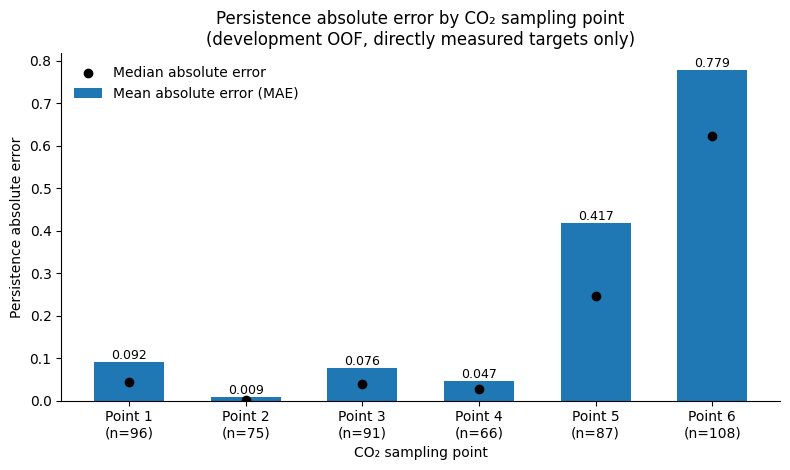

In [162]:
#Creating the directory for Part 2 figures.

os.makedirs("figures", exist_ok=True)


# Summarizing persistence error by sampling point.

point_err = (
    measured_error_anatomy
    .groupby("sampling_point")["absolute_persistence_error"]
    .agg(
        MAE="mean",
        median="median",
        n="size",
    )
    .reset_index()
)


print(
    "Measured-only persistence error by sampling point:"
)

display(
    point_err.round(4)
)

# Plotting mean and median absolute error.

fig, ax = plt.subplots(
    figsize=(8, 4.8)
)

x = np.arange(
    len(point_err)
)

bars = ax.bar(
    x,
    point_err["MAE"],
    width=0.6,
    label="Mean absolute error (MAE)",
)

ax.scatter(
    x,
    point_err["median"],
    color="black",
    zorder=3,
    label="Median absolute error",
)

for xi, mae in zip(
    x,
    point_err["MAE"],
):
    ax.text(
        xi,
        mae,
        f"{mae:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xticks(x)

ax.set_xticklabels(
    [
        f"Point {int(point)}\n(n={int(n)})"
        for point, n in zip(
            point_err["sampling_point"],
            point_err["n"],
        )
    ]
)

ax.set_xlabel(
    "CO₂ sampling point"
)

ax.set_ylabel(
    "Persistence absolute error"
)

ax.set_title(
    "Persistence absolute error by CO₂ sampling point\n"
    "(development OOF, directly measured targets only)"
)

ax.spines[
    ["top", "right"]
].set_visible(False)

ax.legend(
    frameon=False
)


plt.tight_layout()

fig.savefig(
    "figures/fig16a_persistence_error_by_point.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

#### Error relative to CO₂ signal scale

Figure 16A compares errors in the original CO₂ units. However, absolute MAE can be larger at a sampling point simply because the underlying CO₂ concentration or its variability is larger there.

To distinguish absolute error magnitude from relative forecast difficulty, I compare each sampling point's persistence MAE with two characteristics of its directly measured CO₂ observations:

- the absolute mean CO₂ level; and
- the standard deviation of observed CO₂.

The resulting `MAE / |mean|` and `MAE / standard deviation` ratios are used as descriptive scale-normalized diagnostics. They are not additional model-selection metrics; their purpose is to determine whether the large absolute errors at points 5 and 6 remain large after accounting for differences in signal scale.

In [163]:
point_scale_check = (
    measured_error_anatomy
    .groupby("sampling_point")
    .agg(
        mean_level=("observed_co2", "mean"),
        std_level=("observed_co2", "std"),
        MAE=("absolute_persistence_error", "mean"),
        n=("observed_co2", "size"),
    )
)

# Calculating descriptive scale-normalized error measures.

point_scale_check["MAE_over_mean_level"] = (
    point_scale_check["MAE"]
    / point_scale_check["mean_level"].abs()
)

point_scale_check["MAE_over_std_level"] = (
    point_scale_check["MAE"]
    / point_scale_check["std_level"]
)

print(
    "Persistence error relative to observed CO2 scale:"
)

display(
    point_scale_check.round(4)
)

Persistence error relative to observed CO2 scale:


,mean_level,std_level,MAE,n,MAE_over_mean_level,MAE_over_std_level
sampling_point,,,,,,
1,0.1566,0.1665,0.0917,96,0.5855,0.5509
2,0.0037,0.0096,0.0088,75,2.4119,0.9184
3,0.1002,0.0830,0.0757,91,0.7553,0.9126
4,0.1411,0.1362,0.0465,66,0.3298,0.3416
5,1.4710,1.0391,0.4172,87,0.2836,0.4015
6,5.7206,2.3554,0.7788,108,0.1361,0.3306


#### Interpretation

In the original CO₂ units, persistence error is concentrated at sampling points 5 and 6, with directly measured MAE of 0.417 and 0.779, respectively. Their median errors are lower than their means, indicating that larger episodic misses increase the average error.

The ranking changes after accounting for signal scale. When MAE is divided by the observed standard deviation at each point, points 2 and 3 have the largest ratios (0.918 and 0.913), while points 5 and 6 have ratios of 0.402 and 0.331. The large raw errors at points 5 and 6 therefore partly reflect their larger CO₂ scale rather than uniquely poor relative forecastability.

I do not rely on MAE divided by mean CO₂ for the cross-point comparison because point 2 has a mean concentration close to zero, which makes that ratio unstable. I use the standard-deviation-normalized result only as a descriptive diagnostic, not as an additional model-selection metric.

The distinction is important for the remaining root-cause analysis: points 5 and 6 dominate error in the original CO₂ units, while points 2 and 3 can still have substantial error relative to their local variability. Neither result by itself identifies a physical cause of forecast failure.

### Does persistence error depend on the experimental run?

Figure 16A pooled all seven development runs, which can hide whether a sampling point has consistently large relative error or only does so under particular experiments. To examine this structure, each directly measured persistence absolute error is divided by the pooled development OOF standard deviation of observed CO₂ at its sampling point—the same scale used in the scale-normalized diagnostic above—and then averaged within each run and sampling point.

Each heatmap cell reports the resulting mean normalized absolute error together with the number of directly measured OOF observations contributing to that cell. White cells indicate that no directly measured OOF target is available for that run–point combination. In particular, the three 13-observation OOF runs contain no measured target for point 2. Cells based on only two or three observations are retained for completeness but should not be interpreted individually as precise estimates.

This normalization provides a descriptive comparison of error relative to point-specific CO₂ variability. It is not a model skill score or a statistical test of run effects. Because the denominator is calculated by pooling observations across development runs, apparent run differences may also be influenced by between-run differences in CO₂ level or variability; this is checked separately below.

Mean standard-deviation-normalized absolute error:


sampling_point,1,2,3,4,5,6
run,,,,,,
140120_1,0.667,0.387,0.722,0.277,0.825,0.545
140206_1,0.120,NaN,0.100,0.006,0.749,0.455
140207_2,0.399,NaN,0.303,0.068,0.232,0.095
140214_1,0.111,0.000,0.296,0.019,0.143,0.275
140214_2,0.306,NaN,0.316,0.039,0.080,0.689
140227_1,0.456,0.124,0.497,0.105,0.151,0.154
140313_1,0.748,2.017,1.666,0.770,0.503,0.380



Measured OOF observation counts:


sampling_point,1,2,3,4,5,6
run,,,,,,
140120_1,15,12,14,10,14,15
140206_1,3,0,2,2,3,3
140207_2,3,0,2,2,3,3
140214_1,6,3,6,4,5,6
140214_2,3,0,2,2,3,3
140227_1,33,30,33,24,29,33
140313_1,33,30,32,22,30,45


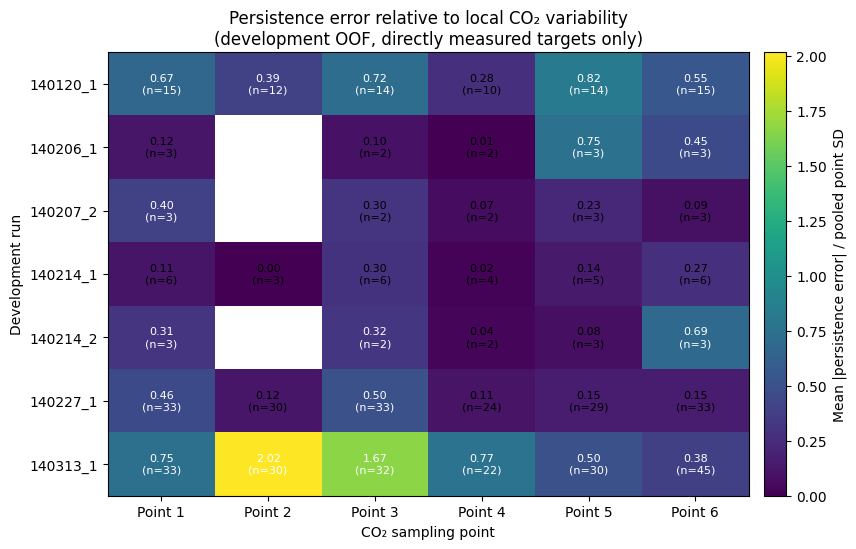

In [164]:
# Computing the pooled development OOF scale for each sampling point.

point_std = (
    measured_error_anatomy
    .groupby("sampling_point")["observed_co2"]
    .std()
)

assert (point_std > 0).all()

# Normalizing persistence error by the corresponding point's CO₂ standard deviation.

run_point_error = measured_error_anatomy.copy()

run_point_error["point_std"] = (
    run_point_error["sampling_point"]
    .map(point_std)
)

run_point_error[
    "std_normalized_absolute_error"
] = (
    run_point_error[
        "absolute_persistence_error"
    ]
    / run_point_error[
        "point_std"
    ]
)

# Summarizing normalized error by run and sampling point.

run_point_mean = (
    run_point_error
    .pivot_table(
        index="run",
        columns="sampling_point",
        values="std_normalized_absolute_error",
        aggfunc="mean",
    )
    .sort_index()
)


run_point_counts = (
    run_point_error
    .pivot_table(
        index="run",
        columns="sampling_point",
        values="std_normalized_absolute_error",
        aggfunc="size",
        fill_value=0,
    )
    .reindex(
        index=run_point_mean.index,
        columns=run_point_mean.columns,
    )
)


print(
    "Mean standard-deviation-normalized absolute error:"
)

display(
    run_point_mean.round(3)
)


print(
    "\nMeasured OOF observation counts:"
)

display(
    run_point_counts.astype(int)
)

# Plotting the run-by-point heatmap.

fig, ax = plt.subplots(
    figsize=(9, 5.6)
)

heatmap_values = run_point_mean.to_numpy(
    dtype=float
)

image = ax.imshow(
    heatmap_values,
    aspect="auto",
)

ax.set_xticks(
    np.arange(
        len(run_point_mean.columns)
    )
)

ax.set_xticklabels(
    [
        f"Point {int(point)}"
        for point in run_point_mean.columns
    ]
)

ax.set_yticks(
    np.arange(
        len(run_point_mean.index)
    )
)

ax.set_yticklabels(
    run_point_mean.index
)

ax.set_xlabel(
    "CO₂ sampling point"
)

ax.set_ylabel(
    "Development run"
)

ax.set_title(
    "Persistence error relative to local CO₂ variability\n"
    "(development OOF, directly measured targets only)"
)

finite_values = heatmap_values[
    np.isfinite(heatmap_values)
]

threshold = (
    np.nanmedian(finite_values)
    if len(finite_values) > 0
    else 0
)

for i, run_name in enumerate(
    run_point_mean.index
):
    for j, point in enumerate(
        run_point_mean.columns
    ):

        value = run_point_mean.loc[
            run_name,
            point,
        ]

        count = run_point_counts.loc[
            run_name,
            point,
        ]

        if np.isfinite(value):

            text_color = (
                "white"
                if value > threshold
                else "black"
            )

            ax.text(
                j,
                i,
                f"{value:.2f}\n(n={int(count)})",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
            )


colorbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.02,
)

colorbar.set_label(
    "Mean |persistence error| / pooled point SD"
)

plt.tight_layout()

fig.savefig(
    "figures/fig16b_run_point_normalized_error.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

#### Check for between-run differences in CO₂ scale

The heatmap uses one pooled CO₂ standard deviation for each sampling point. This makes the normalization consistent with Figure 16A, but it may exaggerate apparent run differences if individual experiments operate at substantially different CO₂ levels or have very different within-run variability.

I therefore inspect the observed CO₂ mean and standard deviation separately for the three development runs with the largest numbers of measured OOF observations. This diagnostic is used only to interpret the heatmap and does not redefine the forecasting metric.

In [165]:
# Summarizing error relative to each run × point's own signal scale.

run_pt = (
    measured_error_anatomy
    .groupby(
        ["run", "sampling_point"]
    )
    .agg(
        mean_level=(
            "observed_co2",
            "mean",
        ),
        sd_level=(
            "observed_co2",
            "std",
        ),
        persistence_MAE=(
            "absolute_persistence_error",
            "mean",
        ),
        n=(
            "observed_co2",
            "size",
        ),
    )
)

run_pt["MAE_over_own_mean"] = (
    run_pt["persistence_MAE"]
    / run_pt["mean_level"].abs()
)

run_pt["MAE_over_own_SD"] = (
    run_pt["persistence_MAE"]
    / run_pt["sd_level"]
)



def mean_reference_mae(group):
    y = group["observed_co2"].to_numpy(
        dtype=float
    )

    y_mean = np.mean(y)

    return np.mean(
        np.abs(
            y - y_mean
        )
    )


mean_reference = (
    measured_error_anatomy
    .groupby(
        ["run", "sampling_point"]
    )
    .apply(
        mean_reference_mae
    )
    .rename(
        "retrospective_mean_MAE"
    )
)


run_pt = run_pt.join(
    mean_reference
)

run_pt[
    "persistence_over_retrospective_mean_MAE"
] = (
    run_pt["persistence_MAE"]
    / run_pt["retrospective_mean_MAE"]
)

# Restricting the comparison to cells with at least 10 observations.
big = (
    run_pt[
        run_pt["n"] >= 10
    ]
    .copy()
)


print(
    "Run × point cells with n >= 10:",
    len(big),
)



print(
    "\nPersistence MAE / within-run point SD:"
)

display(
    big[
        "MAE_over_own_SD"
    ]
    .unstack(
        "sampling_point"
    )
    .round(2)
)


print(
    "\nPersistence MAE / retrospective run-point mean MAE:"
)

display(
    big[
        "persistence_over_retrospective_mean_MAE"
    ]
    .unstack(
        "sampling_point"
    )
    .round(2)
)

Run × point cells with n >= 10: 18

Persistence MAE / within-run point SD:


/var/folders/tc/krjl03bn2cgbs5z5128vc9y80000gn/T/ipykernel_11228/990677772.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  measured_error_anatomy


sampling_point,1,2,3,4,5,6
run,,,,,,
140120_1,0.61,1.37,1.30,1.10,1.04,1.24
140227_1,0.49,0.96,1.14,0.71,1.52,0.90
140313_1,0.73,1.39,1.52,1.15,0.68,0.76



Persistence MAE / retrospective run-point mean MAE:


sampling_point,1,2,3,4,5,6
run,,,,,,
140120_1,0.71,2.38,1.56,1.45,1.41,1.67
140227_1,0.58,1.86,1.39,0.90,2.01,1.16
140313_1,0.82,2.21,1.84,1.41,0.84,1.02


#### Interpretation

The pooled-SD heatmap shows clear run-by-location heterogeneity, but no sampling point is uniformly difficult across experiments. For example, `140120_1` has its largest normalized error at point 5, whereas `140313_1` is relatively difficult at points 2 and 3. Several cells from the short runs contain only two or three observations, so I do not interpret those cells individually.

Part of the pooled contrast reflects differences in CO₂ scale between experiments. Restricting the comparison to the 18 run–point cells with at least 10 directly measured observations, persistence MAE divided by each cell's own standard deviation ranges from about 0.49 to 1.52. The remaining differences therefore support run-by-location heterogeneity, but not a simple conclusion that one run or sampling point is universally harder to forecast.

The retrospective run-point mean provides an additional diagnostic. Persistence has higher MAE than this reference in 13 of the 18 supported cells. However, the reference uses observations from the complete held-out run and therefore contains future information; it is an oracle diagnostic, not a deployable baseline. It only shows that persistence is not automatically optimal because each run-point series is nearly constant.

Overall, the evidence supports heterogeneous behavior across experimental runs and sampling locations. Run identity also bundles changes in operating conditions and signal scale, so this analysis does not establish an isolated causal run effect.

### What does a persistence failure look like in time?

Aggregate error metrics show where persistence performs poorly, but they do not show what an individual failure looks like in the time series. I therefore examine one development episode from the trained outer fold with the largest number of directly measured OOF observations, centered on that run's largest persistence error.

The episode is selected using a fixed error-based rule rather than by visual inspection. It is intentionally a difficult case and is used only to illustrate model behavior around a large CO₂ excursion, not as a representative example of overall performance.

Non-zero-epoch fold counts:


,measured_OOF_observations
run,
140120_1,80
140207_2,13
140214_2,13



Selected run: 140120_1
Selected epoch: 1
Selected sampling point: 5
Selection rule: largest measured-OOF trained fold, then point containing its largest persistence error.

Largest persistence-error observation:
Target row: 44
Observed CO2: 3.1641
Persistence prediction: 0.5412
Transformer prediction: 0.5344
Persistence absolute error: 2.6229
Transformer absolute error: 2.6297


,target_row,analyzer_age_at_origin,observed_co2,persistence_prediction,model_prediction,absolute_persistence_error,model_absolute_error,correction
4,27,9.0,1.0789,0.7869,0.7830,0.2920,0.2959,-0.0038
5,28,10.0,0.6047,0.7869,0.7830,0.1822,0.1783,-0.0039
6,29,11.0,0.5412,0.7869,0.7830,0.2456,0.2418,-0.0039
21,44,9.0,3.1641,0.5412,0.5344,2.6229,2.6297,-0.0069
22,45,10.0,2.5941,0.5412,0.5349,2.0528,2.0592,-0.0064
23,46,11.0,2.4044,0.5412,0.5352,1.8632,1.8693,-0.0061
38,61,9.0,1.3512,2.4044,2.3939,1.0532,1.0427,-0.0105
39,62,10.0,1.1184,2.4044,2.3926,1.2861,1.2742,-0.0119
54,77,9.0,0.2625,1.1184,1.1041,0.8558,0.8416,-0.0143
55,78,10.0,1.0791,1.1184,1.1034,0.0393,0.0243,-0.0150



Maximum |Transformer correction| in selected series: 0.0165


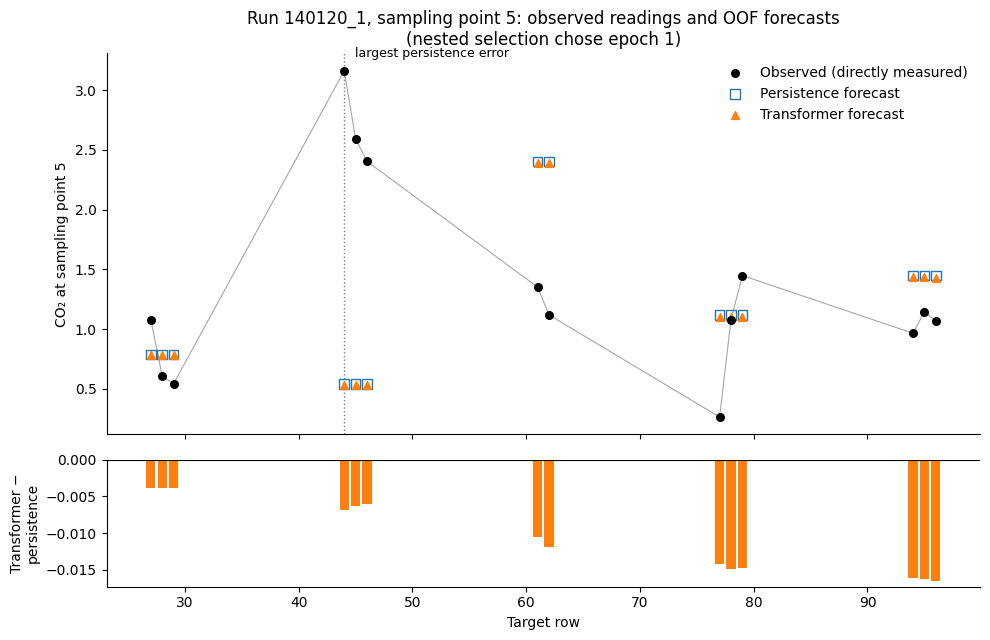

In [166]:
trained_oof = (
    measured_error_anatomy[
        measured_error_anatomy["selected_epoch"] > 0
    ]
    .copy()
)

assert len(trained_oof) > 0

# Selecting the trained fold with the largest measured OOF sample.
trained_run_counts = (
    trained_oof
    .groupby("run")
    .size()
    .sort_values(ascending=False)
)

RUN = trained_run_counts.index[0]

run_df = (
    trained_oof[
        trained_oof["run"] == RUN
    ]
    .copy()
)

selected_epochs = (
    run_df["selected_epoch"]
    .unique()
)

assert len(selected_epochs) == 1

SELECTED_EPOCH = int(
    selected_epochs[0]
)


# Selecting the point containing the largest persistence error in that run.

worst_idx = (
    run_df[
        "absolute_persistence_error"
    ]
    .idxmax()
)

worst = run_df.loc[
    worst_idx
]

POINT = int(
    worst["sampling_point"]
)

# Extracting the directly measured OOF series for the selected run and point.

series = (
    run_df[
        run_df["sampling_point"] == POINT
    ]
    .sort_values("target_row")
    .copy()
)

series["correction"] = (
    series["model_prediction"]
    - series["persistence_prediction"]
)

series["model_absolute_error"] = (
    np.abs(
        series["model_prediction"]
        - series["observed_co2"]
    )
)


print(
    "Non-zero-epoch fold counts:"
)

display(
    trained_run_counts
    .rename(
        "measured_OOF_observations"
    )
    .to_frame()
)


print(
    f"\nSelected run: {RUN}"
)

print(
    f"Selected epoch: {SELECTED_EPOCH}"
)

print(
    f"Selected sampling point: {POINT}"
)

print(
    "Selection rule: largest measured-OOF trained fold, "
    "then point containing its largest persistence error."
)


print(
    "\nLargest persistence-error observation:"
)

print(
    f"Target row: {int(worst['target_row'])}"
)

print(
    f"Observed CO2: "
    f"{worst['observed_co2']:.4f}"
)

print(
    f"Persistence prediction: "
    f"{worst['persistence_prediction']:.4f}"
)

print(
    f"Transformer prediction: "
    f"{worst['model_prediction']:.4f}"
)

print(
    f"Persistence absolute error: "
    f"{worst['absolute_persistence_error']:.4f}"
)

print(
    f"Transformer absolute error: "
    f"{abs(worst['model_prediction'] - worst['observed_co2']):.4f}"
)


display(
    series[
        [
            "target_row",
            "analyzer_age_at_origin",
            "observed_co2",
            "persistence_prediction",
            "model_prediction",
            "absolute_persistence_error",
            "model_absolute_error",
            "correction",
        ]
    ]
    .round(4)
)


print(
    "\nMaximum |Transformer correction| "
    "in selected series:",
    round(
        series["correction"]
        .abs()
        .max(),
        4,
    ),
)

# Plotting observed CO₂ and the two OOF forecasts through the selected episode.

x = (
    series["target_row"]
    .to_numpy()
)

fig, (
    ax1,
    ax2,
) = plt.subplots(
    2,
    1,
    figsize=(10, 6.5),
    sharex=True,
    gridspec_kw={
        "height_ratios": [
            3,
            1,
        ]
    },
)


# Plotting the directly measured CO₂ observations.
ax1.plot(
    x,
    series["observed_co2"],
    color="black",
    linewidth=0.8,
    alpha=0.35,
    zorder=1,
)

ax1.scatter(
    x,
    series["observed_co2"],
    color="black",
    s=30,
    label="Observed (directly measured)",
    zorder=4,
)


# Adding the persistence forecasts.
ax1.scatter(
    x,
    series["persistence_prediction"],
    marker="s",
    facecolors="none",
    edgecolors="tab:blue",
    s=48,
    label="Persistence forecast",
    zorder=2,
)


# Adding the Transformer forecasts.
ax1.scatter(
    x,
    series["model_prediction"],
    marker="^",
    color="tab:orange",
    s=32,
    label="Transformer forecast",
    zorder=3,
)


# Marking the largest persistence error in the selected series.
ax1.axvline(
    worst["target_row"],
    color="grey",
    linestyle=":",
    linewidth=1,
)

ax1.annotate(
    "largest persistence error",
    xy=(
        worst["target_row"],
        worst["observed_co2"],
    ),
    xytext=(8, 10),
    textcoords="offset points",
    fontsize=9,
)


ax1.set_ylabel(
    f"CO₂ at sampling point {POINT}"
)

ax1.set_title(
    f"Run {RUN}, sampling point {POINT}: "
    "observed readings and OOF forecasts\n"
    f"(nested selection chose epoch {SELECTED_EPOCH})"
)

ax1.legend(
    frameon=False
)

ax1.spines[
    ["top", "right"]
].set_visible(
    False
)


# Plotting the Transformer correction relative to persistence.

ax2.bar(
    x,
    series["correction"],
    color="tab:orange",
    width=0.8,
)

ax2.axhline(
    0,
    color="black",
    linewidth=0.8,
)

ax2.set_ylabel(
    "Transformer −\npersistence"
)

ax2.set_xlabel(
    "Target row"
)

ax2.spines[
    ["top", "right"]
].set_visible(
    False
)


plt.tight_layout()

fig.savefig(
    "figures/fig16c_temporal_failure_episode.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

#### Interpretation

The selected series shows a clear persistence failure around a rapid CO₂ excursion. At row 44, the observed concentration rises to 3.164 while persistence remains at 0.541, producing an absolute error of 2.623. The observed values remain elevated over the next two measurements, and the last value from that visit is then carried forward. When CO₂ falls at the following visit, persistence consequently overshoots the new observations. In this example, the same excursion therefore produces large errors as the signal rises and again as it declines.

The trained Transformer does not materially correct this behavior. Its maximum absolute correction across the 14 displayed observations is only 0.0165. At the largest persistence failure, it changes the forecast from 0.541 to 0.534, slightly increasing the absolute error from 2.623 to 2.630. The learned residual correction is therefore small relative to the magnitude of the excursion.

This episode is consistent with the broader development results: the Transformer can make small adjustments around persistence, but those corrections do not capture the large CO₂ changes responsible for the most severe forecast errors. Because this series was selected from the trained fold with the largest measured OOF sample and then centered on that run's largest persistence error, it is a qualitative failure diagnostic rather than an estimate of overall model performance.

The figure does not establish the physical cause of the excursion. The available data cannot determine from this example alone whether it reflects process dynamics, analyzer behavior, measurement effects, or another unobserved mechanism.

### How does target construction affect evaluation?

The analyzer measures the six CO₂ sampling points sequentially, so only one target component is directly observed at a given row while the remaining sampling-point values are obtained from the interpolated CO₂ profiles used for modeling.

This matters for evaluation because full-profile metrics contain many more interpolated than directly measured targets. I therefore compare persistence error between the two target types and report measured-only metrics separately throughout the forecasting analysis.

This diagnostic describes how target construction affects evaluation difficulty. It does not test whether interpolation caused the Transformer's limited improvement over persistence.

Directly measured: 523 of 3138 (16.7%)


,MAE,median,n
target_type,,,
Directly measured,0.2674,0.0673,523
Interpolated,0.1678,0.0385,2615


target_type,Directly measured,Interpolated,interpolated / direct
sampling_point,,,
1,0.0917,0.0695,0.7574
2,0.0088,0.0060,0.6815
3,0.0757,0.0581,0.7673
4,0.0465,0.0361,0.7751
5,0.4172,0.3107,0.7449
6,0.7788,0.5530,0.7101


,interpolated_targets
measurement_span,
14,375
15,1479
16,417
17,138
18,170
19,36


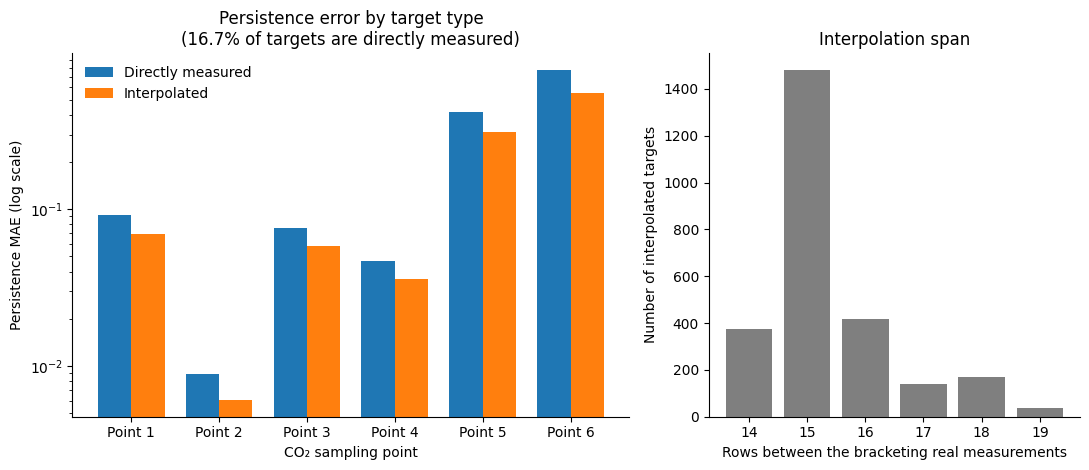

In [167]:
assert "interpolation_analysis" in globals(), "Re-run the 15T cell first."

ia = interpolation_analysis.copy()
ia["target_type"] = np.where(ia["directly_measured_target"], "Directly measured", "Interpolated")

share_direct = ia["directly_measured_target"].mean()
print(f"Directly measured: {ia['directly_measured_target'].sum()} of {len(ia)} ({share_direct:.1%})")

overall = ia.groupby("target_type")["absolute_persistence_error"].agg(
    MAE="mean", median="median", n="size")
display(overall.round(4))

tab = ia.pivot_table(index="sampling_point", columns="target_type",
                     values="absolute_persistence_error", aggfunc="mean")
tab["interpolated / direct"] = tab["Interpolated"] / tab["Directly measured"]
display(tab.round(4))

spans = (ia.loc[~ia["directly_measured_target"], "measurement_span"]
         .value_counts().sort_index())
display(spans.rename("interpolated_targets").to_frame())

# Comparing persistence error by target type and interpolation span.

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.8),
                               gridspec_kw={"width_ratios": [3, 2]})
pts = tab.index.to_numpy()
x = np.arange(len(pts))
w = 0.38
axL.bar(x - w/2, tab["Directly measured"], w, label="Directly measured", color="tab:blue")
axL.bar(x + w/2, tab["Interpolated"], w, label="Interpolated", color="tab:orange")
axL.set_yscale("log")
axL.set_xticks(x)
axL.set_xticklabels([f"Point {int(p)}" for p in pts])
axL.set_xlabel("CO₂ sampling point")
axL.set_ylabel("Persistence MAE (log scale)")
axL.set_title(f"Persistence error by target type\n({share_direct:.1%} of targets are directly measured)")
axL.legend(frameon=False)
axL.spines[["top", "right"]].set_visible(False)

axR.bar(spans.index.astype(int).astype(str), spans.values, color="tab:gray")
axR.set_xlabel("Rows between the bracketing real measurements")
axR.set_ylabel("Number of interpolated targets")
axR.set_title("Interpolation span")
axR.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig("figures/fig16d_direct_vs_interpolated.png", dpi=200, bbox_inches="tight")
plt.show()

#### Interpretation

Only 523 of the 3,138 development OOF target components (16.7%) are directly measured; the remaining 2,615 (83.3%) are interpolated. Persistence performs better on the interpolated targets, with MAE decreasing from 0.2674 on directly measured values to 0.1678 on interpolated values. The same pattern appears at every sampling point, where interpolated-target MAE is approximately 68–78% of the corresponding directly measured MAE.

The interpolated values are usually constructed between real analyzer measurements separated by 14–19 rows, with a 15-row span occurring most often. Because these interpolated targets dominate the full-profile evaluation and are empirically easier for persistence, full-profile metrics can give a more favorable view of forecast accuracy than evaluation restricted to real analyzer measurements.

This is why I report directly measured performance alongside the full-profile metrics. The result does not show that interpolation caused the Transformer's limited improvement; it shows that target construction materially affects the difficulty and interpretation of the evaluation.

### Does persistence error increase with analyzer age?

Persistence uses the most recently available real analyzer reading for each sampling point. A natural candidate explanation for forecast error is therefore **analyzer staleness**: if the last available measurement is older at the forecast origin, persistence might become less informative about the future directly measured target.

This diagnostic uses the 523 directly measured development OOF targets. Absolute persistence error is normalized by the mean directly measured persistence error of the corresponding sampling point, so a value of 1 represents that point's average measured-target error. This normalization reduces the influence of the large differences in absolute CO₂ error scale among sampling locations.

The left panel summarizes normalized error by analyzer age using the pooled mean and standard error, with the number of observations shown for each age. The right panel shows the corresponding mean normalized error separately for each development run.

Analyzer age should not be interpreted as an independent causal variable. It is coupled to the analyzer sampling schedule and position within a sampling stretch, consecutive observations are correlated, and the oldest observed ages are not represented across all runs. In particular, ages 13–14 occur only in `140313_1`, so behavior at those ages cannot be separated from characteristics specific to that run.

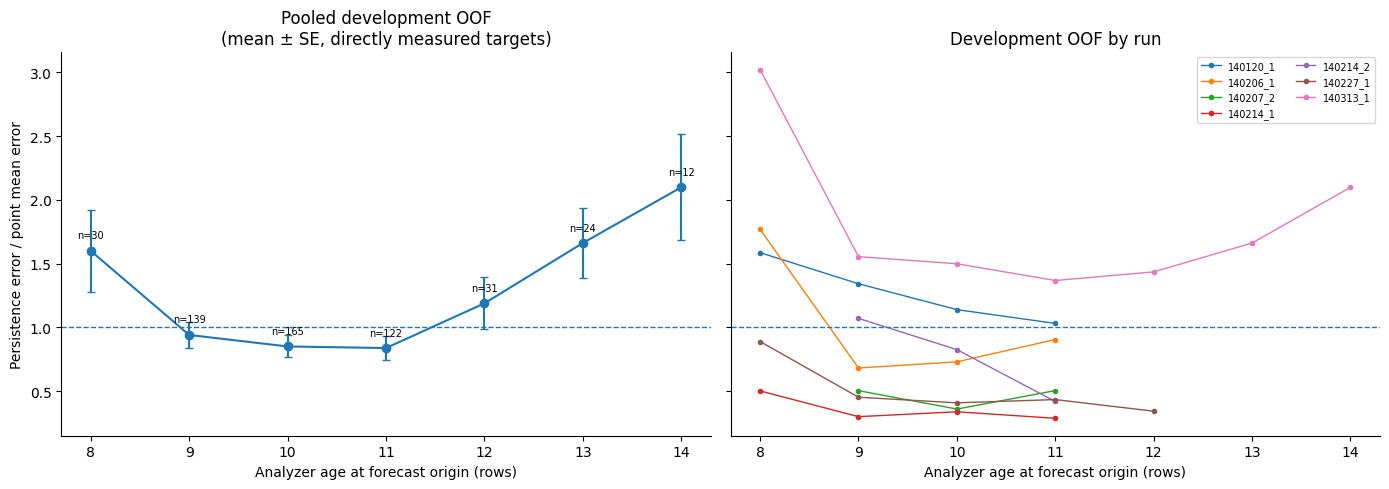

Pooled normalized persistence error by analyzer age:


,analyzer_age_at_origin,mean,sd,n,se
0,8.0,1.599,1.756,30,0.321
1,9.0,0.940,1.190,139,0.101
2,10.0,0.850,1.112,165,0.087
3,11.0,0.838,1.038,122,0.094
4,12.0,1.188,1.139,31,0.204
5,13.0,1.661,1.337,24,0.273
6,14.0,2.098,1.443,12,0.417



Pooled Spearman rho = 0.060 (p = 0.174; descriptive only, observations are correlated)
Excluding ages > 12: rho = -0.033 (p = 0.467, n = 487; descriptive only)

Run support by analyzer age:


,n_runs,runs
analyzer_age_at_origin,,
8.0,5,"140120_1, 140206_1, 140214_1, 140227_1, 140313_1"
9.0,7,"140120_1, 140206_1, 140207_2, 140214_1, 140214_2, 140227_1, 140313_1"
10.0,7,"140120_1, 140206_1, 140207_2, 140214_1, 140214_2, 140227_1, 140313_1"
11.0,7,"140120_1, 140206_1, 140207_2, 140214_1, 140214_2, 140227_1, 140313_1"
12.0,2,"140227_1, 140313_1"
13.0,1,140313_1
14.0,1,140313_1


In [168]:
from scipy.stats import spearmanr

m = measured_error_anatomy.copy()


# Normalizing error by each sampling point's mean measured-target persistence error.

point_mean = (
    m
    .groupby(
        "sampling_point"
    )[
        "absolute_persistence_error"
    ]
    .transform(
        "mean"
    )
)

assert (
    point_mean > 0
).all()

m[
    "norm_error"
] = (
    m[
        "absolute_persistence_error"
    ]
    / point_mean
)

# Summarizing normalized persistence error by analyzer age.

by_age = (
    m
    .groupby(
        "analyzer_age_at_origin"
    )[
        "norm_error"
    ]
    .agg(
        mean="mean",
        sd="std",
        n="size",
    )
    .reset_index()
)

by_age[
    "se"
] = (
    by_age["sd"]
    / np.sqrt(
        by_age["n"]
    )
)

# Summarizing the same relationship within each development run.

by_run_age = (
    m
    .groupby(
        [
            "run",
            "analyzer_age_at_origin",
        ]
    )[
        "norm_error"
    ]
    .agg(
        mean="mean",
        n="size",
    )
    .reset_index()
)


# Plotting the pooled and run-specific analyzer-age relationships.

fig, (
    ax1,
    ax2,
) = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharey=True,
)


# Plotting the pooled relationship.
ax1.errorbar(
    by_age[
        "analyzer_age_at_origin"
    ],
    by_age[
        "mean"
    ],
    yerr=by_age[
        "se"
    ],
    fmt="o-",
    capsize=3,
)

ax1.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)


for _, row in by_age.iterrows():

    ax1.annotate(
        f"n={int(row['n'])}",
        (
            row[
                "analyzer_age_at_origin"
            ],
            row[
                "mean"
            ],
        ),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=7,
    )


ax1.set_xlabel(
    "Analyzer age at forecast origin (rows)"
)

ax1.set_ylabel(
    "Persistence error / point mean error"
)

ax1.set_title(
    "Pooled development OOF\n"
    "(mean ± SE, directly measured targets)"
)


# Plotting the run-specific relationships.

for run, group in by_run_age.groupby(
    "run"
):

    ax2.plot(
        group[
            "analyzer_age_at_origin"
        ],
        group[
            "mean"
        ],
        "o-",
        markersize=3,
        linewidth=1,
        label=run,
    )


ax2.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax2.set_xlabel(
    "Analyzer age at forecast origin (rows)"
)

ax2.set_title(
    "Development OOF by run"
)

ax2.legend(
    fontsize=7,
    ncol=2,
)


ax1.spines[
    ["top", "right"]
].set_visible(
    False
)

ax2.spines[
    ["top", "right"]
].set_visible(
    False
)


plt.tight_layout()

fig.savefig(
    "figures/fig16e_error_vs_analyzer_age.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


print(
    "Pooled normalized persistence error by analyzer age:"
)

display(
    by_age.round(3)
)


# Checking the pooled monotonic association descriptively.

rho, p = spearmanr(
    m[
        "analyzer_age_at_origin"
    ],
    m[
        "norm_error"
    ],
)

print(
    f"\nPooled Spearman rho = {rho:.3f} "
    f"(p = {p:.3g}; descriptive only, "
    "observations are correlated)"
)


# Repeating the correlation without ages 13–14, which occur only in 140313_1.

sub = (
    m[
        m[
            "analyzer_age_at_origin"
        ] <= 12
    ]
    .copy()
)

rho2, p2 = spearmanr(
    sub[
        "analyzer_age_at_origin"
    ],
    sub[
        "norm_error"
    ],
)

print(
    f"Excluding ages > 12: "
    f"rho = {rho2:.3f} "
    f"(p = {p2:.3g}, n = {len(sub)}; "
    "descriptive only)"
)


# Checking cross-run support at each analyzer age.

age_run_support = (
    m
    .groupby(
        "analyzer_age_at_origin"
    )[
        "run"
    ]
    .agg(
        n_runs="nunique",
        runs=lambda values: ", ".join(
            sorted(
                values.unique()
            )
        ),
    )
)

print(
    "\nRun support by analyzer age:"
)

display(
    age_run_support
)

#### Interpretation

Analyzer age does not show a consistent monotonic relationship with persistence error. The pooled Spearman correlation is only 0.060, and after excluding ages 13–14 it becomes -0.033. Both are treated descriptively because consecutive observations are correlated and analyzer age is structured by the sampling schedule.

The strongest cross-run support occurs at ages 9–11, which contain 426 of the 523 directly measured observations and are represented in all seven development runs. Mean normalized error decreases from approximately 0.94 at age 9 to 0.85 at age 10 and 0.84 at age 11, rather than increasing as the previous measurement becomes older.

The higher errors at ages 13–14 do not provide strong evidence of a staleness effect because both ages occur only in `140313_1`. Age 12 is also represented in only two runs. The oldest-age increase is therefore confounded with run-specific behavior and the analyzer sampling schedule.

Overall, the development data do not support analyzer staleness as a general explanation for persistence failure. They also cannot rule out an effect at the oldest ages because those ages have limited cross-run support. Analyzer age is therefore treated as a structured measurement-context variable rather than an independently identified root cause.

### How concentrated is persistence error?

Large individual misses can have a disproportionate influence on RMSE because errors are squared before aggregation. I therefore examine whether persistence error is broadly distributed across the directly measured development OOF targets or concentrated in a relatively small number of observations.

The left panel sorts the 523 directly measured targets from largest to smallest squared persistence error and plots the cumulative fraction of total squared error explained as progressively more observations are included. The same calculation is shown for point-normalized error, where each absolute error is first divided by the mean directly measured persistence error of its sampling point. This separates concentration caused partly by differences in CO₂ error scale among sampling locations from concentration that remains after point-level normalization.

The right panel compares each development run's share of all directly measured observations with its share among the 53 observations having the largest raw squared errors (the ceiling of 10% of 523 observations). Additional tables report the composition of these large-error observations by run and sampling point.

Squared error deliberately emphasizes large misses, so concentration is expected to be stronger than for absolute error. Consecutive observations can also belong to the same analyzer episode and are therefore not independent. The analysis is descriptive and is intended to characterize how aggregate error is distributed, not to assign a causal explanation to individual runs or sampling points.

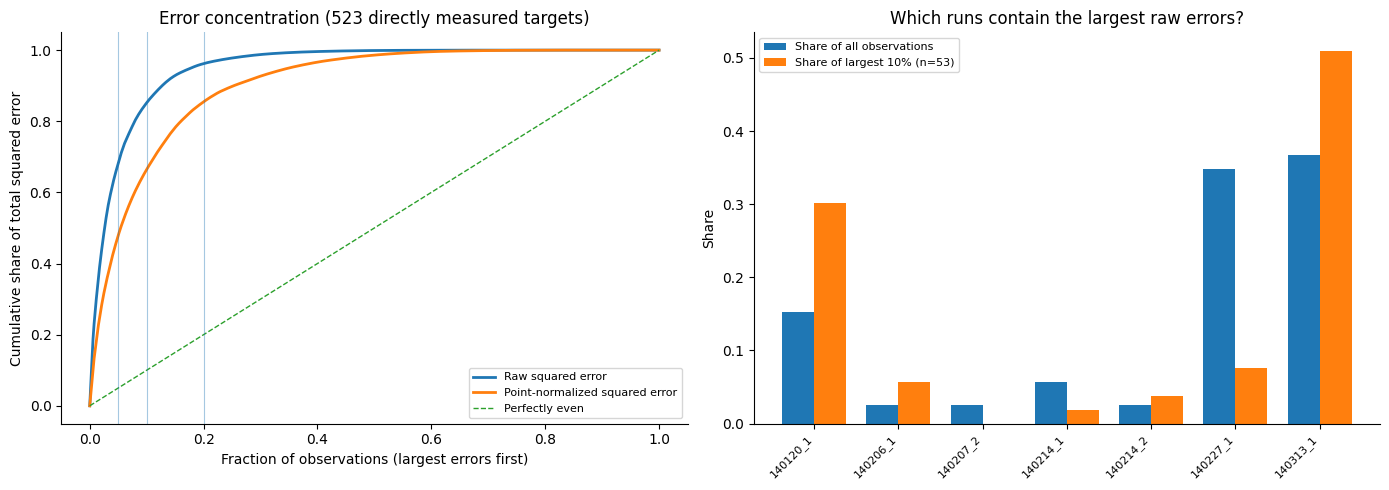

Share of total error carried by the largest observations:


,top 5% share,top 10% share,top 20% share,n for 50%,% observations for 50%,n for 80%,% observations for 80%
measure,,,,,,,
Raw squared error,0.691,0.855,0.962,14,2.677,42,8.031
Point-normalized squared error,0.487,0.668,0.855,29,5.545,84,16.061
Raw absolute error,0.376,0.560,0.769,44,8.413,119,22.753



Top group contains 53 of 523 observations (10.13% of measured OOF targets).

Largest-error observations by run:


,n_top,share_top,share_all,top_share / all_share
run,,,,
140120_1,16,0.302,0.153,1.974
140206_1,3,0.057,0.025,2.277
140207_2,0,0.000,0.025,0.000
140214_1,1,0.019,0.057,0.329
140214_2,2,0.038,0.025,1.518
140227_1,4,0.075,0.348,0.217
140313_1,27,0.509,0.367,1.388


In [169]:
m = measured_error_anatomy.copy()

n = len(m)

assert n == 523

# Computing raw and point-normalized persistence errors.

m["sq_err"] = (
    m["absolute_persistence_error"] ** 2
)

point_mean = (
    m
    .groupby("sampling_point")[
        "absolute_persistence_error"
    ]
    .transform("mean")
)

assert (
    point_mean > 0
).all()

m["norm_abs"] = (
    m["absolute_persistence_error"]
    / point_mean
)

m["norm_sq"] = (
    m["norm_abs"] ** 2
)


# Helper functions for summarizing error concentration.

def concentration_curve(values):

    v = np.sort(
        np.asarray(
            values,
            dtype=float,
        )
    )[::-1]

    cumulative = (
        np.cumsum(v)
        / v.sum()
    )

    fraction = (
        np.arange(
            1,
            len(v) + 1,
        )
        / len(v)
    )

    return (
        np.r_[0.0, fraction],
        np.r_[0.0, cumulative],
    )


def share_in_top(values, fraction):

    v = np.sort(
        np.asarray(
            values,
            dtype=float,
        )
    )[::-1]

    k = int(
        np.ceil(
            fraction * len(v)
        )
    )

    return (
        v[:k].sum()
        / v.sum()
    )


def observations_for_share(values, target_share):

    v = np.sort(
        np.asarray(
            values,
            dtype=float,
        )
    )[::-1]

    cumulative = (
        np.cumsum(v)
        / v.sum()
    )

    k = (
        np.searchsorted(
            cumulative,
            target_share,
        )
        + 1
    )

    return {
        "n_observations": int(k),
        "fraction_observations": (
            k / len(v)
        ),
    }


# Summarizing how much total error is carried by the largest observations.

rows = []

for label, col in [
    (
        "Raw squared error",
        "sq_err",
    ),
    (
        "Point-normalized squared error",
        "norm_sq",
    ),
    (
        "Raw absolute error",
        "absolute_persistence_error",
    ),
]:

    half = observations_for_share(
        m[col],
        0.50,
    )

    eighty = observations_for_share(
        m[col],
        0.80,
    )

    rows.append(
        {
            "measure": label,
            "top 5% share": share_in_top(
                m[col],
                0.05,
            ),
            "top 10% share": share_in_top(
                m[col],
                0.10,
            ),
            "top 20% share": share_in_top(
                m[col],
                0.20,
            ),
            "n for 50%": half[
                "n_observations"
            ],
            "% observations for 50%": (
                100
                * half[
                    "fraction_observations"
                ]
            ),
            "n for 80%": eighty[
                "n_observations"
            ],
            "% observations for 80%": (
                100
                * eighty[
                    "fraction_observations"
                ]
            ),
        }
    )


concentration_table = (
    pd.DataFrame(rows)
    .set_index("measure")
)

# Identifying the largest 10% of raw squared-error observations.

k = int(
    np.ceil(
        0.10 * n
    )
)

top = (
    m
    .sort_values(
        "sq_err",
        ascending=False,
    )
    .head(k)
    .copy()
)


run_share_all = (
    m["run"]
    .value_counts(
        normalize=True
    )
    .sort_index()
)

run_share_top = (
    top["run"]
    .value_counts(
        normalize=True
    )
    .reindex(
        run_share_all.index
    )
    .fillna(0)
)


# Plotting error concentration and the run composition of the largest errors.

fig, (
    ax1,
    ax2,
) = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)


# Plotting raw and point-normalized squared-error concentration.

x_raw, y_raw = concentration_curve(
    m["sq_err"]
)

ax1.plot(
    x_raw,
    y_raw,
    linewidth=2,
    label="Raw squared error",
)


x_norm, y_norm = concentration_curve(
    m["norm_sq"]
)

ax1.plot(
    x_norm,
    y_norm,
    linewidth=2,
    label="Point-normalized squared error",
)


ax1.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfectly even",
)


for fraction in (
    0.05,
    0.10,
    0.20,
):

    ax1.axvline(
        fraction,
        linewidth=0.8,
        alpha=0.4,
    )


ax1.set_xlabel(
    "Fraction of observations (largest errors first)"
)

ax1.set_ylabel(
    "Cumulative share of total squared error"
)

ax1.set_title(
    "Error concentration "
    "(523 directly measured targets)"
)

ax1.legend(
    fontsize=8,
    loc="lower right",
)


# Comparing each run's overall share with its share of the largest errors.

positions = np.arange(
    len(
        run_share_all
    )
)

width = 0.38


ax2.bar(
    positions - width / 2,
    run_share_all.values,
    width,
    label="Share of all observations",
)

ax2.bar(
    positions + width / 2,
    run_share_top.values,
    width,
    label=(
        f"Share of largest 10% "
        f"(n={k})"
    ),
)


ax2.set_xticks(
    positions
)

ax2.set_xticklabels(
    run_share_all.index,
    rotation=45,
    ha="right",
    fontsize=8,
)

ax2.set_ylabel(
    "Share"
)

ax2.set_title(
    "Which runs contain the largest raw errors?"
)

ax2.legend(
    fontsize=8,
)


for ax in (
    ax1,
    ax2,
):

    ax.spines[
        ["top", "right"]
    ].set_visible(
        False
    )


plt.tight_layout()

fig.savefig(
    "figures/fig16f_error_concentration.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


print(
    "Share of total error carried by "
    "the largest observations:"
)

display(
    concentration_table.round(3)
)


print(
    f"\nTop group contains {k} of {n} observations "
    f"({100 * k / n:.2f}% of measured OOF targets)."
)


print(
    "\nLargest-error observations by run:"
)

run_table = pd.DataFrame(
    {
        "n_top": (
            top["run"]
            .value_counts()
            .reindex(
                run_share_all.index
            )
            .fillna(0)
            .astype(int)
        ),
        "share_top": (
            run_share_top
        ),
        "share_all": (
            run_share_all
        ),
    }
)

run_table[
    "top_share / all_share"
] = (
    run_table[
        "share_top"
    ]
    / run_table[
        "share_all"
    ]
)

display(
    run_table.round(3)
)

#### Interpretation

Persistence error is highly concentrated in a small fraction of the directly measured development targets. The largest 5% of observations account for 69.1% of total raw squared error, the largest 10% account for 85.5%, and only 14 of the 523 observations (2.7%) are needed to accumulate half of total squared error. RMSE is therefore strongly influenced by a relatively small number of large misses rather than uniformly poor forecasts.

Differences in CO₂ error scale among sampling points explain part, but not all, of this concentration. After normalizing each error by the mean directly measured persistence error of its sampling point, the largest 5% of observations still account for 48.7% of normalized squared error, and only 29 observations (5.5%) account for half. Large-error episodes therefore remain important even after reducing the effect of between-point scale differences.

The largest raw errors are also unevenly distributed across runs. `140313_1` contributes 50.9% of the top-error group while representing 36.7% of all measured observations, and `140120_1` contributes 30.2% while representing 15.3%. In contrast, `140227_1` contributes 34.8% of all observations but only 7.5% of the largest-error group. This is consistent with the run-to-run heterogeneity identified earlier.

Overall, the main forecasting difficulty is episodic: a relatively small number of observations account for a large fraction of squared error. Because consecutive high-error observations can belong to the same analyzer episode, this analysis characterizes error concentration rather than the number of independent physical failure events.

### Is the near-persistence result robust across forecasting configurations?

The preceding analyses examine where persistence fails. I also check whether the limited improvement over persistence is specific to the final $(L=6, h=6)$ configuration or remains across the broader development experiments from Part 1.

For each configuration, I report the error ratio

$$
\text{error ratio}
=
\frac{\text{nested-selected forecast error}}
{\text{persistence error}}
$$

A ratio below 1 favors the nested-selected forecast, while a ratio above 1 favors persistence. The comparison includes forecast horizons $h \in \{1,3,6,12,18\}$ at $L=18$, and context lengths $L \in \{6,12,18\}$ at \(h=6\).

Epoch 0 is the persistence-equivalent solution in the residual formulation, so these results evaluate the complete nested-selection procedure rather than the Transformer alone. I also report how many of the seven outer folds retained a trained epoch. The horizon experiments contain different numbers of eligible windows, while the context-length experiments use the same 523 target rows.

HORIZON COMPARISON — L = 18


,h,windows,MAE_ratio,RMSE_ratio,folds_epoch_gt_0
0,1,558,1.0005,1.0039,3
1,3,544,1.0042,1.0019,7
2,6,523,0.9991,1.0009,2
3,12,481,0.9996,0.9999,1
4,18,439,0.9997,1.0000,1



CONTEXT COMPARISON — h = 6, common L = 18 target eligibility


,L,windows,MAE_ratio,RMSE_ratio,folds_epoch_gt_0
0,6,523,0.9984,1.0006,3
1,12,523,0.9993,1.0004,2
2,18,523,0.9991,1.0009,2


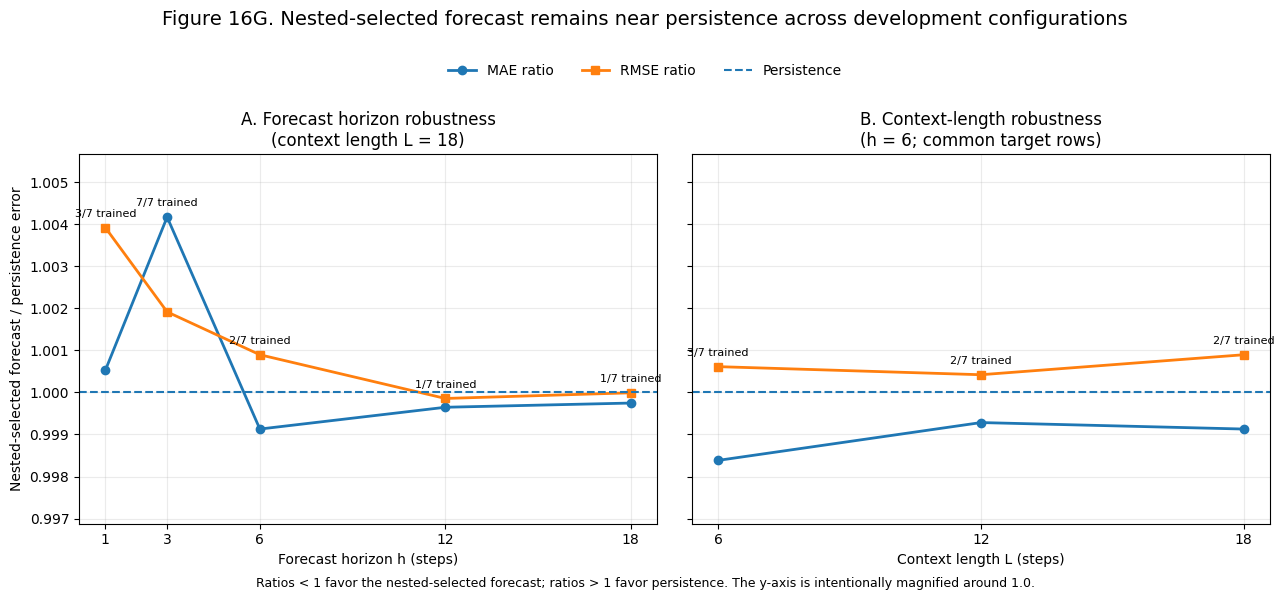


Saved figure: figures/fig16g_robustness_across_configurations.png


In [170]:
benchmark_path = Path("results/part1_benchmark_table.csv")

bench_16g = pd.read_csv(benchmark_path)


required_columns = {
    "benchmark",
    "L",
    "h",
    "windows",
    "MAE_ratio",
    "RMSE_ratio",
    "folds_epoch_gt_0",
}

missing_columns = required_columns.difference(bench_16g.columns)

if missing_columns:
    raise ValueError(
        "Benchmark table is missing required columns: "
        f"{sorted(missing_columns)}"
    )


horizon_16g = (
    bench_16g.loc[bench_16g["benchmark"].eq("horizon")]
    .sort_values("h")
    .reset_index(drop=True)
)

context_16g = (
    bench_16g.loc[bench_16g["benchmark"].eq("context")]
    .sort_values("L")
    .reset_index(drop=True)
)

if len(horizon_16g) != 5:
    raise ValueError(
        f"Expected 5 horizon configurations, found {len(horizon_16g)}."
    )

if len(context_16g) != 3:
    raise ValueError(
        f"Expected 3 context configurations, found {len(context_16g)}."
    )

if context_16g["windows"].nunique() != 1:
    raise ValueError(
        "Context comparison does not use a common number of forecast windows."
    )


print("HORIZON COMPARISON — L = 18")

display(
    horizon_16g[
        [
            "h",
            "windows",
            "MAE_ratio",
            "RMSE_ratio",
            "folds_epoch_gt_0",
        ]
    ].round(4)
)


print("\nCONTEXT COMPARISON — h = 6, common L = 18 target eligibility")

display(
    context_16g[
        [
            "L",
            "windows",
            "MAE_ratio",
            "RMSE_ratio",
            "folds_epoch_gt_0",
        ]
    ].round(4)
)

# Plotting robustness across forecast horizons and context lengths.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.2),
    sharey=True,
)


# Forecast-horizon comparison.
ax = axes[0]

ax.plot(
    horizon_16g["h"],
    horizon_16g["MAE_ratio"],
    marker="o",
    linewidth=2,
    label="MAE ratio",
)

ax.plot(
    horizon_16g["h"],
    horizon_16g["RMSE_ratio"],
    marker="s",
    linewidth=2,
    label="RMSE ratio",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Persistence",
)


# Labeling how many of the seven outer folds retained training
for _, row in horizon_16g.iterrows():
    ax.annotate(
        f"{int(row['folds_epoch_gt_0'])}/7 trained",
        (
            row["h"],
            max(row["MAE_ratio"], row["RMSE_ratio"]),
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )


ax.set_xticks(horizon_16g["h"])

ax.set_xlabel(
    "Forecast horizon h (steps)"
)

ax.set_ylabel(
    "Nested-selected forecast / persistence error"
)

ax.set_title(
    "A. Forecast horizon robustness\n"
    "(context length L = 18)"
)

ax.grid(alpha=0.25)


# Context-length comparison on common target rows.
ax = axes[1]

ax.plot(
    context_16g["L"],
    context_16g["MAE_ratio"],
    marker="o",
    linewidth=2,
    label="MAE ratio",
)

ax.plot(
    context_16g["L"],
    context_16g["RMSE_ratio"],
    marker="s",
    linewidth=2,
    label="RMSE ratio",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Persistence",
)


# Labeling how many of the seven outer folds retained training
for _, row in context_16g.iterrows():
    ax.annotate(
        f"{int(row['folds_epoch_gt_0'])}/7 trained",
        (
            row["L"],
            max(row["MAE_ratio"], row["RMSE_ratio"]),
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )


ax.set_xticks(context_16g["L"])

ax.set_xlabel(
    "Context length L (steps)"
)

ax.set_title(
    "B. Context-length robustness\n"
    "(h = 6; common target rows)"
)

ax.grid(alpha=0.25)


# Magnifying the narrow range around 1.0 so the small differences are visible.
all_ratios = np.concatenate(
    [
        horizon_16g["MAE_ratio"].to_numpy(),
        horizon_16g["RMSE_ratio"].to_numpy(),
        context_16g["MAE_ratio"].to_numpy(),
        context_16g["RMSE_ratio"].to_numpy(),
    ]
)

padding = 0.0015

ymin = min(
    all_ratios.min() - padding,
    0.997,
)

ymax = max(
    all_ratios.max() + padding,
    1.003,
)

axes[0].set_ylim(
    ymin,
    ymax,
)


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
)

fig.suptitle(
    "Figure 16G. Nested-selected forecast remains near persistence "
    "across development configurations",
    y=1.10,
    fontsize=14,
)

fig.text(
    0.5,
    -0.01,
    "Ratios < 1 favor the nested-selected forecast; ratios > 1 favor persistence. "
    "The y-axis is intentionally magnified around 1.0.",
    ha="center",
    fontsize=9,
)

plt.tight_layout()


figure_path = Path("figures/fig16g_robustness_across_configurations.png")

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"\nSaved figure: {figure_path}"
)

#### Interpretation

The near-persistence result is consistent across the development experiments. Across the five forecast horizons, the MAE ratio ranges from 0.9991 to 1.0042 and the RMSE ratio from 0.9999 to 1.0039. None of the horizons produces a meaningful and metric-consistent improvement over persistence.

This result is not explained only by folds reverting to epoch 0. At $h=3$, all seven outer folds retain a trained epoch, yet the nested-selected forecast is still slightly worse than persistence (MAE ratio 1.0042; RMSE ratio 1.0019). At $h=12$ and $h=18$, by contrast, only one of seven folds retains training, so the nested procedure usually prefers the persistence-equivalent solution.

The context-length comparison reaches the same conclusion on a common set of 523 target rows. For $L=6$, $L=12$, and $L=18$, the MAE ratios are 0.9984, 0.9993, and 0.9991, while the corresponding RMSE ratios are 1.0006, 1.0004, and 1.0009. Additional history therefore does not provide a consistent forecasting benefit. I retain $L=6$ as the parsimonious final context rather than because it is statistically superior.

The y-axis is deliberately magnified because all differences are very small. Within the horizons, context lengths, and bounded training variants evaluated here, the development results remain effectively at persistence. This supports the final model-selection result without implying that Transformer models in general cannot improve forecasting for this process.

### What does the trained Transformer change relative to persistence?

Figure 16G evaluates the complete nested-selection procedure, including folds where epoch 0 gives the persistence-equivalent forecast. To examine the learned residual model itself, I isolate the final $(L=6, h=6)$ development folds where nested selection retained a trained epoch.

For these observations, I compare the Transformer forecast directly with persistence and examine the magnitude of the learned residual correction. Only directly measured CO₂ targets are included.

This is a diagnostic subset rather than a new performance benchmark. It contains only the folds where training was retained and is strongly imbalanced across runs, so I use it to understand what the learned model changed rather than to estimate generalization performance.

,value
Persistence MAE,0.388388
Transformer MAE,0.386257
MAE ratio,0.994514
Persistence RMSE,0.749426
Transformer RMSE,0.750657
RMSE ratio,1.001642
Improved observations,58.000000
Worsened observations,48.000000
Unchanged observations,0.000000
Median |correction|,0.008785


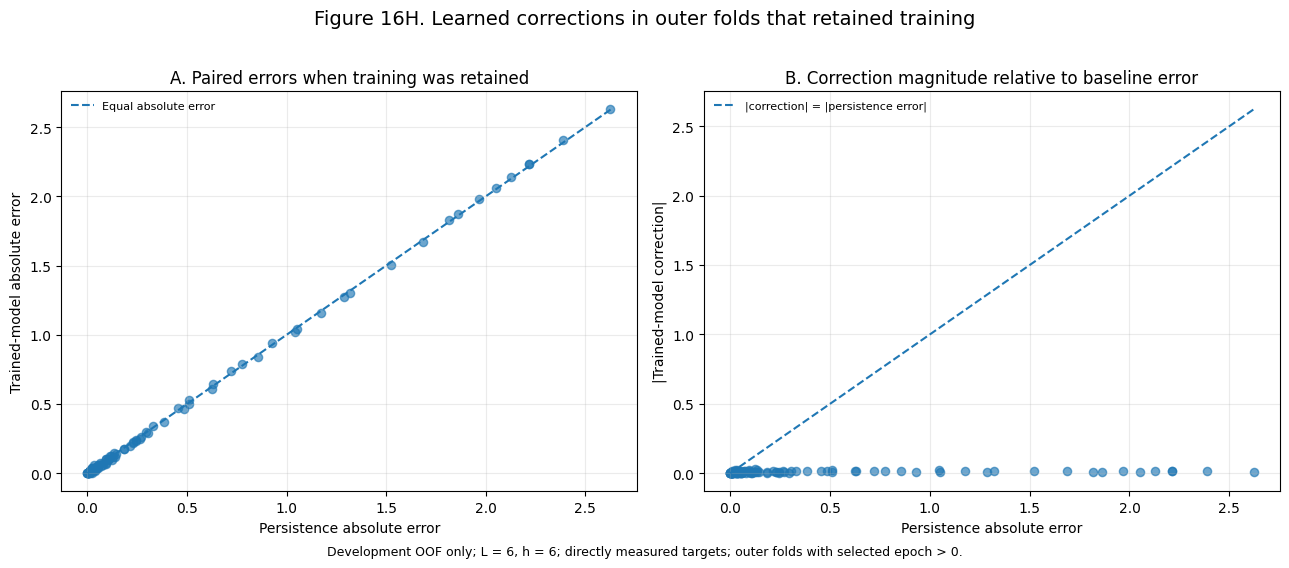

In [172]:
from pathlib import Path
import pickle

from src.data import RAW_DATA_DIR, load_run

part2_oof_path = Path(
    "results/L6_h6_outer_folds.pkl"
)

if not part2_oof_path.exists():
    raise FileNotFoundError(
        f"Could not find saved OOF artifact: {part2_oof_path}"
    )

with open(part2_oof_path, "rb") as f:
    part2_oof_16h = pickle.load(f)


# Identifying folds where nested selection retained training.

trained_runs_16h = [
    run_name
    for run_name, fold in part2_oof_16h.items()
    if int(fold["best_epoch"]) > 0
]


# Loading only the development runs retained by nested selection.

TEST_RUN_16H = "140207_1"

if TEST_RUN_16H in trained_runs_16h:
    raise RuntimeError(
        "Locked test run unexpectedly appeared among development folds."
    )

run_path_map_16h = {
    run_name: Path(RAW_DATA_DIR) / f"{run_name}.xlsx"
    for run_name in trained_runs_16h
}

missing_files_16h = [
    str(path)
    for path in run_path_map_16h.values()
    if not path.exists()
]

if missing_files_16h:
    raise FileNotFoundError(
        "Could not locate required development files:\n"
        + "\n".join(missing_files_16h)
    )

# Retaining the directly measured CO₂ component at each target row.
records_16h = []

for run_name in trained_runs_16h:

    fold = part2_oof_16h[run_name]

    raw_df = load_run(
        run_path_map_16h[run_name]
    )

    y_true = np.asarray(
        fold["y_true"],
        dtype=float,
    )

    persistence = np.asarray(
        fold["persistence"],
        dtype=float,
    )

    forecast = np.asarray(
        fold["forecast"],
        dtype=float,
    )

    target_rows = np.asarray(
        fold["val_target_rows"],
        dtype=int,
    )

    best_epoch = int(
        fold["best_epoch"]
    )


    # Verifying the saved fold arrays before extracting measured targets.
  
    expected_shape = (
        len(target_rows),
        6,
    )

    if y_true.shape != expected_shape:
        raise ValueError(
            f"{run_name}: y_true shape {y_true.shape}; "
            f"expected {expected_shape}."
        )

    if persistence.shape != expected_shape:
        raise ValueError(
            f"{run_name}: persistence shape {persistence.shape}; "
            f"expected {expected_shape}."
        )

    if forecast.shape != expected_shape:
        raise ValueError(
            f"{run_name}: forecast shape {forecast.shape}; "
            f"expected {expected_shape}."
        )


    # Using the analyzer label to identify the directly measured point.
    for i, target_row in enumerate(target_rows):

        sampling_point = int(
            raw_df.iloc[target_row]["label"]
        )

        if sampling_point not in range(1, 7):
            raise ValueError(
                f"{run_name}, row {target_row}: "
                f"unexpected analyzer label {sampling_point}."
            )

        point_index = sampling_point - 1

        observed = float(
            y_true[i, point_index]
        )

        persistence_prediction = float(
            persistence[i, point_index]
        )

        model_prediction = float(
            forecast[i, point_index]
        )

        persistence_error = (
            persistence_prediction - observed
        )

        model_error = (
            model_prediction - observed
        )

        correction = (
            model_prediction
            - persistence_prediction
        )

        absolute_persistence_error = abs(
            persistence_error
        )

        absolute_model_error = abs(
            model_error
        )

        absolute_error_change = (
            absolute_model_error
            - absolute_persistence_error
        )

        records_16h.append(
            {
                "run": run_name,
                "target_row": int(target_row),
                "sampling_point": sampling_point,
                "selected_epoch": best_epoch,
                "observed_co2": observed,
                "persistence_prediction": persistence_prediction,
                "model_prediction": model_prediction,
                "correction": correction,
                "absolute_correction": abs(correction),
                "persistence_error": persistence_error,
                "model_error": model_error,
                "absolute_persistence_error": absolute_persistence_error,
                "absolute_model_error": absolute_model_error,
                "absolute_error_change": absolute_error_change,
            }
        )


trained_cases_16h = pd.DataFrame(
    records_16h
)

# Verifying the reconstructed diagnostic subset.

expected_n_16h = sum(
    len(
        part2_oof_16h[run_name][
            "val_target_rows"
        ]
    )
    for run_name in trained_runs_16h
)

if len(trained_cases_16h) != expected_n_16h:
    raise ValueError(
        "Direct-target reconstruction produced "
        f"{len(trained_cases_16h)} observations; "
        f"expected {expected_n_16h}."
    )
    
expected_run_counts_16h = {
    "140120_1": 80,
    "140207_2": 13,
    "140214_2": 13,
}

actual_run_counts_16h = (
    trained_cases_16h["run"]
    .value_counts()
    .to_dict()
)

if actual_run_counts_16h != expected_run_counts_16h:
    raise ValueError(
        "Unexpected trained-fold composition.\n"
        f"Expected: {expected_run_counts_16h}\n"
        f"Actual:   {actual_run_counts_16h}"
    )

# Computing paired persistence and Transformer performance.

n_16h = len(
    trained_cases_16h
)

persistence_mae_16h = (
    trained_cases_16h[
        "absolute_persistence_error"
    ].mean()
)

model_mae_16h = (
    trained_cases_16h[
        "absolute_model_error"
    ].mean()
)

persistence_rmse_16h = np.sqrt(
    np.mean(
        trained_cases_16h[
            "persistence_error"
        ].to_numpy() ** 2
    )
)

model_rmse_16h = np.sqrt(
    np.mean(
        trained_cases_16h[
            "model_error"
        ].to_numpy() ** 2
    )
)

mae_ratio_16h = (
    model_mae_16h
    / persistence_mae_16h
)

rmse_ratio_16h = (
    model_rmse_16h
    / persistence_rmse_16h
)

# Summarizing observation-level outcomes and correction magnitude.

improved_mask_16h = (
    trained_cases_16h[
        "absolute_error_change"
    ] < 0
)

worsened_mask_16h = (
    trained_cases_16h[
        "absolute_error_change"
    ] > 0
)

unchanged_mask_16h = np.isclose(
    trained_cases_16h[
        "absolute_error_change"
    ].to_numpy(),
    0.0,
)


improved_16h = int(
    improved_mask_16h.sum()
)

worsened_16h = int(
    worsened_mask_16h.sum()
)

unchanged_16h = int(
    unchanged_mask_16h.sum()
)


median_abs_correction_16h = (
    trained_cases_16h[
        "absolute_correction"
    ].median()
)

mean_abs_correction_16h = (
    trained_cases_16h[
        "absolute_correction"
    ].mean()
)

max_abs_correction_16h = (
    trained_cases_16h[
        "absolute_correction"
    ].max()
)

median_persistence_error_16h = (
    trained_cases_16h[
        "absolute_persistence_error"
    ].median()
)

mean_persistence_error_16h = (
    trained_cases_16h[
        "absolute_persistence_error"
    ].mean()
)

summary_16h = pd.Series(
    {
        "Persistence MAE": persistence_mae_16h,
        "Transformer MAE": model_mae_16h,
        "MAE ratio": mae_ratio_16h,
        "Persistence RMSE": persistence_rmse_16h,
        "Transformer RMSE": model_rmse_16h,
        "RMSE ratio": rmse_ratio_16h,
        "Improved observations": improved_16h,
        "Worsened observations": worsened_16h,
        "Unchanged observations": unchanged_16h,
        "Median |correction|": median_abs_correction_16h,
        "Mean |correction|": mean_abs_correction_16h,
        "Maximum |correction|": max_abs_correction_16h,
        "Median persistence |error|": median_persistence_error_16h,
        "Mean persistence |error|": mean_persistence_error_16h,
    },
    name="value",
)

display(
    summary_16h.to_frame().round(6)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.3),
)


# Comparing persistence and Transformer absolute errors.

ax = axes[0]

x_error_16h = (
    trained_cases_16h[
        "absolute_persistence_error"
    ].to_numpy()
)

y_error_16h = (
    trained_cases_16h[
        "absolute_model_error"
    ].to_numpy()
)

ax.scatter(
    x_error_16h,
    y_error_16h,
    alpha=0.65,
    s=35,
)

error_limit_16h = max(
    x_error_16h.max(),
    y_error_16h.max(),
)

ax.plot(
    [0, error_limit_16h],
    [0, error_limit_16h],
    linestyle="--",
    linewidth=1.5,
    label="Equal absolute error",
)

ax.set_xlabel(
    "Persistence absolute error"
)

ax.set_ylabel(
    "Trained-model absolute error"
)

ax.set_title(
    "A. Paired errors when training was retained"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    frameon=False,
    fontsize=8,
)


# Comparing learned correction magnitude with persistence error.

ax = axes[1]

ax.scatter(
    trained_cases_16h[
        "absolute_persistence_error"
    ],
    trained_cases_16h[
        "absolute_correction"
    ],
    alpha=0.65,
    s=35,
)

correction_limit_16h = max(
    trained_cases_16h[
        "absolute_persistence_error"
    ].max(),
    trained_cases_16h[
        "absolute_correction"
    ].max(),
)

ax.plot(
    [0, correction_limit_16h],
    [0, correction_limit_16h],
    linestyle="--",
    linewidth=1.5,
    label="|correction| = |persistence error|",
)

ax.set_xlabel(
    "Persistence absolute error"
)

ax.set_ylabel(
    "|Trained-model correction|"
)

ax.set_title(
    "B. Correction magnitude relative to baseline error"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    frameon=False,
    fontsize=8,
)



fig.suptitle(
    "Figure 16H. Learned corrections in outer folds "
    "that retained training",
    fontsize=14,
    y=1.02,
)

fig.text(
    0.5,
    -0.01,
    "Development OOF only; L = 6, h = 6; directly measured targets; "
    "outer folds with selected epoch > 0.",
    ha="center",
    fontsize=9,
)

plt.tight_layout()


figure_path_16h = Path(
    "figures/fig16h_trained_model_corrections.png"
)

fig.savefig(
    figure_path_16h,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#### Interpretation

The trained-model diagnostic contains 106 directly measured OOF targets from the three outer folds where nested selection retained training. The subset is strongly imbalanced: 80 observations come from `140120_1`, while `140207_2` and `140214_2` contribute 13 each. All three folds selected epoch 1, so this analysis characterizes the early learned correction retained by nested selection rather than the behavior of a more extensively trained model.

Even in these trained folds, performance remains effectively at persistence. MAE decreases from 0.3884 to 0.3863, a ratio of 0.9945, while RMSE increases slightly from 0.7494 to 0.7507, a ratio of 1.0016. The Transformer reduces absolute error for 58 of the 106 observations and increases it for 48.

The main limitation is the size of the learned correction. Its median absolute magnitude is 0.0088, its mean is 0.0092, and its maximum is only 0.0293. Panel A therefore remains close to the equal-error line, while Panel B shows that the corrections are small relative to the larger persistence errors. The trained residual model makes local adjustments, but those adjustments are not large enough to resolve the excursions that dominate squared error.

Together with Figures 16F and 16G, this shows that the near-persistence result is not only caused by some folds selecting epoch 0. Even when training is retained, the learned corrections remain small and provide no metric-consistent improvement over persistence. This conclusion applies to the residual formulation, development runs, and bounded configurations evaluated here; it is not a general claim about Transformer forecasting.

## Root-cause analysis: synthesis and implications

### Main result

Persistence—the last directly measured value available for each sampling point—is a strong baseline for this forecasting problem. Across the development experiments, the nested-selected forecast remains effectively at persistence over the horizons, context lengths, and bounded training variants evaluated. The trained-fold analysis reaches the same conclusion from a different direction: when nested selection retains training, the Transformer learns only small residual corrections and does not consistently reduce the larger errors.

The locked test run was evaluated once after all development decisions were fixed. Because the development-only procedure selected epoch 0 for the final fit, the locked-test forecast is exactly the persistence forecast. The test run was not used for model selection, hyperparameter decisions, or the root-cause analysis below.

### What the development data show about forecast error

The diagnostics identify where the errors occur and rule out several simple explanations. They do not establish a single physical cause.

| Finding | Evidence | Important caveat |
|---|---|---|
| A small fraction of observations dominates squared error. | The largest 5% of directly measured errors account for 69.1% of raw squared error, and only 14 of 523 observations account for half of it (Figure 16F). | Consecutive observations can belong to the same excursion, so these are not necessarily independent failure events. |
| Raw error is largest at sampling points 5 and 6, but scale explains part of the ranking. | Points 5 and 6 have the largest direct-target MAE. After normalization by each point's signal variability, points 2 and 3 also show substantial relative error (Figure 16A). | Raw and scale-normalized errors answer different questions; neither establishes physical predictability. |
| Error structure varies across runs and sampling points. | The run-by-point analysis remains heterogeneous after accounting for within-run signal scale (Figure 16B). | Run identity combines signal-scale differences with potentially different operating conditions, and some run-point cells have limited support. |
| Interpolated targets are easier than directly measured targets. | Approximately 83.3% of the full six-point target profile is interpolated, and persistence error is lower on interpolated than directly measured values (Figure 16D). | This does not establish interpolation as the cause of model failure; it shows that full-profile metrics can make the forecasting problem appear easier than evaluation on real analyzer measurements. |
| Analyzer age does not provide a simple explanation for forecast error. | Point-normalized absolute error shows no clear monotonic relationship with analyzer age over the well-supported range (Figure 16E). | The oldest ages are sparse and confounded with run and analyzer schedule, so an independent staleness effect cannot be ruled out. |
| Large errors occur during relatively uncommon excursions. | The representative failure episode in Figure 16C shows persistence missing both the rise and relaxation of an excursion, while Figure 16F shows that large errors are strongly concentrated. | The example is qualitative and does not identify the physical cause of the excursion. |
| Exploratory process-variable checks do not identify a stable single driver. | Candidate sensor relationships are weak or inconsistent across runs, and broader process-movement diagnostics do not robustly explain the largest errors. | These are exploratory analyses with correlated variables and multiple comparisons; failure to find a stable relationship is not evidence that process conditions are irrelevant. |

### What the Transformer adds

The development results point to two reasons why the final forecasting procedure remains close to persistence.

First, nested selection often prefers the persistence-equivalent epoch 0 solution. For the final \(L=6,\ h=6\) configuration, only three of seven outer folds retain training. This alone does not explain the result, however: at \(h=3\), all seven folds retain a trained epoch and the pooled forecast is still slightly worse than persistence.

Second, the folds that do retain training show that the learned residual correction is small. In the final configuration, all three trained folds select epoch 1. Across their 106 directly measured targets, the median absolute correction is 0.0088 and the maximum is only 0.0293. MAE improves slightly, while RMSE becomes slightly worse (Figure 16H).

The evidence therefore supports a limited conclusion: within the residual formulation and development configurations evaluated here, the Transformer does not provide a consistent improvement over persistence. This does not imply that Transformer architectures in general cannot improve forecasting for this process.

### Working hypotheses

The diagnostics suggest several explanations for the near-persistence result, but the available experiments do not establish any of them as causal.

**Limited information between analyzer visits.** Each sampling point is observed intermittently by the rotating analyzer. The previous directly measured value may already capture much of the short-term information available for that point, while changes before the next measurement may be difficult to infer reliably from the available process history.

**Sparse supervision on real CO₂ measurements.** At each row, approximately one sixth of the six-point CO₂ profile is directly measured and the remaining values are interpolated. Training on the complete profile may therefore emphasize smooth reconstructed trajectories more strongly than the sparse real measurements. The measured-only evaluation is unaffected by interpolation, so this is specifically a hypothesis about the training signal.

**Rare excursions dominate the difficult cases.** A small fraction of directly measured observations accounts for most of the squared error (Figure 16F), while the trained residual corrections remain small (Figure 16H). The model therefore does little to reduce the errors that matter most for RMSE.

**Run and operating-condition heterogeneity may limit transfer.** Error patterns vary across run-point combinations even after accounting for signal scale (Figure 16B). With only seven development runs, leave-one-run-out validation is a demanding but data-limited test of transfer to unseen runs.

### What these data cannot separate

Several potentially important effects remain confounded. Analyzer age is linked to the rotating measurement schedule and, at the oldest observed ages, to particular runs. Run identity combines changes in signal scale with potentially different operating conditions. Observation-level errors are temporally correlated, so several large errors can represent one underlying excursion rather than independent failures.

The exploratory process-variable analysis also cannot distinguish between two possibilities: the excursions may be difficult to predict from the available sensors, or useful predictive information may exist but require a different representation, objective, or model. The current experiments do not resolve that distinction.predictive information.

### Limitations

The analysis contains seven development runs and uses leave-one-run-out validation to reduce leakage across temporally related observations. Rows within each held-out run remain correlated, so the number of forecast observations should not be interpreted as the number of independent experimental units.

The horizon and context experiments vary one factor at a time rather than evaluating a complete grid, and model size and optimization settings were explored over a bounded set of alternatives. In addition, most values in the full six-point target profile are interpolated. For these reasons, the analysis emphasizes effect magnitude, consistency across runs, paired comparison with persistence, and directly measured targets rather than observation-level significance tests or exhaustive hyperparameter claims.

### Recommended next experiments

1. **Use measurement-aware training.** Compare the current full-profile objective with a loss that upweights or exclusively optimizes directly measured CO₂ targets. This directly tests whether interpolated supervision is suppressing learning on real measurements.

2. **Increase independent run coverage.** Additional experimental runs would provide more examples of rare excursions and support run-level or blocked uncertainty estimates without treating individual rows as independent.

3. **Represent the analyzer schedule explicitly.** The current features include analyzer memory, age, seen indicators, and label information, but a formulation organized around the next measurement of each sampling point could align training more directly with the measured-target objective.

4. **Test point-specific prediction structure.** Separate output heads, point-specific residual scaling, or related multi-task formulations could test whether the shared prediction head limits adaptation to differences among sampling points.

5. **Model predictive uncertainty.** Quantile or probabilistic forecasts could test whether the model identifies periods of elevated uncertainty even when the point forecast remains close to persistence.

6. **Test additional causal baselines before increasing model complexity.** Compare persistence with simple development-only alternatives based on the last \(k\) directly measured values, such as a local mean or trend. This would test whether slightly richer low-complexity temporal structure provides useful information beyond the most recent measurement.

### Overall conclusion

The root-cause analysis does not identify a single physical cause of the forecasting errors. Instead, the development evidence points to a combination of factors: sparse rotating CO₂ measurements, heavy use of interpolation in the full target profile, strong short-horizon persistence, heterogeneous behavior across runs and sampling points, and relatively uncommon excursions that dominate squared error.

Under the residual formulation and training procedure evaluated here, the Transformer learns only small corrections to persistence. Those corrections do not consistently improve out-of-run performance and are too small to resolve the largest persistence failures.

The main result is therefore not simply that one model failed to beat another. The analysis identifies where the baseline succeeds, where it breaks down, which simple explanations are not supported by the development data, and which experiments would most directly test the remaining hypotheses.